# **Experiment 1: Clean Baseline**

### Setup

NumPy is used for numerical computation and the from-scratch model implementation; Matplotlib is used for loss curves and regression plots.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("NumPy version:", np.__version__)
print("Random seed:", SEED)

NumPy version: 2.1.3
Random seed: 42


## **Part 1:  Synthetic data generation**

The clean baseline uses the fixed relationship \(y=3x+2+\epsilon\), where \(\epsilon\sim N(0,\sigma^2)\), \(w_{true}=3\), and \(b_{true}=2\). The noise standard deviation is fixed at 1 because later experiments change only the contamination conditions.


In [2]:
# Ground-truth linear relationship
W_TRUE = 3.0
B_TRUE = 2.0

# Dataset settings
N_TRAIN = 100
N_TEST = 100
NOISE_STD = 1.0

# Training inputs
x_train = np.random.uniform(-5, 5, size=N_TRAIN)

# Training targets: y = 3x + 2 + noise
train_noise = np.random.normal(
    loc=0.0,
    scale=NOISE_STD,
    size=N_TRAIN
)

y_train = W_TRUE * x_train + B_TRUE + train_noise

# Clean test set generated independently
x_test = np.random.uniform(-5, 5, size=N_TEST)

test_noise = np.random.normal(
    loc=0.0,
    scale=NOISE_STD,
    size=N_TEST
)

y_test = W_TRUE * x_test + B_TRUE + test_noise

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))
print("True parameters:")
print("w_true =", W_TRUE)
print("b_true =", B_TRUE)

Training samples: 100
Test samples: 100
True parameters:
w_true = 3.0
b_true = 2.0


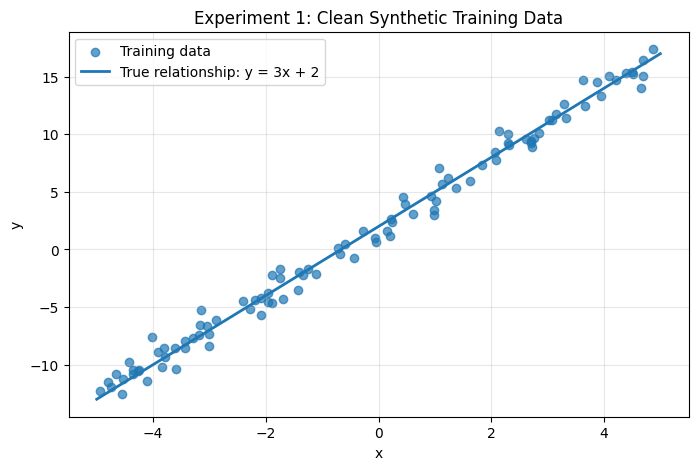

In [3]:
# Figure of Synthetic data

plt.figure(figsize=(8, 5))

plt.scatter(
    x_train,
    y_train,
    alpha=0.7,
    label="Training data"
)

x_line = np.linspace(-5, 5, 200)
y_true_line = W_TRUE * x_line + B_TRUE

plt.plot(
    x_line,
    y_true_line,
    linewidth=2,
    label="True relationship: y = 3x + 2"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Experiment 1: Clean Synthetic Training Data")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **Part 2:  Hypothesis and Loss Functions**

The model is one-dimensional linear regression. Varying the slope and intercept defines the hypothesis space.

$$ \hat y = wx+b $$


### Linear Regression hypothesis / prediction function

The prediction function implements the mathematical model directly.


In [4]:
def predict(x, w, b):
    """
    Compute predictions for a one-dimensional linear regression model.

    Parameters
    ----------
    x : np.ndarray
        Input feature values.
    w : float
        Slope parameter.
    b : float
        Intercept parameter.

    Returns
    -------
    np.ndarray
        Predicted target values.
    """

    y_hat = w * x + b
    return y_hat

### Sanity check for the prediction function

A simple identity-line example checks that the prediction function returns the expected values.

$$ w=1,\quad b=0 $$

$$ \hat y = 1x+0=x $$

$$ x=-2 \Rightarrow \hat y=-2 $$

$$ x=0 \Rightarrow \hat y=0 $$

$$ x=2⇒y^​=2 $$


In [5]:
x_demo = np.array([-2.0, 0.0, 2.0])

w_demo = 1.0
b_demo = 0.0

y_demo_pred = predict(x_demo, w_demo, b_demo)

print("Input x:", x_demo)
print("w =", w_demo)
print("b =", b_demo)
print("Predictions:", y_demo_pred)

Input x: [-2.  0.  2.]
w = 1.0
b = 0.0
Predictions: [-2.  0.  2.]


### Visualise several hypotheses from the same model family

Different slope and intercept values produce different members of the same linear hypothesis space. Training searches this space for suitable parameters.

$$ f_{w,b}(x)=wx+b $$

$$ f_{1,0}(x)=x $$

$$ f_{3,2}(x)=3x+2 $$

$$ f_{-2,5}(x)=-2x+5 $$


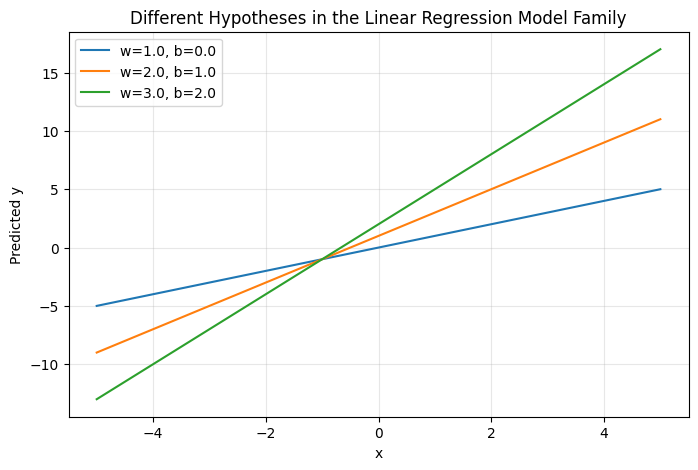

In [6]:
x_plot = np.linspace(-5, 5, 200)

hypotheses = [
    (1.0, 0.0),
    (2.0, 1.0),
    (3.0, 2.0)
]

plt.figure(figsize=(8, 5))

for w, b in hypotheses:
    y_plot = predict(x_plot, w, b)
    plt.plot(
        x_plot,
        y_plot,
        label=f"w={w}, b={b}"
    )

plt.xlabel("x")
plt.ylabel("Predicted y")
plt.title("Different Hypotheses in the Linear Regression Model Family")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **Part 3:  Residual and MSE Loss**

Residuals begin the analysis chain from an outlier to the learned model. They are defined as prediction minus target, so a positive residual means overprediction and a negative residual means underprediction.

$$ Outlier→Residual→Loss→Gradient→Parameter Update→Learned Model $$

$$ \hat y_i = wx_i+b $$

$$ y_i $$

$$ r_i​=\hat y_i​−y_i​ $$

$$ y=5,\quad \hat y=7 $$

$$ r=7-5=2 $$

$$ y=5,\quad \hat y=3 $$

$$ r=3-5=-2 $$


### Residual function

The residual function implements the stated sign convention.

$$ r_i​=\hat y_i​−y_i​ $$


In [7]:
# Residual = prediction - true target

def residuals(y_true, y_pred):
    """
    Compute residuals between predictions and true targets.

    Parameters
    ----------
    y_true : np.ndarray
        True target values.
    y_pred : np.ndarray
        Predicted target values.

    Returns
    -------
    np.ndarray
        Residuals defined as y_pred - y_true.
    """

    r = y_pred - y_true
    return r

### Sanity check for residual computation

$$ 2−3=−1 $$
$$ 5-5=0 $$
$$ 10-7=3 $$

In [8]:
y_true_demo = np.array([3.0, 5.0, 7.0])
y_pred_demo = np.array([2.0, 5.0, 10.0])

r_demo = residuals(y_true_demo, y_pred_demo)

print("True targets: ", y_true_demo)
print("Predictions:  ", y_pred_demo)
print("Residuals:    ", r_demo)

True targets:  [3. 5. 7.]
Predictions:   [ 2.  5. 10.]
Residuals:     [-1.  0.  3.]


### Mean Squared Error (MSE) loss

Mean Squared Error averages the squared residuals.

$$ \boxed{ L_{\text{MSE}} = \frac{1}{n} \sum_{i=1}^{n} (\hat y_i-y_i)^2 } $$

$$ r_i=\hat y_i-y_i $$

$$ \boxed{ L_{\text{MSE}} = \frac{1}{n} \sum_{i=1}^{n} r_i^2 } $$


In [9]:
def mse_loss(y_true, y_pred):
    """
    Compute Mean Squared Error loss.

    MSE = mean((y_pred - y_true)^2)

    Parameters
    ----------
    y_true : np.ndarray
        True target values.
    y_pred : np.ndarray
        Predicted target values.

    Returns
    -------
    float
        Mean squared error over all samples.
    """

    r = residuals(y_true, y_pred)
    loss = np.mean(r ** 2)

    # y^ ​→ r → L​

    return loss

### Sanity check for MSE loss

For the demonstration residuals, squaring and averaging gives the expected MSE.

$$ [-1,0,3] $$

$$ [1,0,9] $$

$$ \frac{1+0+9}{3} = \frac{10}{3} \approx3.3333 $$


In [10]:
mse_demo = mse_loss(y_true_demo, y_pred_demo)

print("Residuals:", r_demo)
print("Squared residuals:", r_demo ** 2)
print("MSE:", mse_demo)

Residuals: [-1.  0.  3.]
Squared residuals: [1. 0. 9.]
MSE: 3.3333333333333335


### Small MSE Sensitivity Demonstration

MSE applies a quadratic penalty: increasing a residual from 1 to 10 increases its squared error from 1 to 100. Large vertical outliers can therefore dominate both the loss and its gradient.

$$ r_1=1 $$

$$ r_2=10 $$

$$ 1^2=1 $$

$$ 10^2=100 $$

$$ 10\times $$

$$ 100\times $$

$$ |r|\uparrow $$

$$ r^2 \uparrow\uparrow $$


In [11]:
# Demonstrate the quadratic penalty of MSE

example_residuals = np.array([1.0, 2.0, 5.0, 10.0])
squared_errors = example_residuals ** 2

print("Residuals:      ", example_residuals)
print("Squared errors: ", squared_errors)

Residuals:       [ 1.  2.  5. 10.]
Squared errors:  [  1.   4.  25. 100.]


$$ x→$$
$$y^​=wx+b→$$
$$r=̂y​−y→$$
$$LMSE​ $$

y_pred = predict(x, w, b)

r = residuals(y_true, y_pred)

loss = np.mean(r ** 2)

## **Part 4: MAE Loss**

MAE averages absolute residuals and therefore grows linearly rather than quadratically. It is less sensitive to large residuals, although it is not differentiable at zero.

$$ r_i = \hat y_i-y_i $$

$$ \boxed{ L_{\text{MAE}} = \frac{1}{n} \sum_{i=1}^{n} |\hat y_i-y_i| } $$

$$ \boxed{ L_{\text{MAE}} = \frac{1}{n} \sum_{i=1}^{n}|r_i| } $$

$$ \text{MSE}: r^2 $$

$$ \text{MAE}: |r| $$

$$ \text{MSE}: 1\rightarrow100 $$

$$ \text{MAE}: 1\rightarrow10 $$

$$ \ell_{\text{MSE}}(r)=r^2 $$

$$ \ell_{\text{MAE}}(r)=|r| $$


### Mean Absolute Error (MAE) loss

The implementation first computes residuals and then averages their absolute values.

$$ r=\hat y−y $$

$$ \frac{1}{n}\sum |r_i| $$


In [12]:
def mae_loss(y_true, y_pred):
    """
    Compute Mean Absolute Error loss.

    MAE = mean(abs(y_pred - y_true))

    Parameters
    ----------
    y_true : np.ndarray
        True target values.
    y_pred : np.ndarray
        Predicted target values.

    Returns
    -------
    float
        Mean absolute error over all samples.
    """

    r = residuals(y_true, y_pred)
    loss = np.mean(np.abs(r))

    return loss

### Sanity check for MAE loss

Taking the absolute values of the demonstration residuals gives the expected MAE.

$$ r=[-1,0,3] $$

$$ |r|=[1,0,3] $$

$$ \text{MAE} = \frac{1+0+3}{3} = \frac43 \approx1.3333 $$


In [13]:
mae_demo = mae_loss(y_true_demo, y_pred_demo)

print("Residuals:", r_demo)
print("Absolute residuals:", np.abs(r_demo))
print("MAE:", mae_demo)

Residuals: [-1.  0.  3.]
Absolute residuals: [1. 0. 3.]
MAE: 1.3333333333333333


### Compare MSE and MAE penalties for different residual sizes

MSE has a parabolic penalty, whereas MAE has a V-shaped linear penalty. This difference motivates the later outlier-magnitude experiment.

$$ |r| $$

$$ Outlier→Residual→Loss $$


In [14]:
comparison_residuals = np.array([0.0, 1.0, 2.0, 5.0, 10.0])

mse_penalties = comparison_residuals ** 2
mae_penalties = np.abs(comparison_residuals)

print("Residuals:     ", comparison_residuals)
print("MSE penalties: ", mse_penalties)
print("MAE penalties: ", mae_penalties)

Residuals:      [ 0.  1.  2.  5. 10.]
MSE penalties:  [  0.   1.   4.  25. 100.]
MAE penalties:  [ 0.  1.  2.  5. 10.]


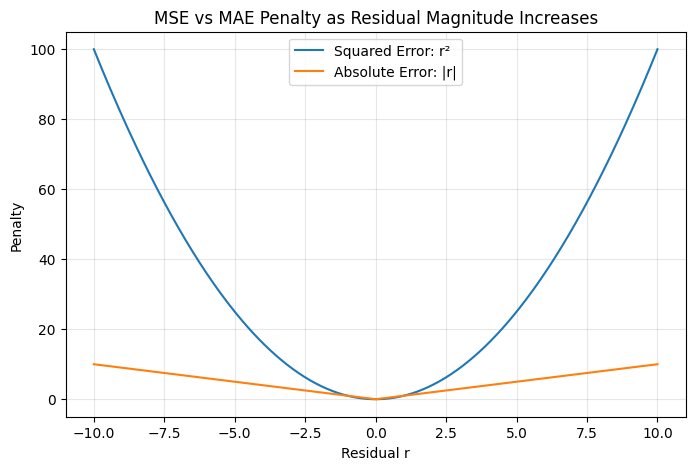

In [15]:
# Visualise the penalty shape of MSE and MAE

r_values = np.linspace(-10, 10, 400)

mse_values = r_values ** 2
mae_values = np.abs(r_values)

plt.figure(figsize=(8, 5))

plt.plot(
    r_values,
    mse_values,
    label="Squared Error: r²"
)

plt.plot(
    r_values,
    mae_values,
    label="Absolute Error: |r|"
)

plt.xlabel("Residual r")
plt.ylabel("Penalty")
plt.title("MSE vs MAE Penalty as Residual Magnitude Increases")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **Part 5: Huber Loss**

Huber loss is quadratic for small residuals and linear for large residuals. The threshold controls the transition, and the factor one-half makes the derivative in the quadratic region equal to the residual.

$$ \boxed{ \text{small residual} \Rightarrow \text{quadratic} } $$

$$ \boxed{ \text{large residual} \Rightarrow \text{linear} } $$

$$ \boxed{\delta} $$

$$ r=\hat y-y $$

$$ \boxed{ \ell_\delta(r) = \begin{cases} \frac{1}{2}r^2, & |r|\leq\delta \\[6pt] \delta \left( |r|-\frac{1}{2}\delta \right), & |r|>\delta \end{cases} } $$

$$ \boxed{ L_{\text{Huber}} = \frac{1}{n} \sum_{i=1}^{n} \ell_\delta(r_i) } $$

$$ \frac12r^2 $$

$$ r^2 $$

$$ \frac{d}{dr} \left( \frac12r^2 \right) =r $$

$$ \delta=1 $$

$$ |r|\leq1 $$

$$ \frac12r^2 $$

$$ |r|>1 $$

$$ |r|-\frac12 $$

$$ \boxed{\delta=\text{transition threshold}} $$


### Huber loss

if |r| <= delta: use quadratic loss

else: use linear loss

In [16]:
# Quadratic for small residuals and linear for large ones

def huber_loss(y_true, y_pred, delta=1.0):
    """
    Compute Huber loss.

    For each residual r:
        0.5 * r^2                         if |r| <= delta
        delta * (|r| - 0.5 * delta)      if |r| > delta

    Parameters
    ----------
    y_true : np.ndarray
        True target values.
    y_pred : np.ndarray
        Predicted target values.
    delta : float
        Threshold between quadratic and linear regions.

    Returns
    -------
    float
        Mean Huber loss over all samples.
    """

    r = residuals(y_true, y_pred)
    abs_r = np.abs(r)

    sample_losses = np.where(
        abs_r <= delta,
        0.5 * r ** 2,
        delta * (abs_r - 0.5 * delta)
    )

    loss = np.mean(sample_losses)

    return loss

### Sanity check for Huber loss

With the stated threshold, the first two demonstration residuals are in the quadratic region and the third is in the linear region, giving the expected mean loss.

$$ |-1|=1\leq\delta $$

$$ \frac12(-1)^2 = 0.5 $$

$$ |0|\leq1 $$

$$ \frac12(0)^2=0 $$

$$ |3|>1 $$

$$ 1 \left( 3-\frac12(1) \right) $$

$$ =2.5 $$

$$ [0.5,0,2.5] $$

$$ L_{\text{Huber}} = \frac{0.5+0+2.5}{3} =1 $$


In [17]:
delta_demo = 1.0

huber_demo = huber_loss(
    y_true_demo,
    y_pred_demo,
    delta=delta_demo
)

print("Residuals:", r_demo)
print("Delta:", delta_demo)
print("Huber loss:", huber_demo)

Residuals: [-1.  0.  3.]
Delta: 1.0
Huber loss: 1.0


### Direct Comparison of Three Loss Penalties

For a residual of 10, the three penalties differ substantially.

$$ r=10 $$

$$ \text{MSE}=100 $$

$$ \text{MAE}=10 $$

$$ \text{Huber}_{\delta=1}=9.5 $$


In [18]:
# Compare MSE, MAE, and Huber penalties

comparison_residuals = np.array(
    [0.0, 0.5, 1.0, 2.0, 5.0, 10.0]
)

delta = 1.0

mse_penalties = comparison_residuals ** 2
mae_penalties = np.abs(comparison_residuals)

huber_penalties = np.where(
    np.abs(comparison_residuals) <= delta,
    0.5 * comparison_residuals ** 2,
    delta * (
        np.abs(comparison_residuals)
        - 0.5 * delta
    )
)

print("Residuals:      ", comparison_residuals)
print("MSE penalties:  ", mse_penalties)
print("MAE penalties:  ", mae_penalties)
print("Huber penalties:", huber_penalties)

Residuals:       [ 0.   0.5  1.   2.   5.  10. ]
MSE penalties:   [  0.     0.25   1.     4.    25.   100.  ]
MAE penalties:   [ 0.   0.5  1.   2.   5.  10. ]
Huber penalties: [0.    0.125 0.5   1.5   4.5   9.5  ]


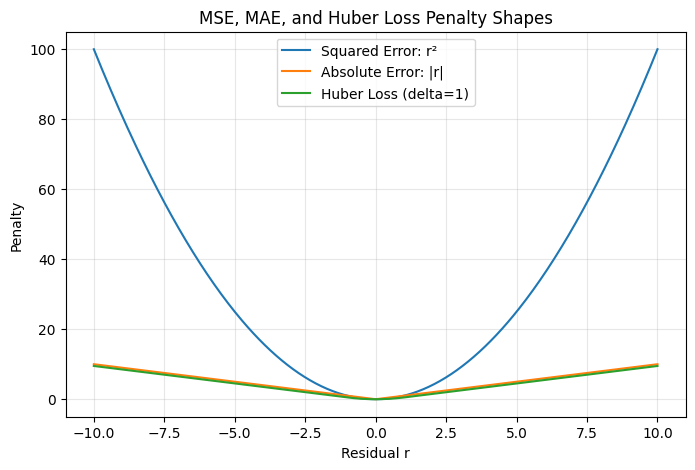

In [19]:
# Visualise MSE, MAE, and Huber penalty shapes

r_values = np.linspace(-10, 10, 400)
delta = 1.0

mse_values = r_values ** 2
mae_values = np.abs(r_values)

huber_values = np.where(
    np.abs(r_values) <= delta,
    0.5 * r_values ** 2,
    delta * (
        np.abs(r_values)
        - 0.5 * delta
    )
)

plt.figure(figsize=(8, 5))

plt.plot(
    r_values,
    mse_values,
    label="Squared Error: r²"
)

plt.plot(
    r_values,
    mae_values,
    label="Absolute Error: |r|"
)

plt.plot(
    r_values,
    huber_values,
    label="Huber Loss (delta=1)"
)

plt.xlabel("Residual r")
plt.ylabel("Penalty")
plt.title("MSE, MAE, and Huber Loss Penalty Shapes")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

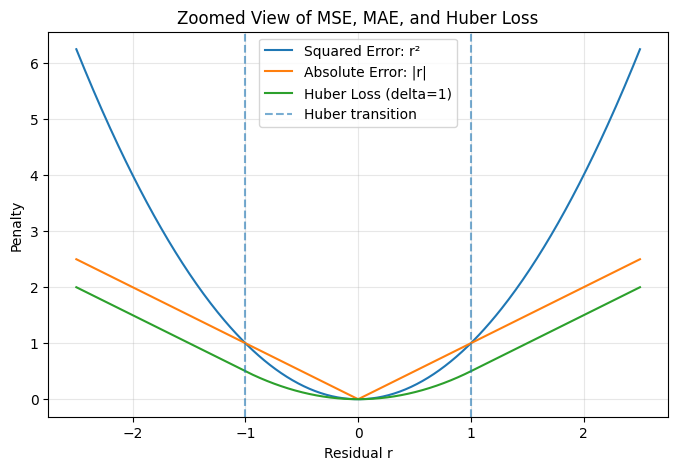

In [20]:
# ---------------------------------------------------------
# Zoom in around the Huber transition region
# This highlights its quadratic behaviour near zero
# ---------------------------------------------------------

r_zoom = np.linspace(-2.5, 2.5, 400)
delta = 1.0

mse_zoom = r_zoom ** 2
mae_zoom = np.abs(r_zoom)

huber_zoom = np.where(
    np.abs(r_zoom) <= delta,
    0.5 * r_zoom ** 2,
    delta * (
        np.abs(r_zoom)
        - 0.5 * delta
    )
)

plt.figure(figsize=(8, 5))

plt.plot(
    r_zoom,
    mse_zoom,
    label="Squared Error: r²"
)

plt.plot(
    r_zoom,
    mae_zoom,
    label="Absolute Error: |r|"
)

plt.plot(
    r_zoom,
    huber_zoom,
    label="Huber Loss (delta=1)"
)

# Mark the transition points of Huber loss
plt.axvline(
    x=-delta,
    linestyle="--",
    alpha=0.6,
    label="Huber transition"
)

plt.axvline(
    x=delta,
    linestyle="--",
    alpha=0.6
)

plt.xlabel("Residual r")
plt.ylabel("Penalty")
plt.title("Zoomed View of MSE, MAE, and Huber Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The global plot shows the unbounded quadratic growth of MSE and the linear growth of MAE and Huber for large residuals. The zoomed plot shows Huber's smooth quadratic centre and linear tails. Together they complete the forward loss pipeline.

$$ r^2 $$

$$ |r| $$

$$ \frac12r^2 $$

$$ x $$

$$ \boxed{ \hat y=wx+b } $$

$$ \boxed{ r=\hat y-y } $$

$$ \begin{cases} \displaystyle L_{\text{MSE}} = \frac1n\sum r_i^2 \\[10pt] \displaystyle L_{\text{MAE}} = \frac1n\sum |r_i| \\[10pt] \displaystyle L_{\text{Huber}} = \frac1n\sum\ell_\delta(r_i) \end{cases} $$


## **Part 6:  MSE Analytical Gradient**

This section extends the forward pipeline by deriving how the loss changes with the model parameters.

$$ x \rightarrow \hat y \rightarrow r \rightarrow L $$


Applying the chain rule to the prediction and residual gives the analytical MSE gradients.

$$ L \rightarrow \frac{\partial L}{\partial\hat y} \rightarrow \frac{\partial\hat y}{\partial(w,b)} \rightarrow \frac{\partial L}{\partial(w,b)} $$

$$ \hat y_i=wx_i+b,\qquad r_i=\hat y_i-y_i $$

$$ \frac{\partial L}{\partial\hat y_i} = \frac{2}{n}r_i $$

$$ \frac{\partial\hat y_i}{\partial w}=x_i, \qquad \frac{\partial\hat y_i}{\partial b}=1 $$

$$ \frac{\partial L}{\partial w} = \frac2n\sum r_ix_i $$

$$ \frac{\partial L}{\partial b} = \frac2n\sum r_i $$


### Analytical gradients for MSE loss

The implementation maps the residual formula directly to the slope and intercept gradients.

$$ r_i=\hat y_i-y_i $$

$$ \frac{\partial L}{\partial w} = \frac{2}{n}\sum r_ix_i $$

$$ \frac{\partial L}{\partial b} = \frac{2}{n}\sum r_i $$


In [21]:
def mse_gradients(x, y_true, y_pred):
    """
    Compute analytical gradients of MSE loss
    with respect to w and b.

    dL/dw = (2/n) * sum((y_pred - y_true) * x)
    dL/db = (2/n) * sum(y_pred - y_true)

    Parameters
    ----------
    x : np.ndarray
        Input feature values.
    y_true : np.ndarray
        True target values.
    y_pred : np.ndarray
        Predicted target values.

    Returns
    -------
    dw : float
        Gradient of MSE with respect to w.
    db : float
        Gradient of MSE with respect to b.
    """

    r = residuals(y_true, y_pred)
    n = len(x)

    dw = (2.0 / n) * np.sum(r * x)
    db = (2.0 / n) * np.sum(r)

    return dw, db

### Sanity check for MSE analytical gradients

A two-sample calculation checks the analytical MSE gradients by hand.

$$ \frac{\partial L}{\partial w} = \frac{2}{2} \left[ (-2)(1)+(-3)(2) \right] $$

$$ =1(-2-6) $$

$$ \boxed{ \frac{\partial L}{\partial w} =-8 } $$

$$ \frac{\partial L}{\partial b} = \frac{2}{2} (-2-3) $$

$$ \boxed{ \frac{\partial L}{\partial b} =-5 } $$


In [22]:
# Sanity check for MSE analytical gradients

x_grad_demo = np.array([1.0, 2.0])
y_true_grad_demo = np.array([3.0, 5.0])

w_grad_demo = 1.0
b_grad_demo = 0.0

y_pred_grad_demo = predict(
    x_grad_demo,
    w_grad_demo,
    b_grad_demo
)

dw_demo, db_demo = mse_gradients(
    x_grad_demo,
    y_true_grad_demo,
    y_pred_grad_demo
)

print("x:", x_grad_demo)
print("True targets:", y_true_grad_demo)
print("Predictions:", y_pred_grad_demo)
print("Residuals:", residuals(
    y_true_grad_demo,
    y_pred_grad_demo
))
print("dL/dw:", dw_demo)
print("dL/db:", db_demo)

x: [1. 2.]
True targets: [3. 5.]
Predictions: [1. 2.]
Residuals: [-2. -3.]
dL/dw: -8.0
dL/db: -5.0


Gradient descent moves opposite the gradient. A negative slope gradient therefore increases the slope under the stated update rule.

$$ w_{\text{new}} = w-\eta\frac{\partial L}{\partial w} $$

$$ \frac{\partial L}{\partial w}=-8 $$

$$ w_{\text{new}} = w-\eta(-8) $$

$$ w_{\text{new}} = w+8\eta $$

$$ \boxed{w\text{ increases}} $$

$$ \nabla L $$

$$ \boxed{\text{loss increases fastest}} $$

$$ \boxed{-\nabla L} $$

$$ \theta_{t+1} = \theta_t - \eta\nabla L $$

$$ w^{(t+1)} = w^{(t)} -\eta\frac{\partial L}{\partial w} $$

$$ b^{(t+1)} = b^{(t)} -\eta\frac{\partial L}{\partial b} $$


The pipeline now includes prediction, loss, and the parameter gradients.

$$ x \rightarrow \hat y \rightarrow r \rightarrow L_{\text{MSE}} \rightarrow \left( \frac{\partial L}{\partial w}, \frac{\partial L}{\partial b} \right) $$

$$ \boxed{ \text{Prediction} \rightarrow \text{Loss} \rightarrow \text{Gradient} } $$


## **Part 7: MAE Analytical Gradient**

For non-zero residuals, the derivative of absolute value is the residual sign. Combining this with the linear model gives the MAE parameter gradients.

$$ r_i=\hat y_i-y_i $$

$$ L_{\text{MAE}} = \frac1n\sum_{i=1}^{n}|r_i| $$

$$ r_i\neq0 $$

$$ \frac{d|r_i|}{dr_i} = \operatorname{sign}(r_i) $$

$$ \operatorname{sign}(r)= \begin{cases} -1,&r<0\\ +1,&r>0 \end{cases} $$

$$ \boxed{ \frac{\partial L}{\partial\hat y_i} = \frac1n\operatorname{sign}(r_i) } $$

$$ \hat y_i=wx_i+b $$

$$ \frac{\partial\hat y_i}{\partial w}=x_i $$

$$ \frac{\partial\hat y_i}{\partial b}=1 $$

$$ \frac{\partial L}{\partial w} = \sum_i \frac{\partial L}{\partial\hat y_i} \frac{\partial\hat y_i}{\partial w} $$

$$ \boxed{ \frac{\partial L_{\text{MAE}}}{\partial w} = \frac1n \sum_{i=1}^{n} \operatorname{sign}(r_i)x_i } $$

$$ \boxed{ \frac{\partial L_{\text{MAE}}}{\partial b} = \frac1n \sum_{i=1}^{n} \operatorname{sign}(r_i) } $$


At zero, absolute value has a set-valued subgradient. This implementation selects zero, matching `np.sign(0.0)`.

$$ \partial |r|_{r=0}=[-1,1] $$


### Analytical gradients for MAE loss

The code computes residual signs and averages their contributions to the slope and intercept gradients.

$$ \operatorname{sign}(r_i) $$

$$ \frac{\partial L}{\partial w} = \frac1n\sum\operatorname{sign}(r_i)x_i $$

$$ \frac{\partial L}{\partial b} = \frac1n\sum\operatorname{sign}(r_i) $$


In [23]:
# dL/dw = (1/n) * sum(sign(r_i) * x_i)
# dL/db = (1/n) * sum(sign(r_i))
# We use sign(0) = 0 at the non-differentiable point

def mae_gradients(x, y_true, y_pred):
    """
    Compute analytical gradients of MAE loss
    with respect to w and b.
    """

    r = residuals(y_true, y_pred)
    n = len(x)

    signs = np.sign(r)

    dw = (1.0 / n) * np.sum(signs * x)
    db = (1.0 / n) * np.sum(signs)

    return dw, db

### Sanity check for MAE analytical gradients

Using the same two-sample example as MSE gives the expected MAE gradients.

$$ \operatorname{sign}(r) = [-1,-1] $$

$$ n=2 $$

$$ \frac{\partial L}{\partial w} = \frac12 [ (-1)(1)+(-1)(2) ] $$

$$ \boxed{ \frac{\partial L}{\partial w} =-1.5 } $$

$$ \frac{\partial L}{\partial b} = \frac12[-1-1] $$

$$ \boxed{ \frac{\partial L}{\partial b} =-1 } $$


In [24]:
dw_mae_demo, db_mae_demo = mae_gradients(
    x_grad_demo,
    y_true_grad_demo,
    y_pred_grad_demo
)

print("x:", x_grad_demo)
print("True targets:", y_true_grad_demo)
print("Predictions:", y_pred_grad_demo)
print("Residuals:", residuals(
    y_true_grad_demo,
    y_pred_grad_demo
))
print("Residual signs:", np.sign(
    residuals(y_true_grad_demo, y_pred_grad_demo)
))
print("dL/dw:", dw_mae_demo)
print("dL/db:", db_mae_demo)

x: [1. 2.]
True targets: [3. 5.]
Predictions: [1. 2.]
Residuals: [-2. -3.]
Residual signs: [-1. -1.]
dL/dw: -1.5
dL/db: -1.0


The numerical sizes of MSE and MAE gradients should not be ranked directly because the losses use different scales. The important comparison is how gradient magnitude changes with residual magnitude.

$$ \frac{\partial L}{\partial w}=-8 $$

$$ \frac{\partial L}{\partial b}=-5 $$

$$ \frac{\partial L}{\partial w}=-1.5 $$

$$ \frac{\partial L}{\partial b}=-1 $$

$$ \boxed{\text{how the gradient changes with }|r|\text{}} $$


## **Part 8:  Huber Analytical Gradient**

Differentiating the two Huber regions gives residual-proportional behaviour near zero and a thresholded signed gradient for large residuals.

$$ \ell_\delta(r)= \begin{cases} \frac12r^2,&|r|\leq\delta\\[4pt] \delta\left(|r|-\frac12\delta\right),&|r|>\delta \end{cases} $$

$$ r=\hat y-y $$

$$ \frac{\partial \ell_\delta}{\partial r} $$

$$ |r|\leq\delta $$

$$ \ell_\delta(r)=\frac12r^2 $$

$$ \frac{d}{dr}\left(\frac12r^2\right)=r $$

$$ \boxed{ \frac{\partial\ell}{\partial r}=r } $$

$$ |r|>\delta $$

$$ \ell_\delta(r) = \delta \left( |r|-\frac12\delta \right) $$

$$ -\frac12\delta $$

$$ \frac{\partial\ell}{\partial r} = \delta\frac{d|r|}{dr} $$

$$ \boxed{ \frac{\partial\ell}{\partial r} = \delta\operatorname{sign}(r) } $$

$$ \begin{cases} -\delta,&r<-\delta\\ +\delta,&r>\delta \end{cases} $$

$$ r=\hat y-y $$

$$ \frac{\partial r}{\partial\hat y}=1 $$

$$ \boxed{ g_\delta(r) = \begin{cases} r,&|r|\leq\delta\\ \delta\operatorname{sign}(r),&|r|>\delta \end{cases} } $$

$$ \frac1n $$


Combining the prediction-level Huber gradient with the linear model gives the final parameter gradients.

$$ \hat y_i=wx_i+b $$

$$ \frac{\partial\hat y_i}{\partial w}=x_i $$

$$ \frac{\partial\hat y_i}{\partial b}=1 $$

$$ g_i= \begin{cases} r_i,&|r_i|\leq\delta\\ \delta\operatorname{sign}(r_i),&|r_i|>\delta \end{cases} $$

$$ \boxed{ \frac{\partial L_{\text{Huber}}}{\partial w} = \frac1n\sum_{i=1}^{n}g_ix_i } $$

$$ \boxed{ \frac{\partial L_{\text{Huber}}}{\partial b} = \frac1n\sum_{i=1}^{n}g_i } $$


Combining the prediction-level Huber gradient with the linear model gives the final parameter gradients.

$$ \hat y_i=wx_i+b $$

$$ \frac{\partial\hat y_i}{\partial w}=x_i $$

$$ \frac{\partial\hat y_i}{\partial b}=1 $$

$$ g_i= \begin{cases} r_i,&|r_i|\leq\delta\\ \delta\operatorname{sign}(r_i),&|r_i|>\delta \end{cases} $$

$$ \boxed{ \frac{\partial L_{\text{Huber}}}{\partial w} = \frac1n\sum_{i=1}^{n}g_ix_i } $$

$$ \boxed{ \frac{\partial L_{\text{Huber}}}{\partial b} = \frac1n\sum_{i=1}^{n}g_i } $$


### Analytical gradients for Huber loss

The implementation constructs the piecewise prediction-level gradient and averages its slope and intercept contributions.

$$ g_i= \begin{cases} r_i,&|r_i|\leq\delta\\ \delta\operatorname{sign}(r_i),&|r_i|>\delta \end{cases} $$

$$ \frac{\partial L}{\partial w} = \frac1n\sum g_ix_i $$

$$ \frac{\partial L}{\partial b} = \frac1n\sum g_i $$


In [25]:
# Small residuals: gradient = r
# Large residuals: gradient = delta * sign(r)

def huber_gradients(x, y_true, y_pred, delta=1.0):
    """
    Compute analytical gradients of Huber loss
    with respect to w and b.
    """

    r = residuals(y_true, y_pred)
    n = len(x)

    # Prediction-level Huber gradient
    g = np.where(
        np.abs(r) <= delta,
        r,
        delta * np.sign(r)
    )

    dw = (1.0 / n) * np.sum(g * x)
    db = (1.0 / n) * np.sum(g)

    return dw, db

### Sanity check for Huber analytical gradients

In the shared demonstration, both residuals exceed the threshold, so the Huber gradients match the expected bounded values.

$$ x=[1,2] $$

$$ y=[3,5] $$

$$ \hat y=[1,2] $$

$$ r=[-2,-3] $$

$$ \delta=1 $$

$$ |r|>1 $$

$$ g=[-1,-1] $$

$$ \frac{\partial L}{\partial w} = \frac12[(-1)(1)+(-1)(2)] =-1.5 $$

$$ \frac{\partial L}{\partial b} = \frac12(-1-1) =-1 $$

$$ \boxed{dw=-1.5,\quad db=-1} $$


In [26]:
delta_grad_demo = 1.0

dw_huber_demo, db_huber_demo = huber_gradients(
    x_grad_demo,
    y_true_grad_demo,
    y_pred_grad_demo,
    delta=delta_grad_demo
)

print("x:", x_grad_demo)
print("True targets:", y_true_grad_demo)
print("Predictions:", y_pred_grad_demo)
print("Residuals:", residuals(
    y_true_grad_demo,
    y_pred_grad_demo
))
print("Delta:", delta_grad_demo)
print("dL/dw:", dw_huber_demo)
print("dL/db:", db_huber_demo)

x: [1. 2.]
True targets: [3. 5.]
Predictions: [1. 2.]
Residuals: [-2. -3.]
Delta: 1.0
dL/dw: -1.5
dL/db: -1.0


With threshold 1, these large-residual Huber gradients match MAE. A second check is needed to show Huber's quadratic region.

$$ \delta=1 $$

$$ \delta\operatorname{sign}(r) = \operatorname{sign}(r) $$

$$ \text{MAE}: (-1.5,-1) $$

$$ \text{Huber}: (-1.5,-1) $$


### Demonstrate both regions of the Huber gradient

The constructed residuals span both Huber regions. Large values are clipped to the threshold, while small values retain their residual magnitude.

$$ [-3,-0.5,0,0.5,3] $$

$$ -3\rightarrow-1 $$

$$ -0.5\rightarrow-0.5 $$

$$ 3\rightarrow1 $$

$$ 0.5\rightarrow0.5 $$


In [27]:
# ---------------------------------------------------------

# ---------------------------------------------------------

r_huber_demo = np.array(
    [-3.0, -0.5, 0.0, 0.5, 3.0]
)

delta = 1.0

g_huber_demo = np.where(
    np.abs(r_huber_demo) <= delta,
    r_huber_demo,
    delta * np.sign(r_huber_demo)
)

print("Residuals:       ", r_huber_demo)
print("Huber gradients: ", g_huber_demo)

Residuals:        [-3.  -0.5  0.   0.5  3. ]
Huber gradients:  [-1.  -0.5  0.   0.5  1. ]


### Compare prediction-level gradients of the three losses

MSE has an unbounded prediction gradient, MAE has constant magnitude away from zero, and Huber is linear near zero but bounded for large residuals.

$$ g(r)=2r $$

$$ |r|\uparrow \Rightarrow |g|\uparrow $$

$$ g(r)=\operatorname{sign}(r) $$

$$ -1 $$

$$ +1 $$

$$ g(r)=r $$

$$ r=\pm1 $$

$$ g(r)=\pm1 $$

$$ \boxed{ \text{MSE: unbounded gradient} } $$

$$ \boxed{ \text{MAE: bounded constant-magnitude gradient} } $$

$$ \boxed{ \text{Huber: linear near zero, bounded for large residuals} } $$


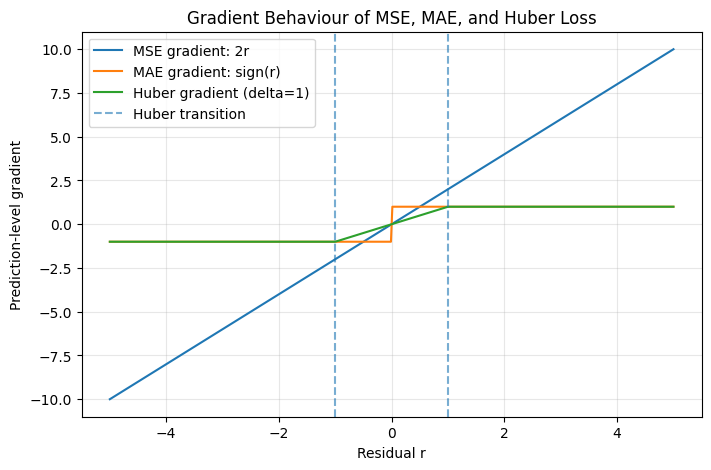

In [28]:
r_values = np.linspace(-5, 5, 400)
delta = 1.0

mse_gradient = 2.0 * r_values
mae_gradient = np.sign(r_values)

huber_gradient = np.where(
    np.abs(r_values) <= delta,
    r_values,
    delta * np.sign(r_values)
)

plt.figure(figsize=(8, 5))

plt.plot(
    r_values,
    mse_gradient,
    label="MSE gradient: 2r"
)

plt.plot(
    r_values,
    mae_gradient,
    label="MAE gradient: sign(r)"
)

plt.plot(
    r_values,
    huber_gradient,
    label="Huber gradient (delta=1)"
)

plt.axvline(
    x=-delta,
    linestyle="--",
    alpha=0.6
)

plt.axvline(
    x=delta,
    linestyle="--",
    alpha=0.6,
    label="Huber transition"
)

plt.xlabel("Residual r")
plt.ylabel("Prediction-level gradient")
plt.title("Gradient Behaviour of MSE, MAE, and Huber Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **Part 9: Finite-Difference Gradient Checking**

Central finite differences provide an independent check of the hand-derived gradient functions and can reveal scaling, sign, feature-factor, or piecewise-condition errors.

$$ \boxed{ \text{Analytical Gradient} \approx \text{Numerical Gradient} } $$


### Numerical gradient using central finite differences

The checker uses the central-difference approximation because it is generally more accurate than a one-sided difference. One generic function is used for all three losses.

$$ L(w) $$

$$ \frac{dL}{dw} = \lim_{h\rightarrow0} \frac{L(w+h)-L(w)}{h} $$

$$ \boxed{ \frac{\partial L}{\partial w} \approx \frac{L(w+\epsilon)-L(w-\epsilon)} {2\epsilon} } $$

$$ \epsilon $$


The numerical slope and intercept gradients perturb one parameter at a time. Keyword arguments allow the same checker to pass the Huber threshold without a separate implementation.

$$ L(w+\epsilon,b) $$

$$ L(w-\epsilon,b) $$

$$ \boxed{ \frac{\partial L}{\partial w} \approx \frac{ L(w+\epsilon,b)-L(w-\epsilon,b) }{ 2\epsilon } } $$

$$ \boxed{ \frac{\partial L}{\partial b} \approx \frac{ L(w,b+\epsilon)-L(w,b-\epsilon) }{ 2\epsilon } } $$


In [29]:
# Numerical gradient using central finite differences
# Used to verify our analytical gradient implementations

def numerical_gradients(
    x,
    y_true,
    w,
    b,
    loss_function,
    epsilon=1e-5,
    **loss_kwargs
):
    """
    Approximate dL/dw and dL/db using central differences.
    """

    # Numerical gradient with respect to w
    loss_w_plus = loss_function(
        y_true,
        predict(x, w + epsilon, b),
        **loss_kwargs
    )

    loss_w_minus = loss_function(
        y_true,
        predict(x, w - epsilon, b),
        **loss_kwargs
    )

    dw_numeric = (
        loss_w_plus - loss_w_minus
    ) / (2.0 * epsilon)

    # Numerical gradient with respect to b
    loss_b_plus = loss_function(
        y_true,
        predict(x, w, b + epsilon),
        **loss_kwargs
    )

    loss_b_minus = loss_function(
        y_true,
        predict(x, w, b - epsilon),
        **loss_kwargs
    )

    db_numeric = (
        loss_b_plus - loss_b_minus
    ) / (2.0 * epsilon)

    return dw_numeric, db_numeric

### Small dataset for gradient checking

A deterministic small dataset is used so that the gradient checks are reproducible.


In [30]:
# Small dataset for gradient checking

x_check = np.array([-1.5, -0.5, 0.5, 2.0])
y_check = np.array([-2.0, 0.5, 2.5, 7.0])

w_check = 0.8
b_check = 0.3

y_pred_check = predict(
    x_check,
    w_check,
    b_check
)

print("x:", x_check)
print("True targets:", y_check)
print("Predictions:", y_pred_check)
print("Residuals:", residuals(
    y_check,
    y_pred_check
))

x: [-1.5 -0.5  0.5  2. ]
True targets: [-2.   0.5  2.5  7. ]
Predictions: [-0.9 -0.1  0.7  1.9]
Residuals: [ 1.1 -0.6 -1.8 -5.1]


### Check MSE Gradient

The analytical and numerical MSE gradients are compared first.


In [31]:
# Gradient check: MSE

# Analytical gradient
dw_analytical, db_analytical = mse_gradients(
    x_check,
    y_check,
    y_pred_check
)

# Numerical gradient
dw_numerical, db_numerical = numerical_gradients(
    x_check,
    y_check,
    w_check,
    b_check,
    mse_loss
)

print("MSE Gradient Check")
print("------------------")
print("Analytical dw:", dw_analytical)
print("Numerical  dw:", dw_numerical)
print("Difference dw:", abs(
    dw_analytical - dw_numerical
))

print()

print("Analytical db:", db_analytical)
print("Numerical  db:", db_numerical)
print("Difference db:", abs(
    db_analytical - db_numerical
))

MSE Gradient Check
------------------
Analytical dw: -6.225
Numerical  dw: -6.224999999915325
Difference dw: 8.467448964211144e-11

Analytical db: -3.2
Numerical  db: -3.2000000000032
Difference db: 3.199662756969701e-12


### Check MAE Gradient

The MAE check avoids zero residuals because MAE is not differentiable there.


In [32]:
# Gradient check: MAE
# Avoid checking exactly at residual = 0

dw_analytical, db_analytical = mae_gradients(
    x_check,
    y_check,
    y_pred_check
)

dw_numerical, db_numerical = numerical_gradients(
    x_check,
    y_check,
    w_check,
    b_check,
    mae_loss
)

print("MAE Gradient Check")
print("------------------")
print("Analytical dw:", dw_analytical)
print("Numerical  dw:", dw_numerical)
print("Difference dw:", abs(
    dw_analytical - dw_numerical
))

print()

print("Analytical db:", db_analytical)
print("Numerical  db:", db_numerical)
print("Difference db:", abs(
    db_analytical - db_numerical
))

MAE Gradient Check
------------------
Analytical dw: -0.875
Numerical  dw: -0.8749999999890788
Difference dw: 1.0921152870935202e-11

Analytical db: -0.5
Numerical  db: -0.5000000000254801
Difference db: 2.5480062504357193e-11


### Check Huber Gradient

The Huber check uses threshold 1 and avoids placing a test residual exactly on the transition boundary.

$$ |r|=\delta $$

$$ \delta=1 $$


In [33]:
# Gradient check: Huber

delta_check = 1.0

dw_analytical, db_analytical = huber_gradients(
    x_check,
    y_check,
    y_pred_check,
    delta=delta_check
)

dw_numerical, db_numerical = numerical_gradients(
    x_check,
    y_check,
    w_check,
    b_check,
    huber_loss,
    delta=delta_check
)

print("Huber Gradient Check")
print("--------------------")
print("Analytical dw:", dw_analytical)
print("Numerical  dw:", dw_numerical)
print("Difference dw:", abs(
    dw_analytical - dw_numerical
))

print()

print("Analytical db:", db_analytical)
print("Numerical  db:", db_numerical)
print("Difference db:", abs(
    db_analytical - db_numerical
))

Huber Gradient Check
--------------------
Analytical dw: -0.925
Numerical  dw: -0.9249999999849655
Difference dw: 1.5034529177171407e-11

Analytical db: -0.4
Numerical  db: -0.39999999998929775
Difference db: 1.0702272401630353e-11


### Automatic Gradient Check Summary

All three analytical gradients agree with central finite differences within a small tolerance.


In [34]:
# Automatic gradient-check summary

def gradient_check_passed(
    analytical,
    numerical,
    tolerance=1e-6
):
    return abs(analytical - numerical) < tolerance


gradient_checks = []

# MSE
mse_dw_a, mse_db_a = mse_gradients(
    x_check,
    y_check,
    y_pred_check
)

mse_dw_n, mse_db_n = numerical_gradients(
    x_check,
    y_check,
    w_check,
    b_check,
    mse_loss
)

gradient_checks.append([
    "MSE",
    gradient_check_passed(mse_dw_a, mse_dw_n),
    gradient_check_passed(mse_db_a, mse_db_n)
])

# MAE
mae_dw_a, mae_db_a = mae_gradients(
    x_check,
    y_check,
    y_pred_check
)

mae_dw_n, mae_db_n = numerical_gradients(
    x_check,
    y_check,
    w_check,
    b_check,
    mae_loss
)

gradient_checks.append([
    "MAE",
    gradient_check_passed(mae_dw_a, mae_dw_n),
    gradient_check_passed(mae_db_a, mae_db_n)
])

# Huber
huber_dw_a, huber_db_a = huber_gradients(
    x_check,
    y_check,
    y_pred_check,
    delta=delta_check
)

huber_dw_n, huber_db_n = numerical_gradients(
    x_check,
    y_check,
    w_check,
    b_check,
    huber_loss,
    delta=delta_check
)

gradient_checks.append([
    "Huber",
    gradient_check_passed(huber_dw_a, huber_dw_n),
    gradient_check_passed(huber_db_a, huber_db_n)
])

print("Gradient Check Summary")
print("----------------------")

for loss_name, dw_pass, db_pass in gradient_checks:
    print(
        f"{loss_name}: "
        f"dw={'PASS' if dw_pass else 'FAIL'}, "
        f"db={'PASS' if db_pass else 'FAIL'}"
    )

Gradient Check Summary
----------------------
MSE: dw=PASS, db=PASS
MAE: dw=PASS, db=PASS
Huber: dw=PASS, db=PASS


## **Part 10: Batch Gradient Descent Training Loop**

Batch Gradient Descent updates the slope and intercept using the full-dataset analytical gradients and a fixed learning rate.

$$ \frac{\partial L}{\partial w}, \qquad \frac{\partial L}{\partial b} $$

$$ \boxed{ w^{(t+1)} = w^{(t)} - \eta \frac{\partial L}{\partial w} } $$

$$ \boxed{ b^{(t+1)} = b^{(t)} - \eta \frac{\partial L}{\partial b} } $$

$$ \eta $$


Each epoch performs prediction, loss evaluation, gradient calculation, and a parameter update. Repetition should move the parameters toward the data-generating values.

$$ \boxed{ x \rightarrow \hat y \rightarrow L \rightarrow \nabla L \rightarrow w,b\text{ update} } $$

$$ \hat y=wx+b $$

$$ dw,\quad db $$

$$ w\leftarrow w-\eta dw $$

$$ b\leftarrow b-\eta db $$

$$ w\rightarrow3 $$

$$ b\rightarrow2 $$


Each update uses all 100 training observations, so the optimiser is Batch Gradient Descent rather than a sample-wise method.

$$ n=100 $$

$$ dw,\quad db $$

$$ \boxed{\text{Batch Gradient Descent}} $$


### Training Configuration

All losses start from the same zero parameters and use the same learning rate and 1000-epoch budget. The Huber threshold is fixed at 1, leaving the loss function as the main comparison variable.

$$ \boxed{w_0=0,\qquad b_0=0} $$

$$ \boxed{\eta=0.01} $$

$$ \boxed{\text{epochs}=1000} $$

$$ w_0,b_0,\eta,\text{epochs} $$


In [35]:
# Experiment 1 training configuration
# Same initialization and optimization settings are used
# for all loss functions

INITIAL_W = 0.0
INITIAL_B = 0.0

LEARNING_RATE = 0.01
EPOCHS = 1000

HUBER_DELTA = 1.0

print("Initial w:", INITIAL_W)
print("Initial b:", INITIAL_B)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)
print("Huber delta:", HUBER_DELTA)

Initial w: 0.0
Initial b: 0.0
Learning rate: 0.01
Epochs: 1000
Huber delta: 1.0


### General Training Function

The common trainer performs a forward pass, evaluates the selected loss, computes its analytical gradients, updates both parameters, and records the history. Passing the functions as arguments avoids separate training loops.

$$ \hat y=wx+b $$

$$ w_{t+1}=w_t-\eta\frac{\partial L}{\partial w} $$

$$ b_{t+1}=b_t-\eta\frac{\partial L}{\partial b} $$

$$ \boxed{ \text{Hypothesis} \rightarrow \text{Prediction} \rightarrow \text{Loss} \rightarrow \text{Gradient} \rightarrow \text{Parameter Update} } $$


In [36]:
# Batch Gradient Descent training function
# Uses the full training set for every parameter update

def train_model(
    x,
    y,
    loss_function,
    gradient_function,
    w_init=0.0,
    b_init=0.0,
    learning_rate=0.01,
    epochs=1000,
    **loss_kwargs
):
    """
    Train a one-dimensional linear regression model
    using Batch Gradient Descent.

    Returns
    -------
    w : float
        Final learned slope.
    b : float
        Final learned intercept.
    history : dict
        Training history containing loss, w, and b.
    """

    # Initialize parameters
    w = float(w_init)
    b = float(b_init)

    # Store training history for later analysis
    history = {
        "loss": [],
        "w": [],
        "b": []
    }

    for epoch in range(epochs):

        # Forward pass: compute predictions
        y_pred = predict(x, w, b)

        # Compute current loss
        loss = loss_function(
            y,
            y_pred,
            **loss_kwargs
        )

        # Compute analytical gradients
        dw, db = gradient_function(
            x,
            y,
            y_pred,
            **loss_kwargs
        )

        # Store the current state before updating parameters
        history["loss"].append(loss)
        history["w"].append(w)
        history["b"].append(b)

        # Batch Gradient Descent parameter update
        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, history

### Train Clean Baseline with MSE

MSE is trained first to verify the common training loop on clean data.


In [37]:
# Test the training loop using MSE on clean data

w_mse, b_mse, history_mse = train_model(
    x_train,
    y_train,
    loss_function=mse_loss,
    gradient_function=mse_gradients,
    w_init=INITIAL_W,
    b_init=INITIAL_B,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS
)

print("MSE Clean Baseline")
print("------------------")
print("Learned w:", w_mse)
print("Learned b:", b_mse)

print()
print("True w:", W_TRUE)
print("True b:", B_TRUE)

print()
print("Initial loss:", history_mse["loss"][0])
print("Final recorded loss:", history_mse["loss"][-1])

MSE Clean Baseline
------------------
Learned w: 2.954022677119307
Learned b: 1.98520953954571

True w: 3.0
True b: 2.0

Initial loss: 78.48115138537644
Final recorded loss: 0.8065845639670536


### MSE Convergence Curve

A decreasing final loss and a stable convergence curve check that the trainer is working.

$$ L_{\text{final}} < L_{\text{initial}} $$


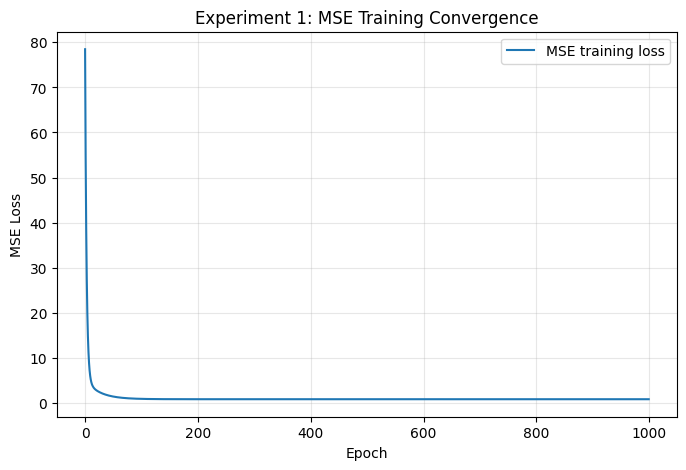

In [38]:
# Visualise MSE training convergence

plt.figure(figsize=(8, 5))

plt.plot(
    history_mse["loss"],
    label="MSE training loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Experiment 1: MSE Training Convergence")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Visualise how w and b change during training

Convergence to the empirical optimum does not require exact recovery of the generating parameters. Finite noisy samples naturally make the fitted optimum slightly different from the ground truth.

$$ w $$

$$ 3 $$

$$ b $$

$$ 2 $$

$$ w_{\text{true}}=3,\quad b_{\text{true}}=2 $$

$$ y=3x+2+\epsilon $$


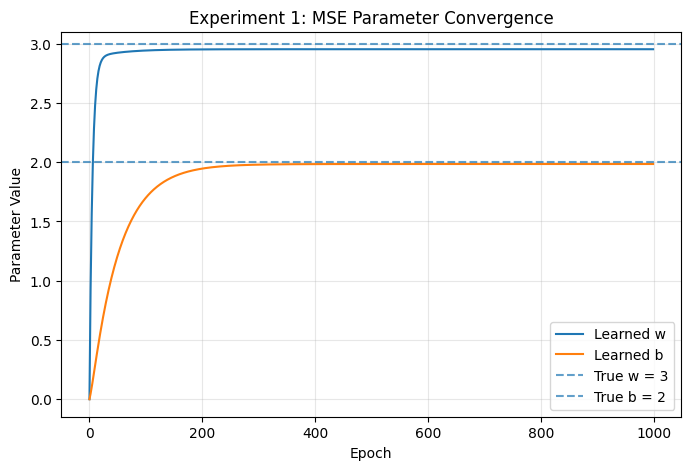

In [39]:
# Visualise how w and b change during training

plt.figure(figsize=(8, 5))

plt.plot(
    history_mse["w"],
    label="Learned w"
)

plt.plot(
    history_mse["b"],
    label="Learned b"
)

plt.axhline(
    y=W_TRUE,
    linestyle="--",
    alpha=0.7,
    label="True w = 3"
)

plt.axhline(
    y=B_TRUE,
    linestyle="--",
    alpha=0.7,
    label="True b = 2"
)

plt.xlabel("Epoch")
plt.ylabel("Parameter Value")
plt.title("Experiment 1: MSE Parameter Convergence")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **Part 11: Train MSE, MAE, and Huber on Clean Data**

MSE, MAE, and Huber are trained on identical clean data with identical optimisation settings; only the loss changes.

$$ \boxed{ \begin{aligned} &\text{Training data: same}\\ &w_0=0\\ &b_0=0\\ &\eta=0.01\\ &\text{epochs}=1000 \end{aligned} } $$

$$ \delta=1 $$

$$ \boxed{\text{Loss function}} $$


### Train All Three Loss Functions

In [40]:
# Experiment 1: Train all three loss functions
# under the same clean-data conditions

# MSE results are reused from Part 10

# Train with MAE
w_mae, b_mae, history_mae = train_model(
    x_train,
    y_train,
    loss_function=mae_loss,
    gradient_function=mae_gradients,
    w_init=INITIAL_W,
    b_init=INITIAL_B,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS
)

# Train with Huber loss
w_huber, b_huber, history_huber = train_model(
    x_train,
    y_train,
    loss_function=huber_loss,
    gradient_function=huber_gradients,
    w_init=INITIAL_W,
    b_init=INITIAL_B,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS,
    delta=HUBER_DELTA
)

print("Training completed for MSE, MAE, and Huber.")

Training completed for MSE, MAE, and Huber.


### Compare learned parameters with the ground truth

All three implementations recover parameters close to the known ground truth on clean data.

$$ \hat w,\hat b $$

$$ w_{\text{true}}=3,\qquad b_{\text{true}}=2 $$


In [41]:
# Compare learned parameters with the ground truth

print("Experiment 1: Learned Parameters")
print("--------------------------------")

print(f"True  : w = {W_TRUE:.4f}, b = {B_TRUE:.4f}")
print(f"MSE   : w = {w_mse:.4f}, b = {b_mse:.4f}")
print(f"MAE   : w = {w_mae:.4f}, b = {b_mae:.4f}")
print(f"Huber : w = {w_huber:.4f}, b = {b_huber:.4f}")

Experiment 1: Learned Parameters
--------------------------------
True  : w = 3.0000, b = 2.0000
MSE   : w = 2.9540, b = 1.9852
MAE   : w = 2.9296, b = 1.9428
Huber : w = 2.9532, b = 1.9616


### Parameter Recovery Error

Absolute slope and intercept errors quantify parameter recovery. In this clean sample, MSE is slightly closest, Huber is similar, and MAE differs a little more.

$$ \hat w=2.9540 $$

$$ |\hat w-3| \approx0.046 $$

$$ |\hat w-w_{\text{true}}| : 0.045977,\ 0.070373,\ 0.046763 $$

$$ 0.014790,\ 0.057200,\ 0.038396 $$


In [42]:
# ---------------------------------------------------------
# Parameter recovery error
# Measures how close the learned parameters are
# to the known synthetic ground truth
# ---------------------------------------------------------

parameter_errors = {
    "MSE": {
        "w_error": abs(w_mse - W_TRUE),
        "b_error": abs(b_mse - B_TRUE)
    },
    "MAE": {
        "w_error": abs(w_mae - W_TRUE),
        "b_error": abs(b_mae - B_TRUE)
    },
    "Huber": {
        "w_error": abs(w_huber - W_TRUE),
        "b_error": abs(b_huber - B_TRUE)
    }
}

print("Parameter Recovery Error")
print("------------------------")

for loss_name, errors in parameter_errors.items():
    print(
        f"{loss_name:5s}: "
        f"|w - w_true| = {errors['w_error']:.6f}, "
        f"|b - b_true| = {errors['b_error']:.6f}"
    )

Parameter Recovery Error
------------------------
MSE  : |w - w_true| = 0.045977, |b - b_true| = 0.014790
MAE  : |w - w_true| = 0.070373, |b - b_true| = 0.057200
Huber: |w - w_true| = 0.046763, |b - b_true| = 0.038396


### Three Training Loss Curves

The raw loss curves are used only to check descent, stability, and whether training has plateaued. Their absolute heights are not comparable because the losses have different scales.

$$ \boxed{\text{check that each loss converges stably}} $$

$$ L_t\downarrow $$

$$ L_t\rightarrow\infty $$

$$ \eta=0.01 $$

$$ L_{\text{MSE}}\approx78 $$

$$ L_{\text{MSE}},L_{\text{MAE}},L_{\text{Huber}} $$


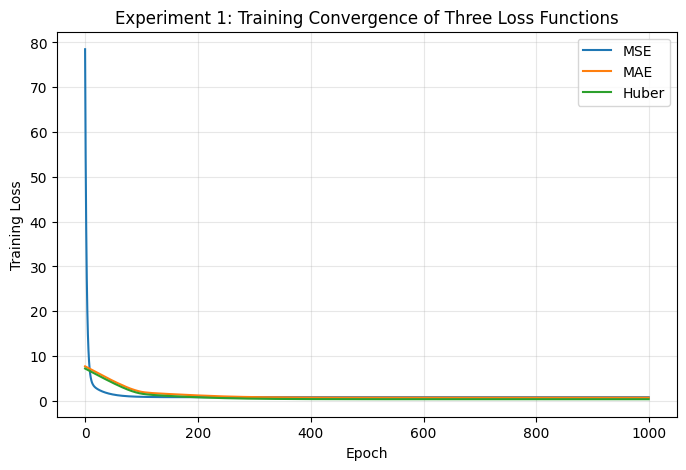

In [43]:
# Compare training convergence
# Note: raw loss values have different mathematical scales,
# so this plot is used to inspect convergence behaviour only

plt.figure(figsize=(8, 5))

plt.plot(
    history_mse["loss"],
    label="MSE"
)

plt.plot(
    history_mae["loss"],
    label="MAE"
)

plt.plot(
    history_huber["loss"],
    label="Huber"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Experiment 1: Training Convergence of Three Loss Functions")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Compare Parameter Trajectories:  Slope Convergence

The slope trajectories show how each loss approaches the target slope.


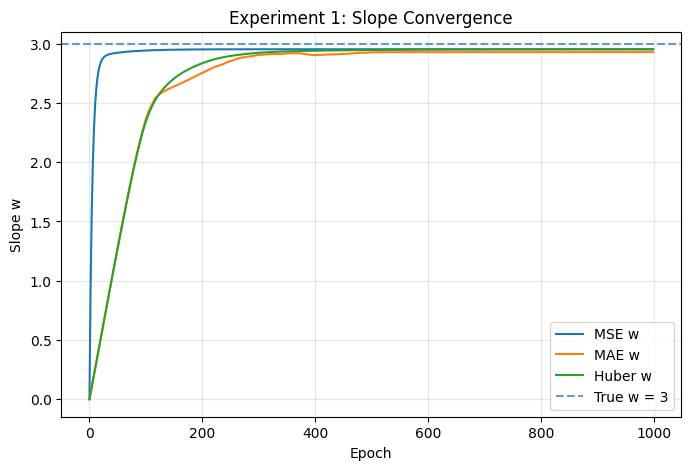

In [44]:
# Compare parameter trajectories during clean training

plt.figure(figsize=(8, 5))

plt.plot(
    history_mse["w"],
    label="MSE w"
)

plt.plot(
    history_mae["w"],
    label="MAE w"
)

plt.plot(
    history_huber["w"],
    label="Huber w"
)

plt.axhline(
    y=W_TRUE,
    linestyle="--",
    alpha=0.7,
    label="True w = 3"
)

plt.xlabel("Epoch")
plt.ylabel("Slope w")
plt.title("Experiment 1: Slope Convergence")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Intercept Convergence

The intercept converges more slowly than the slope because the slope gradient is multiplied by the feature value, whereas the intercept gradient is not.

$$ \frac{\partial L}{\partial w} \propto \sum g_i x_i $$

$$ \frac{\partial L}{\partial b} \propto \sum g_i $$

$$ [-5,5] $$


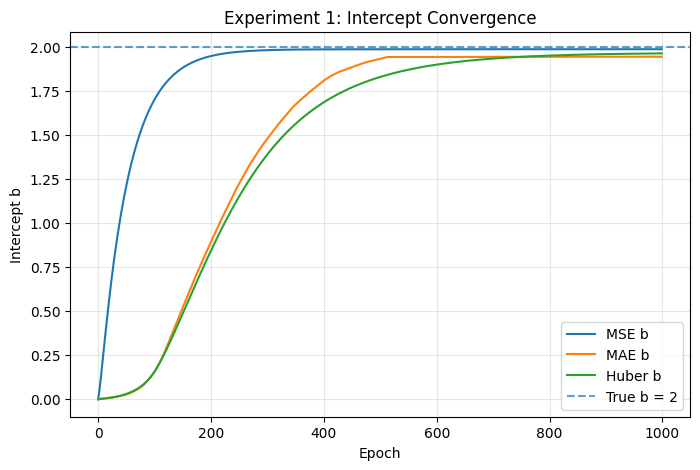

In [45]:
# Compare intercept trajectories during clean training

plt.figure(figsize=(8, 5))

plt.plot(
    history_mse["b"],
    label="MSE b"
)

plt.plot(
    history_mae["b"],
    label="MAE b"
)

plt.plot(
    history_huber["b"],
    label="Huber b"
)

plt.axhline(
    y=B_TRUE,
    linestyle="--",
    alpha=0.7,
    label="True b = 2"
)

plt.xlabel("Epoch")
plt.ylabel("Intercept b")
plt.title("Experiment 1: Intercept Convergence")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **Part 12: Clean Test Evaluation and Fitted Lines**

The models optimise different training objectives, so they are evaluated on the same clean test set with common RMSE and MAE metrics.

$$ L_{\text{MSE}},\quad L_{\text{MAE}},\quad L_{\text{Huber}} $$

$$ \boxed{\text{RMSE}} $$

$$ \boxed{\text{MAE}} $$

$$ \boxed{ \text{RMSE} = \sqrt{ \frac1n \sum_{i=1}^{n} (\hat y_i-y_i)^2 } } $$

$$ \boxed{ \text{MAE} = \frac1n \sum_{i=1}^{n} |\hat y_i-y_i| } $$


### Evaluation Metrics from Scratch

Both evaluation metrics are implemented from residuals and applied consistently to every model.

$$ \sqrt{\frac1n\sum r_i^2} $$

$$ \frac1n\sum |r_i| $$


In [46]:
# Evaluation metrics for clean test performance
# These metrics are used consistently across all models

def rmse_metric(y_true, y_pred):
    """
    Compute Root Mean Squared Error.
    """
    r = residuals(y_true, y_pred)
    return np.sqrt(np.mean(r ** 2))


def mae_metric(y_true, y_pred):
    """
    Compute Mean Absolute Error.
    """
    r = residuals(y_true, y_pred)
    return np.mean(np.abs(r))

### Predict on the Clean Test Set

The fitted parameters are used only for inference on the clean test set; no further updates occur. The three results are close, as expected for the clean baseline.

$$ x_{\text{test}} \rightarrow \hat y_{\text{test}} $$


In [47]:
# Generate predictions on the clean test set

y_test_pred_mse = predict(
    x_test,
    w_mse,
    b_mse
)

y_test_pred_mae = predict(
    x_test,
    w_mae,
    b_mae
)

y_test_pred_huber = predict(
    x_test,
    w_huber,
    b_huber
)

In [48]:
# Evaluate all models on the same clean test set

test_results = {
    "MSE": {
        "RMSE": rmse_metric(
            y_test,
            y_test_pred_mse
        ),
        "MAE": mae_metric(
            y_test,
            y_test_pred_mse
        )
    },

    "MAE": {
        "RMSE": rmse_metric(
            y_test,
            y_test_pred_mae
        ),
        "MAE": mae_metric(
            y_test,
            y_test_pred_mae
        )
    },

    "Huber": {
        "RMSE": rmse_metric(
            y_test,
            y_test_pred_huber
        ),
        "MAE": mae_metric(
            y_test,
            y_test_pred_huber
        )
    }
}

print("Experiment 1: Clean Test Performance")
print("-----------------------------------")

for loss_name, metrics in test_results.items():
    print(
        f"{loss_name:5s}: "
        f"RMSE = {metrics['RMSE']:.6f}, "
        f"MAE = {metrics['MAE']:.6f}"
    )

Experiment 1: Clean Test Performance
-----------------------------------
MSE  : RMSE = 0.917086, MAE = 0.727272
MAE  : RMSE = 0.939039, MAE = 0.744422
Huber: RMSE = 0.918949, MAE = 0.728775


### Fitted Lines

The test points, true relationship, and three fitted lines are shown together. The fitted lines nearly overlap the ground truth.

$$ \text{True} ,\quad \text{MSE} ,\quad \text{MAE} ,\quad \text{Huber} $$


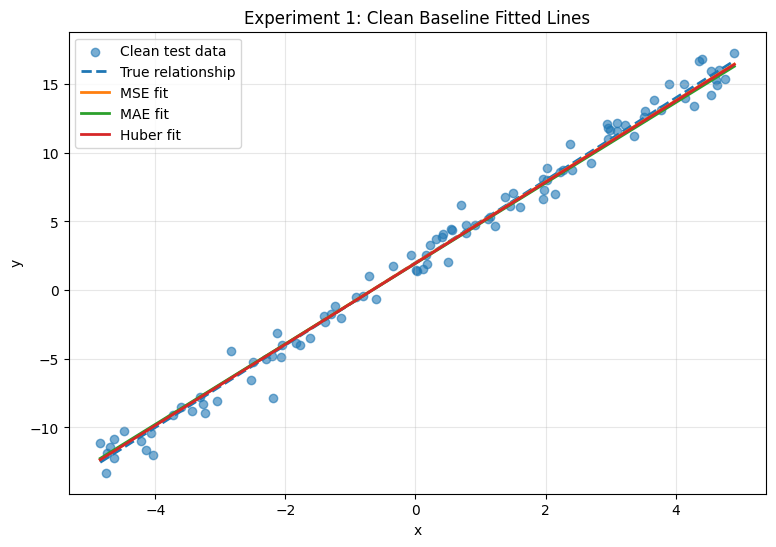

In [49]:
# Visualise fitted regression lines on clean test data

x_line = np.linspace(
    min(x_test),
    max(x_test),
    300
)

y_true_line = W_TRUE * x_line + B_TRUE

y_mse_line = predict(
    x_line,
    w_mse,
    b_mse
)

y_mae_line = predict(
    x_line,
    w_mae,
    b_mae
)

y_huber_line = predict(
    x_line,
    w_huber,
    b_huber
)

plt.figure(figsize=(9, 6))

plt.scatter(
    x_test,
    y_test,
    alpha=0.6,
    label="Clean test data"
)

plt.plot(
    x_line,
    y_true_line,
    linestyle="--",
    linewidth=2,
    label="True relationship"
)

plt.plot(
    x_line,
    y_mse_line,
    linewidth=2,
    label="MSE fit"
)

plt.plot(
    x_line,
    y_mae_line,
    linewidth=2,
    label="MAE fit"
)

plt.plot(
    x_line,
    y_huber_line,
    linewidth=2,
    label="Huber fit"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(
    "Experiment 1: Clean Baseline Fitted Lines"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Experiment 1 Summary

All three from-scratch losses learn the clean linear relationship reliably. MSE has slightly lower recovery and test errors in this Gaussian-noise sample, but the differences are small. This validates the losses, gradients, and optimiser before contamination is introduced.


In [50]:
# ---------------------------------------------------------
# Experiment 1 summary
# ---------------------------------------------------------

print("Experiment 1: Clean Baseline Summary")
print("------------------------------------")

print(
    f"{'Loss':<8}"
    f"{'w':>10}"
    f"{'b':>10}"
    f"{'|w-w*|':>12}"
    f"{'|b-b*|':>12}"
    f"{'Test RMSE':>14}"
    f"{'Test MAE':>12}"
)

print("-" * 78)

models = {
    "MSE": (
        w_mse,
        b_mse
    ),
    "MAE": (
        w_mae,
        b_mae
    ),
    "Huber": (
        w_huber,
        b_huber
    )
}

for name, (w, b) in models.items():

    print(
        f"{name:<8}"
        f"{w:>10.4f}"
        f"{b:>10.4f}"
        f"{abs(w - W_TRUE):>12.4f}"
        f"{abs(b - B_TRUE):>12.4f}"
        f"{test_results[name]['RMSE']:>14.4f}"
        f"{test_results[name]['MAE']:>12.4f}"
    )

Experiment 1: Clean Baseline Summary
------------------------------------
Loss             w         b      |w-w*|      |b-b*|     Test RMSE    Test MAE
------------------------------------------------------------------------------
MSE         2.9540    1.9852      0.0460      0.0148        0.9171      0.7273
MAE         2.9296    1.9428      0.0704      0.0572        0.9390      0.7444
Huber       2.9532    1.9616      0.0468      0.0384        0.9189      0.7288


## **Implementation Log — 05/09/2026**

**Development stage:** Experiment 1 — Clean Baseline

The main task was to implement prediction, three losses, their analytical gradients, and Batch Gradient Descent from scratch. Small numerical examples and central finite differences verified the loss and gradient implementations before the shared trainer was used. Under identical optimisation settings, all three losses recovered parameters close to the generating relationship and established the clean baseline.

**Use of AI tools:** ChatGPT helped organise the notebook, translate equations into NumPy, and identify verification methods. I checked all suggestions against the derivations, manual examples, gradient checks, and notebook outputs.

**Learning:** This experiment clarified the link from prediction to loss, gradient, and parameter update. It also showed why raw loss values cannot rank objectives with different mathematical scales.


# **Experiment 2: Outlier Magnitude**

## **Part 1: Controlled Vertical-Outlier Setup**

This experiment changes the magnitude of one vertical outlier while keeping all other experimental conditions fixed.

The selected sample keeps the same x-value, and only its y-value is shifted upward. This allows us to isolate the effect of outlier magnitude without changing the contamination proportion or introducing a high-leverage point.

### Experiment 2 Configuration

A training point near x = 2 is selected so that the experiment varies vertical magnitude without also using an extreme-leverage input. The magnitude is the added vertical shift, with zero serving as the internal baseline.

$$ x = 2 $$

$$ \text{vertical-outlier magnitude} $$

$$ \text{high leverage} $$

$$ M = y_{\text{modified}} - y_{\text{original}} $$


In [51]:
# Controlled variable: vertical-outlier magnitude

# Use the same selected sample throughout Experiment 2
# Select x near 2 to avoid confounding vertical magnitude with leverage
OUTLIER_INDEX = np.argmin(np.abs(x_train - 2.0))

# Apply controlled vertical shifts to this target
OUTLIER_MAGNITUDES = np.array([
    0.0,
    5.0,
    10.0,
    20.0,
    40.0
])

print("Experiment 2 Configuration")
print("--------------------------")
print("Outlier index:", OUTLIER_INDEX)
print("Selected x:", x_train[OUTLIER_INDEX])
print("Original y:", y_train[OUTLIER_INDEX])
print("Outlier magnitudes:", OUTLIER_MAGNITUDES)

Experiment 2 Configuration
--------------------------
Outlier index: 74
Selected x: 2.0685734384761716
Original y: 8.456213165774392
Outlier magnitudes: [ 0.  5. 10. 20. 40.]


### Create Vertical Outlier

This helper copies the clean arrays and adds the chosen shift to one target only. The original Experiment 1 data remain unchanged.

$$ y_i \rightarrow y_i + M $$

$$ x_i \text{ unchanged} $$


In [52]:
def create_vertical_outlier(
    x,
    y,
    outlier_index,
    magnitude
):
    """
    Create a dataset with one controlled vertical outlier.
    """

    # Copy the arrays to preserve the clean training data
    x_modified = x.copy()
    y_modified = y.copy()

    # Change only the selected target
    y_modified[outlier_index] += magnitude

    return x_modified, y_modified

### Sanity Check

The check confirms that the selected input is unchanged and the target increases by exactly 20, creating a vertical outlier.

$$ (x_i, y_i) \rightarrow (x_i, y_i + 20) $$


In [53]:
# Check that a magnitude of 20 changes only the target
example_magnitude = 20.0

x_example, y_example = create_vertical_outlier(
    x_train,
    y_train,
    OUTLIER_INDEX,
    example_magnitude
)

print("Vertical-Outlier Sanity Check")
print("-----------------------------")

print("Original x:", x_train[OUTLIER_INDEX])
print("Modified x:", x_example[OUTLIER_INDEX])

print()

print("Original y:", y_train[OUTLIER_INDEX])
print("Modified y:", y_example[OUTLIER_INDEX])

print()

print(
    "Actual y shift:",
    y_example[OUTLIER_INDEX] - y_train[OUTLIER_INDEX]
)

Vertical-Outlier Sanity Check
-----------------------------
Original x: 2.0685734384761716
Modified x: 2.0685734384761716

Original y: 8.456213165774392
Modified y: 28.456213165774393

Actual y shift: 20.0


### Visualise Outlier Magnitudes

The plot verifies the intervention: the same point moves only upward as magnitude increases, while the dataset size, input value, contamination proportion, and true relationship remain fixed.

$$ y = 3x + 2 $$

$$ M $$

$$ x_i,\quad \text{sample index},\quad \text{dataset size},\quad \text{contamination proportion},\quad \text{true relationship} $$


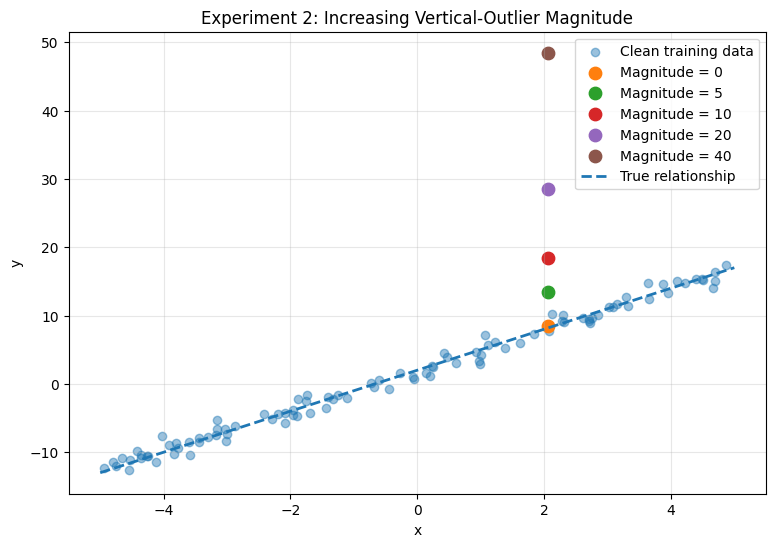

In [54]:
plt.figure(figsize=(9, 6))

# Plot the clean training data
plt.scatter(
    x_train,
    y_train,
    alpha=0.45,
    label="Clean training data"
)

# Plot the selected sample at each magnitude
for magnitude in OUTLIER_MAGNITUDES:

    _, y_modified = create_vertical_outlier(
        x_train,
        y_train,
        OUTLIER_INDEX,
        magnitude
    )

    plt.scatter(
        x_train[OUTLIER_INDEX],
        y_modified[OUTLIER_INDEX],
        s=80,
        label=f"Magnitude = {magnitude:g}"
    )

# Plot the data-generating relationship
x_line_exp2 = np.linspace(-5, 5, 300)
y_true_line_exp2 = W_TRUE * x_line_exp2 + B_TRUE

plt.plot(
    x_line_exp2,
    y_true_line_exp2,
    linestyle="--",
    linewidth=2,
    label="True relationship"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Experiment 2: Increasing Vertical-Outlier Magnitude")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **Part 2: Sample-Level Loss and Gradient Influence**

Before retraining, the selected sample is evaluated at one fixed clean reference model. This isolates the path from outlier magnitude to residual, sample loss, and gradient without confounding it with already-shifted learned parameters.

$$ \text{outlier magnitude} \rightarrow \text{residual} \rightarrow \text{sample loss / gradient} $$

$$ \hat y = 2.9540x + 1.9852 $$


### Set Reference Parameters


In [55]:
# Use the clean MSE model as the fixed reference

REFERENCE_W = 2.9540
REFERENCE_B = 1.9852

print("Reference model")
print("---------------")
print("w =", REFERENCE_W)
print("b =", REFERENCE_B)

Reference model
---------------
w = 2.954
b = 1.9852


### Sample-Level Loss Functions

Sample-level helpers report an individual observation's contribution rather than the batch mean. They use the same MSE, MAE, and Huber definitions and the same Huber threshold as Experiment 1.

$$ L = \frac{1}{n} \sum_{i=1}^{n} L_i $$

$$ L_i $$

$$ L_i^{MSE}=r_i^2 $$

$$ L_i^{MAE}=|r_i| $$

$$ L_i^{Huber}= \begin{cases} \frac12r_i^2,& |r_i|\le\delta\\ \delta(|r_i|-\frac12\delta),& |r_i|>\delta \end{cases} $$


In [56]:
def mse_sample_loss(residual):
    """Single-sample MSE loss."""
    return residual ** 2


def mae_sample_loss(residual):
    """Single-sample MAE loss."""
    return np.abs(residual)


def huber_sample_loss(residual, delta=HUBER_DELTA):
    """Single-sample Huber loss."""
    abs_r = np.abs(residual)

    if abs_r <= delta:
        return 0.5 * residual ** 2
    else:
        return delta * (abs_r - 0.5 * delta)

### Prediction-Level Gradient

The prediction-level MSE gradient grows with residual magnitude, MAE remains at unit magnitude away from zero, and Huber is capped by its threshold outside the quadratic region.

$$ r = \hat y-y $$

$$ \frac{\partial L_i}{\partial \hat y_i}=2r_i $$

$$ \frac{\partial L_i}{\partial \hat y_i} = \operatorname{sign}(r_i) $$

$$ 1 $$

$$ |r_i|\le \delta $$

$$ \frac{\partial L}{\partial\hat y}=r $$

$$ |r_i|>\delta $$

$$ \frac{\partial L}{\partial\hat y} = \delta\operatorname{sign}(r) $$

$$ \delta $$


In [57]:
def mse_prediction_gradient(residual):
    """dL_i / d(y_hat_i) for MSE."""
    return 2.0 * residual


def mae_prediction_gradient(residual):
    """dL_i / d(y_hat_i) for MAE."""
    return np.sign(residual)


def huber_prediction_gradient(residual, delta=HUBER_DELTA):
    """dL_i / d(y_hat_i) for Huber Loss."""
    if np.abs(residual) <= delta:
        return residual
    else:
        return delta * np.sign(residual)

### Compute Sample-Level Influence

For each magnitude, the fixed reference prediction yields a residual, a sample loss, and a prediction-level gradient. The chain rule then converts that value to the sample's raw slope and intercept contributions; the batch average is not applied here.

$$ y_i' = y_i + M $$

$$ \hat y_i = w_{ref}x_i+b_{ref} $$

$$ r_i=\hat y_i-y_i' $$

$$ L_i^{MSE},\quad L_i^{MAE},\quad L_i^{Huber} $$

$$ \frac{\partial L_i}{\partial\hat y_i} $$

$$ \hat y_i=wx_i+b $$

$$ \frac{\partial \hat y_i}{\partial w}=x_i $$

$$ \frac{\partial \hat y_i}{\partial b}=1 $$

$$ \frac{\partial L_i}{\partial w} = \frac{\partial L_i}{\partial\hat y_i}x_i $$

$$ \frac{\partial L_i}{\partial b} = \frac{\partial L_i}{\partial\hat y_i} $$

$$ \text{Residual} \rightarrow \text{Gradient} \rightarrow \text{Parameter Update} $$

$$ \frac{\partial L}{\partial w} $$

$$ \frac{1}{n}\sum_i \frac{\partial L_i}{\partial w} $$

$$ \frac{\partial L_i}{\partial w} $$


In [58]:
sample_influence_results = []

x_selected = x_train[OUTLIER_INDEX]

for magnitude in OUTLIER_MAGNITUDES:

    # Construct the outlier at this magnitude
    _, y_modified = create_vertical_outlier(
        x_train,
        y_train,
        OUTLIER_INDEX,
        magnitude
    )

    y_selected = y_modified[OUTLIER_INDEX]

    # Predict with the fixed reference model
    y_hat_selected = predict(
        np.array([x_selected]),
        REFERENCE_W,
        REFERENCE_B
    )[0]

    # Keep the residual convention: prediction minus target
    residual = y_hat_selected - y_selected

    # MSE
    mse_loss_i = mse_sample_loss(residual)
    mse_dyhat = mse_prediction_gradient(residual)

    # MAE
    mae_loss_i = mae_sample_loss(residual)
    mae_dyhat = mae_prediction_gradient(residual)

    # Huber
    huber_loss_i = huber_sample_loss(
        residual,
        HUBER_DELTA
    )
    huber_dyhat = huber_prediction_gradient(
        residual,
        HUBER_DELTA
    )

    # Convert to raw parameter-gradient contributions
    sample_influence_results.append({
        "Magnitude": magnitude,
        "Residual": residual,

        "MSE Loss": mse_loss_i,
        "MSE dL/dy_hat": mse_dyhat,
        "MSE dL/dw": mse_dyhat * x_selected,
        "MSE dL/db": mse_dyhat,

        "MAE Loss": mae_loss_i,
        "MAE dL/dy_hat": mae_dyhat,
        "MAE dL/dw": mae_dyhat * x_selected,
        "MAE dL/db": mae_dyhat,

        "Huber Loss": huber_loss_i,
        "Huber dL/dy_hat": huber_dyhat,
        "Huber dL/dw": huber_dyhat * x_selected,
        "Huber dL/db": huber_dyhat
    })

# Keep the results in a Python list
sample_influence_results

[{'Magnitude': np.float64(0.0),
  'Residual': np.float64(-0.36044722851577937),
  'MSE Loss': np.float64(0.1299222045447065),
  'MSE dL/dy_hat': np.float64(-0.7208944570315587),
  'MSE dL/dw': np.float64(-1.4912231257601842),
  'MSE dL/db': np.float64(-0.7208944570315587),
  'MAE Loss': np.float64(0.36044722851577937),
  'MAE dL/dy_hat': np.float64(-1.0),
  'MAE dL/dw': np.float64(-2.0685734384761716),
  'MAE dL/db': np.float64(-1.0),
  'Huber Loss': np.float64(0.06496110227235324),
  'Huber dL/dy_hat': np.float64(-0.36044722851577937),
  'Huber dL/dw': np.float64(-0.7456115628800921),
  'Huber dL/db': np.float64(-0.36044722851577937)},
 {'Magnitude': np.float64(5.0),
  'Residual': np.float64(-5.360447228515779),
  'MSE Loss': np.float64(28.7343944897025),
  'MSE dL/dy_hat': np.float64(-10.720894457031559),
  'MSE dL/dw': np.float64(-22.1769575105219),
  'MSE dL/db': np.float64(-10.720894457031559),
  'MAE Loss': np.float64(5.360447228515779),
  'MAE dL/dy_hat': np.float64(-1.0),
  'MA

### Compact Comparison Table

The residual becomes more negative as the target is shifted upward. MSE loss grows quadratically and its slope-gradient contribution grows with residual magnitude, while MAE remains bounded. Huber changes from its quadratic region at magnitude zero to the same bounded large-residual contribution thereafter. Negative gradients correctly push the line upward at this positive input.

$$ r=\hat y-y $$

$$ 0.1299\rightarrow28.7344\rightarrow107.3389 \rightarrow414.5478\rightarrow1628.9657 $$

$$ L_{MSE}=r^2 $$

$$ 0.3604\rightarrow5.3604\rightarrow10.3604 \rightarrow20.3604\rightarrow40.3604 $$

$$ L_{MAE}=|r| $$

$$ 0.0650\rightarrow4.8604\rightarrow9.8604 \rightarrow19.8604\rightarrow39.8604 $$

$$ |r|=0.3604<\delta=1 $$

$$ L=\frac12r^2\approx0.0650 $$

$$ |r|>\delta $$

$$ \frac{\partial L_i}{\partial w} = 2r_ix_i $$

$$ \left|\frac{\partial L_i}{\partial w}\right| $$

$$ \frac{\partial L_i}{\partial w} = \operatorname{sign}(r_i)x_i $$

$$ \frac{\partial L_i}{\partial w}=-2.0686 $$

$$ |r|<\delta $$

$$ |r|>\delta $$

$$ \frac{\partial L}{\partial\hat y} = -\delta=-1 $$

$$ \frac{\partial L}{\partial w} = -1(2.0686) = -2.0686 $$

$$ w_{t+1} = w_t-\eta\frac{\partial L}{\partial w} $$

$$ \frac{\partial L}{\partial w}<0 $$

$$ -\eta\frac{\partial L}{\partial w}>0 $$

$$ x\approx2.07>0 $$


In [59]:
# ---------------------------------------------------------
# Compact comparison table
# ---------------------------------------------------------

print(
    f"{'Magnitude':>10} "
    f"{'Residual':>10} "
    f"{'MSE Loss':>12} "
    f"{'MAE Loss':>12} "
    f"{'Huber Loss':>12} "
    f"{'MSE dL/dw':>12} "
    f"{'MAE dL/dw':>12} "
    f"{'Huber dL/dw':>14}"
)

print("-" * 108)

for row in sample_influence_results:
    print(
        f"{row['Magnitude']:10.1f} "
        f"{row['Residual']:10.4f} "
        f"{row['MSE Loss']:12.4f} "
        f"{row['MAE Loss']:12.4f} "
        f"{row['Huber Loss']:12.4f} "
        f"{row['MSE dL/dw']:12.4f} "
        f"{row['MAE dL/dw']:12.4f} "
        f"{row['Huber dL/dw']:14.4f}"
    )

 Magnitude   Residual     MSE Loss     MAE Loss   Huber Loss    MSE dL/dw    MAE dL/dw    Huber dL/dw
------------------------------------------------------------------------------------------------------------
       0.0    -0.3604       0.1299       0.3604       0.0650      -1.4912      -2.0686        -0.7456
       5.0    -5.3604      28.7344       5.3604       4.8604     -22.1770      -2.0686        -2.0686
      10.0   -10.3604     107.3389      10.3604       9.8604     -42.8627      -2.0686        -2.0686
      20.0   -20.3604     414.5478      20.3604      19.8604     -84.2342      -2.0686        -2.0686
      40.0   -40.3604    1628.9657      40.3604      39.8604    -166.9771      -2.0686        -2.0686


### Visualising Sample-Level Influence

The plots compare the selected sample's loss and gradient contribution as vertical-outlier magnitude increases.


MSE bends upward, whereas MAE grows linearly. Huber is quadratic only near zero and is approximately parallel to MAE once the residual exceeds the threshold.

$$ \text{Outlier Magnitude} \rightarrow L_i $$


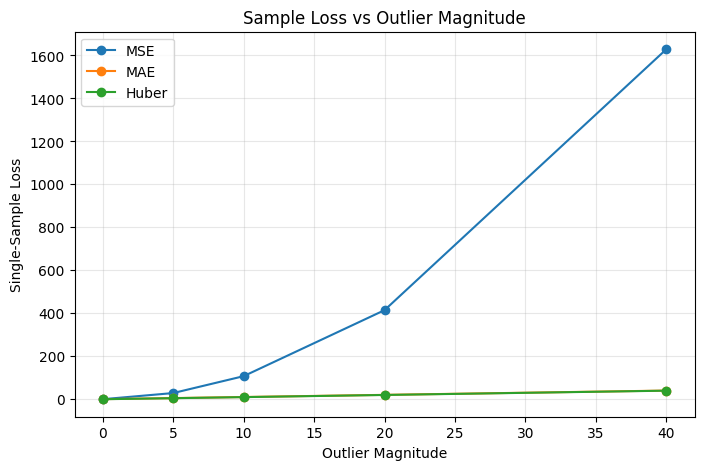

In [60]:
# Sample Loss vs Outlier Magnitude

magnitudes = [
    row["Magnitude"]
    for row in sample_influence_results
]

mse_losses = [
    row["MSE Loss"]
    for row in sample_influence_results
]

mae_losses = [
    row["MAE Loss"]
    for row in sample_influence_results
]

huber_losses = [
    row["Huber Loss"]
    for row in sample_influence_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    magnitudes,
    mse_losses,
    marker="o",
    label="MSE"
)

plt.plot(
    magnitudes,
    mae_losses,
    marker="o",
    label="MAE"
)

plt.plot(
    magnitudes,
    huber_losses,
    marker="o",
    label="Huber"
)

plt.xlabel("Outlier Magnitude")
plt.ylabel("Single-Sample Loss")
plt.title("Sample Loss vs Outlier Magnitude")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

The slope-gradient plot makes the mechanism explicit: MSE influence continues to grow, while MAE and Huber plateau after the residual enters their bounded-gradient regimes.

$$ \text{Loss} \rightarrow \text{Gradient} \rightarrow \text{Parameter Update} $$

$$ |\text{MSE }dL/dw| = 1.49,\ 22.18,\ 42.86,\ 84.23,\ 166.98 $$

$$ |\text{MAE }dL/dw| = 2.0686 $$

$$ |\text{Huber }dL/dw| = 2.0686 $$

$$ \text{MSE: continued growth} $$

$$ \text{MAE / Huber: plateau} $$


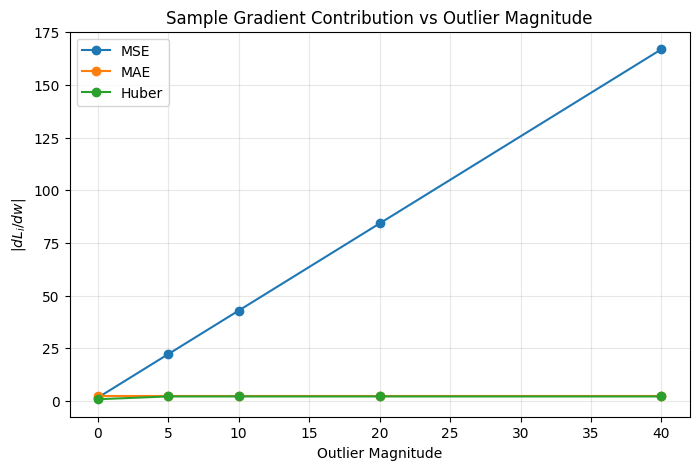

In [61]:
# Gradient Contribution vs Outlier Magnitude

mse_dw = [
    abs(row["MSE dL/dw"])
    for row in sample_influence_results
]

mae_dw = [
    abs(row["MAE dL/dw"])
    for row in sample_influence_results
]

huber_dw = [
    abs(row["Huber dL/dw"])
    for row in sample_influence_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    magnitudes,
    mse_dw,
    marker="o",
    label="MSE"
)

plt.plot(
    magnitudes,
    mae_dw,
    marker="o",
    label="MAE"
)

plt.plot(
    magnitudes,
    huber_dw,
    marker="o",
    label="Huber"
)

plt.xlabel("Outlier Magnitude")
plt.ylabel(r"$|dL_i/dw|$")
plt.title("Sample Gradient Contribution vs Outlier Magnitude")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **Part 3: Training Across Outlier Magnitudes**

The three losses are trained on datasets containing the same selected vertical outlier at increasing magnitudes. Data construction changes, but the optimiser, initialisation, and training budget remain fixed.


### Train All Three Losses Across Magnitudes

The verified common trainer and all Experiment 1 optimisation settings are reused. Outlier magnitude is the only changing condition.

$$ \text{same model} +\text{same optimizer} +\text{same initialization} +\text{same epochs} $$

$$ M $$


In [62]:
#Train Models Across Outlier Magnitudes

experiment2_training_results = []

for magnitude in OUTLIER_MAGNITUDES:

    # Construct the contaminated data for this magnitude
    x_contaminated, y_contaminated = create_vertical_outlier(
        x_train,
        y_train,
        OUTLIER_INDEX,
        magnitude
    )

    # MSE
    w_mse_exp2, b_mse_exp2, history_mse_exp2 = train_model(
        x_contaminated,
        y_contaminated,
        loss_function=mse_loss,
        gradient_function=mse_gradients,
        w_init=INITIAL_W,
        b_init=INITIAL_B,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS
    )

    # MAE
    w_mae_exp2, b_mae_exp2, history_mae_exp2 = train_model(
        x_contaminated,
        y_contaminated,
        loss_function=mae_loss,
        gradient_function=mae_gradients,
        w_init=INITIAL_W,
        b_init=INITIAL_B,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS
    )

    # Huber
    w_huber_exp2, b_huber_exp2, history_huber_exp2 = train_model(
        x_contaminated,
        y_contaminated,
        loss_function=huber_loss,
        gradient_function=huber_gradients,
        w_init=INITIAL_W,
        b_init=INITIAL_B,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS,
        delta=HUBER_DELTA
    )

    experiment2_training_results.append({
        "Magnitude": magnitude,

        "MSE w": w_mse_exp2,
        "MSE b": b_mse_exp2,
        "MSE history": history_mse_exp2,

        "MAE w": w_mae_exp2,
        "MAE b": b_mae_exp2,
        "MAE history": history_mae_exp2,

        "Huber w": w_huber_exp2,
        "Huber b": b_huber_exp2,
        "Huber history": history_huber_exp2
    })

print("Experiment 2 training completed.")

Experiment 2 training completed.


### Learned Parameters

Magnitude zero reproduces the clean baseline. Increasing magnitude steadily moves the MSE parameters; MAE remains unchanged once the residual sign is fixed; Huber changes slightly when the point crosses its threshold and then plateaus.

$$ w: 2.9540\rightarrow3.0621 $$

$$ b: 1.9852\rightarrow2.4174 $$

$$ |r|\uparrow \Rightarrow \left|\frac{\partial L_{MSE}}{\partial \hat y}\right|\uparrow $$

$$ x_i\approx2.0686>0 $$

$$ w=2.9296,\qquad b=1.9428 $$

$$ \frac{\partial L}{\partial\hat y} = \operatorname{sign}(r) $$

$$ -5.36\rightarrow-40.36 $$

$$ \frac{\partial L}{\partial\hat y}=-1 $$

$$ (2.9532,1.9616) \rightarrow (2.9555,1.9707) $$

$$ |r|=0.3604<\delta=1 $$

$$ |r|=5.3604>\delta $$

$$ \frac{\partial L}{\partial\hat y} = -\delta=-1 $$

$$ 5\rightarrow10\rightarrow20\rightarrow40 $$


In [63]:
# Learned Parameters Across Outlier Magnitudes

print(
    f"{'Magnitude':>10} "
    f"{'MSE w':>10} "
    f"{'MSE b':>10} "
    f"{'MAE w':>10} "
    f"{'MAE b':>10} "
    f"{'Huber w':>10} "
    f"{'Huber b':>10}"
)

print("-" * 76)

for row in experiment2_training_results:

    print(
        f"{row['Magnitude']:10.1f} "
        f"{row['MSE w']:10.4f} "
        f"{row['MSE b']:10.4f} "
        f"{row['MAE w']:10.4f} "
        f"{row['MAE b']:10.4f} "
        f"{row['Huber w']:10.4f} "
        f"{row['Huber b']:10.4f}"
    )

 Magnitude      MSE w      MSE b      MAE w      MAE b    Huber w    Huber b
----------------------------------------------------------------------------
       0.0     2.9540     1.9852     2.9296     1.9428     2.9532     1.9616
       5.0     2.9675     2.0392     2.9296     1.9428     2.9555     1.9707
      10.0     2.9810     2.0933     2.9296     1.9428     2.9555     1.9707
      20.0     3.0080     2.2013     2.9296     1.9428     2.9555     1.9707
      40.0     3.0621     2.4174     2.9296     1.9428     2.9555     1.9707


### Parameter Shift from Clean Baseline

Parameter shift measures displacement from each loss's clean solution. MSE shifts approximately linearly with magnitude because its gradient is linear in the residual. MAE shows no additional visible shift, while Huber shifts once and then plateaus.

$$ \text{Parameter Shift} = |\hat\theta_{\text{contaminated}}-\hat\theta_{\text{clean}}| $$

$$ M=5\Rightarrow|\Delta w|=0.0135 $$

$$ M=10\Rightarrow|\Delta w|=0.0270 $$

$$ M=20\Rightarrow|\Delta w|=0.0540 $$

$$ M=40\Rightarrow|\Delta w|=0.1081 $$

$$ |\Delta w| $$

$$ 0.0540 \rightarrow0.1081 \rightarrow0.2161 \rightarrow0.4322 $$

$$ |\Delta b|\propto M $$

$$ \frac{\partial L}{\partial\hat y}=2r $$

$$ L=r^2 $$

$$ \frac{\partial L}{\partial\hat y}=2r $$

$$ |\Delta w|=|\Delta b|=0 $$

$$ |\Delta w|=0.0022 $$

$$ |\Delta b|=0.0091 $$

$$ \boxed{\text{Huber parameter influence plateau}} $$

$$ |r|\uparrow $$

$$ \left| \frac{\partial L}{\partial\hat y} \right| =\delta $$


In [64]:
# Parameter Shift from Clean Baseline

for row in experiment2_training_results:

    row["MSE w shift"] = abs(
        row["MSE w"] - w_mse
    )

    row["MSE b shift"] = abs(
        row["MSE b"] - b_mse
    )

    row["MAE w shift"] = abs(
        row["MAE w"] - w_mae
    )

    row["MAE b shift"] = abs(
        row["MAE b"] - b_mae
    )

    row["Huber w shift"] = abs(
        row["Huber w"] - w_huber
    )

    row["Huber b shift"] = abs(
        row["Huber b"] - b_huber
    )

print(
    f"{'Magnitude':>10} "
    f"{'MSE |Δw|':>12} "
    f"{'MSE |Δb|':>12} "
    f"{'MAE |Δw|':>12} "
    f"{'MAE |Δb|':>12} "
    f"{'Huber |Δw|':>14} "
    f"{'Huber |Δb|':>14}"
)

print("-" * 92)

for row in experiment2_training_results:

    print(
        f"{row['Magnitude']:10.1f} "
        f"{row['MSE w shift']:12.4f} "
        f"{row['MSE b shift']:12.4f} "
        f"{row['MAE w shift']:12.4f} "
        f"{row['MAE b shift']:12.4f} "
        f"{row['Huber w shift']:14.4f} "
        f"{row['Huber b shift']:14.4f}"
    )

 Magnitude     MSE |Δw|     MSE |Δb|     MAE |Δw|     MAE |Δb|     Huber |Δw|     Huber |Δb|
--------------------------------------------------------------------------------------------
       0.0       0.0000       0.0000       0.0000       0.0000         0.0000         0.0000
       5.0       0.0135       0.0540       0.0000       0.0000         0.0022         0.0091
      10.0       0.0270       0.1081       0.0000       0.0000         0.0022         0.0091
      20.0       0.0540       0.2161       0.0000       0.0000         0.0022         0.0091
      40.0       0.1081       0.4322       0.0000       0.0000         0.0022         0.0091


### Visualise Slope Shift

The slope-shift plot shows a near-linear MSE increase, a flat MAE response, and a small Huber transition followed by a plateau.

$$ |\Delta w|\propto M $$

$$ |\Delta w|=0 $$

$$ 0.0022 $$


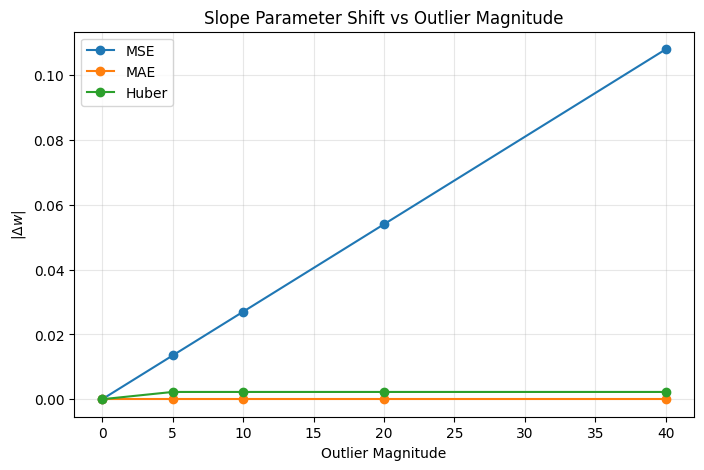

In [65]:
# Slope Shift vs Outlier Magnitude

mse_w_shift = [
    row["MSE w shift"]
    for row in experiment2_training_results
]

mae_w_shift = [
    row["MAE w shift"]
    for row in experiment2_training_results
]

huber_w_shift = [
    row["Huber w shift"]
    for row in experiment2_training_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    OUTLIER_MAGNITUDES,
    mse_w_shift,
    marker="o",
    label="MSE"
)

plt.plot(
    OUTLIER_MAGNITUDES,
    mae_w_shift,
    marker="o",
    label="MAE"
)

plt.plot(
    OUTLIER_MAGNITUDES,
    huber_w_shift,
    marker="o",
    label="Huber"
)

plt.xlabel("Outlier Magnitude")
plt.ylabel(r"$|\Delta w|$")
plt.title("Slope Parameter Shift vs Outlier Magnitude")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Together, the sample- and model-level results connect increasing residual magnitude to unbounded MSE updates, bounded MAE updates, and thresholded Huber updates.

$$ \boxed{ \text{Increasing Outlier Magnitude} } $$

$$ \boxed{ \text{Increasing }|Residual| } $$

$$ r^2 \rightarrow |2r|\uparrow \rightarrow \text{stronger updates} \rightarrow |\Delta w|,|\Delta b|\uparrow $$

$$ |r| \rightarrow |\operatorname{sign}(r)|=1 \rightarrow \text{bounded updates} \rightarrow \text{no additional visible shift} $$

$$ \text{quadratic} \rightarrow |r|>\delta \rightarrow |\partial L/\partial\hat y|=\delta \rightarrow \text{parameter shift plateaus} $$

$$ \text{Outlier}\rightarrow\text{Residual}\rightarrow\text{Loss} \rightarrow\text{Gradient}\rightarrow\text{Parameter Update} \rightarrow\text{Learned Model} $$


### Parameter Recovery

Parameter recovery is distinct from displacement from the clean fit. A contaminated estimate can move toward the true value by chance when the clean finite-sample estimate already lies on the other side.

$$ \text{Parameter Recovery Error} = |\hat\theta-\theta_{\text{true}}| $$

$$ \hat w=2.9540 $$

$$ w^*=3 $$

$$ |\hat w-w^*| = |2.9540-3| = 0.0460 $$

$$ \hat w=2.9675 $$

$$ \hat w=2.9810 $$

$$ \hat w=3.0080 $$

$$ \hat w=3.0621 $$

$$ 0.0460 \rightarrow 0.0325 \rightarrow 0.0190 \rightarrow 0.0080 \rightarrow 0.0621 $$

$$ w^*=3 $$

$$ |\hat w_{\text{outlier}}-\hat w_{\text{clean}}| $$

$$ |\hat w-w^*| $$


In [66]:
# Parameter Recovery Error

for row in experiment2_training_results:

    # MSE parameter errors
    row["MSE w error"] = abs(
        row["MSE w"] - W_TRUE
    )

    row["MSE b error"] = abs(
        row["MSE b"] - B_TRUE
    )

    # MAE parameter errors
    row["MAE w error"] = abs(
        row["MAE w"] - W_TRUE
    )

    row["MAE b error"] = abs(
        row["MAE b"] - B_TRUE
    )

    # Huber parameter errors
    row["Huber w error"] = abs(
        row["Huber w"] - W_TRUE
    )

    row["Huber b error"] = abs(
        row["Huber b"] - B_TRUE
    )

### Parameter Recovery Table

MSE slope recovery first improves and then worsens because the upward intervention temporarily offsets sampling error before overshooting. Its intercept error worsens steadily. MAE recovery is stable rather than uniformly most accurate, and Huber shows a small transition followed by a plateau.

$$ 0.0460 \rightarrow0.0325 \rightarrow0.0190 \rightarrow\boxed{0.0080} \rightarrow0.0621 $$

$$ \hat w_{\text{clean}}=2.9540<3 $$

$$ 2.9540 \rightarrow2.9675 \rightarrow2.9810 \rightarrow3.0080 \rightarrow3.0621 $$

$$ 3.0080\rightarrow3.0621 $$

$$ \boxed{\text{accidental compensation}} $$

$$ |\hat b-b^*| $$

$$ 0.0148 \rightarrow0.0392 \rightarrow0.0933 \rightarrow0.2013 \rightarrow0.4174 $$

$$ \hat b=1.9852 $$

$$ 1.9852 \rightarrow2.0392 \rightarrow2.0933 \rightarrow2.2013 \rightarrow2.4174 $$

$$ \boxed{\text{robustness cannot be judged from one parameter}} $$

$$ |\hat w-w^*|=0.0080 $$

$$ |\hat b-b^*|=0.2013 $$

$$ |\hat w-w^*|=0.0704 $$

$$ |\hat b-b^*|=0.0572 $$

$$ \hat w=2.9296 $$

$$ 0.0704 $$

$$ \boxed{\text{stability against increasing outlier magnitude}} $$

$$ 0.0468 \rightarrow0.0445 \rightarrow0.0445 \rightarrow0.0445 \rightarrow0.0445 $$

$$ 0.0384 \rightarrow0.0293 \rightarrow0.0293 \rightarrow0.0293 \rightarrow0.0293 $$

$$ |r|=0.3604<\delta $$

$$ |r|>\delta $$

$$ (2.9532,1.9616) \rightarrow (2.9555,1.9707) $$

$$ M=5,10,20,40 $$


In [67]:
# Parameter Recovery Table

print(
    f"{'Magnitude':>10} "
    f"{'MSE |w-w*|':>12} "
    f"{'MSE |b-b*|':>12} "
    f"{'MAE |w-w*|':>12} "
    f"{'MAE |b-b*|':>12} "
    f"{'Huber |w-w*|':>14} "
    f"{'Huber |b-b*|':>14}"
)

print("-" * 92)

for row in experiment2_training_results:

    print(
        f"{row['Magnitude']:10.1f} "
        f"{row['MSE w error']:12.4f} "
        f"{row['MSE b error']:12.4f} "
        f"{row['MAE w error']:12.4f} "
        f"{row['MAE b error']:12.4f} "
        f"{row['Huber w error']:14.4f} "
        f"{row['Huber b error']:14.4f}"
    )

 Magnitude   MSE |w-w*|   MSE |b-b*|   MAE |w-w*|   MAE |b-b*|   Huber |w-w*|   Huber |b-b*|
--------------------------------------------------------------------------------------------
       0.0       0.0460       0.0148       0.0704       0.0572         0.0468         0.0384
       5.0       0.0325       0.0392       0.0704       0.0572         0.0445         0.0293
      10.0       0.0190       0.0933       0.0704       0.0572         0.0445         0.0293
      20.0       0.0080       0.2013       0.0704       0.0572         0.0445         0.0293
      40.0       0.0621       0.4174       0.0704       0.0572         0.0445         0.0293


### Visualise Parameter Recovery

The recovery plot and displacement plot answer different questions. MSE displacement grows monotonically even while its slope error temporarily falls; MAE is stable, and Huber changes slightly before stabilising.

$$ |\hat w-w_{\text{true}}| $$

$$ 0\rightarrow0.0135\rightarrow0.0270 \rightarrow0.0540\rightarrow0.1081 $$

$$ \downarrow\quad\text{then}\quad\uparrow $$

$$ 0.046\rightarrow0.008 $$

$$ 0.008\rightarrow0.062 $$

$$ |\Delta w|: 0\rightarrow0.0135\rightarrow0.027 \rightarrow0.054\rightarrow0.1081 $$

$$ \boxed{ \text{Low recovery error} \not\Rightarrow \text{Low outlier influence} } $$

$$ |\hat w-w^*|=0.0704 $$

$$ 0.0468 $$

$$ 0.0445 $$


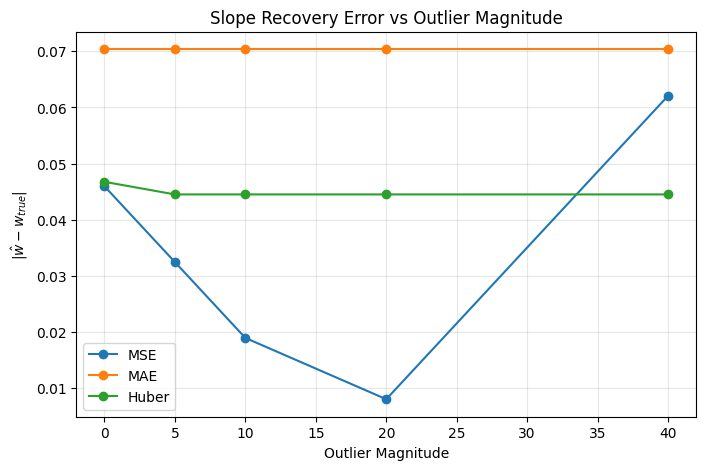

In [68]:
# Slope Recovery Error vs Outlier Magnitude

mse_w_error = [
    row["MSE w error"]
    for row in experiment2_training_results
]

mae_w_error = [
    row["MAE w error"]
    for row in experiment2_training_results
]

huber_w_error = [
    row["Huber w error"]
    for row in experiment2_training_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    OUTLIER_MAGNITUDES,
    mse_w_error,
    marker="o",
    label="MSE"
)

plt.plot(
    OUTLIER_MAGNITUDES,
    mae_w_error,
    marker="o",
    label="MAE"
)

plt.plot(
    OUTLIER_MAGNITUDES,
    huber_w_error,
    marker="o",
    label="Huber"
)

plt.xlabel("Outlier Magnitude")
plt.ylabel(r"$|\hat{w} - w_{true}|$")
plt.title("Slope Recovery Error vs Outlier Magnitude")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **Part 4: Clean-Test Performance and Fitted-Line Analysis**

All models are evaluated on the unchanged clean test set. This separates contaminated training conditions from the evaluation distribution and supports comparison with common metrics.


### Evaluate Every Trained Model on the Clean Test Set

The same test inputs and targets are reused for every condition, avoiding test-sampling variation. Both RMSE and MAE are reported because the models optimise different objectives.

$$ \text{only training contamination changes} $$


In [69]:
for row in experiment2_training_results:

    # MSE-trained model
    y_pred_mse = predict(
        x_test,
        row["MSE w"],
        row["MSE b"]
    )

    row["MSE test RMSE"] = rmse_metric(
        y_test,
        y_pred_mse
    )

    row["MSE test MAE"] = mae_metric(
        y_test,
        y_pred_mse
    )

    # MAE-trained model
    y_pred_mae = predict(
        x_test,
        row["MAE w"],
        row["MAE b"]
    )

    row["MAE test RMSE"] = rmse_metric(
        y_test,
        y_pred_mae
    )

    row["MAE test MAE"] = mae_metric(
        y_test,
        y_pred_mae
    )

    # Huber-trained model
    y_pred_huber = predict(
        x_test,
        row["Huber w"],
        row["Huber b"]
    )

    row["Huber test RMSE"] = rmse_metric(
        y_test,
        y_pred_huber
    )

    row["Huber test MAE"] = mae_metric(
        y_test,
        y_pred_huber
    )

### Clean-Test Performance Table

Moderate upward contamination may temporarily offset finite-sample estimation error, so MSE test error need not worsen monotonically from magnitude zero. Such a change is accidental compensation, not improved robustness.


MSE improves slightly at moderate magnitudes and then degrades at the largest magnitude because the intervention first offsets and later exceeds existing sampling error. MAE predictions remain unchanged, trading some clean-data efficiency for stability. Huber changes once as the point enters its linear region and then plateaus.

$$ \hat w=2.9540,\qquad \hat b=1.9852 $$

$$ w^*=3,\qquad b^*=2 $$

$$ 0.9171\rightarrow0.9083\rightarrow0.9047 $$

$$ 0.7273\rightarrow0.7184\rightarrow0.7147 $$

$$ RMSE=0.9916,\qquad MAE=0.7796 $$

$$ RMSE=0.9390 $$

$$ MAE=0.7444 $$

$$ \hat w=2.9296,\qquad\hat b=1.9428 $$

$$ \text{outlier magnitude increases} $$

$$ |\nabla L_{MAE}| $$

$$ 0.9390 $$

$$ 0.9171 $$

$$ 0.9189 $$

$$ RMSE: 0.9189\rightarrow0.9169\rightarrow0.9169\rightarrow0.9169\rightarrow0.9169 $$

$$ MAE: 0.7288\rightarrow0.7271\rightarrow0.7271\rightarrow0.7271\rightarrow0.7271 $$

$$ |r|<\delta $$

$$ |r|>\delta $$

$$ M=5\rightarrow40 $$

$$ \boxed{\text{small residual sensitivity + large residual robustness}} $$


In [70]:
print(
    f"{'Magnitude':>10} "
    f"{'MSE RMSE':>10} "
    f"{'MSE MAE':>10} "
    f"{'MAE RMSE':>10} "
    f"{'MAE MAE':>10} "
    f"{'Huber RMSE':>12} "
    f"{'Huber MAE':>12}"
)

print("-" * 82)

for row in experiment2_training_results:

    print(
        f"{row['Magnitude']:10.1f} "
        f"{row['MSE test RMSE']:10.4f} "
        f"{row['MSE test MAE']:10.4f} "
        f"{row['MAE test RMSE']:10.4f} "
        f"{row['MAE test MAE']:10.4f} "
        f"{row['Huber test RMSE']:12.4f} "
        f"{row['Huber test MAE']:12.4f}"
    )

 Magnitude   MSE RMSE    MSE MAE   MAE RMSE    MAE MAE   Huber RMSE    Huber MAE
----------------------------------------------------------------------------------
       0.0     0.9171     0.7273     0.9390     0.7444       0.9189       0.7288
       5.0     0.9083     0.7184     0.9390     0.7444       0.9169       0.7271
      10.0     0.9047     0.7147     0.9390     0.7444       0.9169       0.7271
      20.0     0.9136     0.7219     0.9390     0.7444       0.9169       0.7271
      40.0     0.9916     0.7796     0.9390     0.7444       0.9169       0.7271


### Visualise Clean-Test RMSE

Clean-test RMSE shows a shallow U-shape for MSE, a flat MAE curve, and a small Huber change followed by a plateau. This compares sensitivity and robustness on one common metric.

$$ RMSE = \sqrt{ \frac{1}{n} \sum_i (\hat y_i-y_i)^2 } $$

$$ 0.9171 \rightarrow 0.9047 \rightarrow 0.9916 $$

$$ 0.9390 $$

$$ 0.9189\rightarrow0.9169 $$


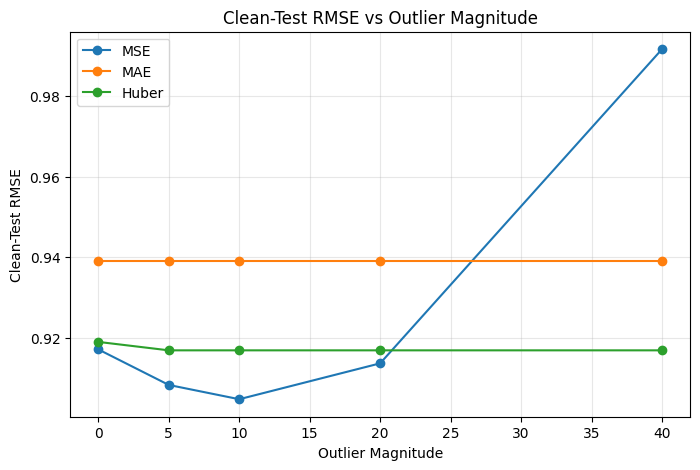

In [71]:
# Clean-Test RMSE vs Outlier Magnitude

mse_test_rmse = [
    row["MSE test RMSE"]
    for row in experiment2_training_results
]

mae_test_rmse = [
    row["MAE test RMSE"]
    for row in experiment2_training_results
]

huber_test_rmse = [
    row["Huber test RMSE"]
    for row in experiment2_training_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    OUTLIER_MAGNITUDES,
    mse_test_rmse,
    marker="o",
    label="MSE"
)

plt.plot(
    OUTLIER_MAGNITUDES,
    mae_test_rmse,
    marker="o",
    label="MAE"
)

plt.plot(
    OUTLIER_MAGNITUDES,
    huber_test_rmse,
    marker="o",
    label="Huber"
)

plt.xlabel("Outlier Magnitude")
plt.ylabel("Clean-Test RMSE")
plt.title("Clean-Test RMSE vs Outlier Magnitude")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Visualise Clean-Test MAE

Clean-test MAE has the same qualitative pattern as RMSE, confirming that the conclusion is not specific to squared evaluation error.

$$ MAE = \frac{1}{n} \sum_i |\hat y_i-y_i| $$

$$ RMSE + MAE $$

$$ RMSE=0.9916 $$

$$ MAE=0.7796 $$


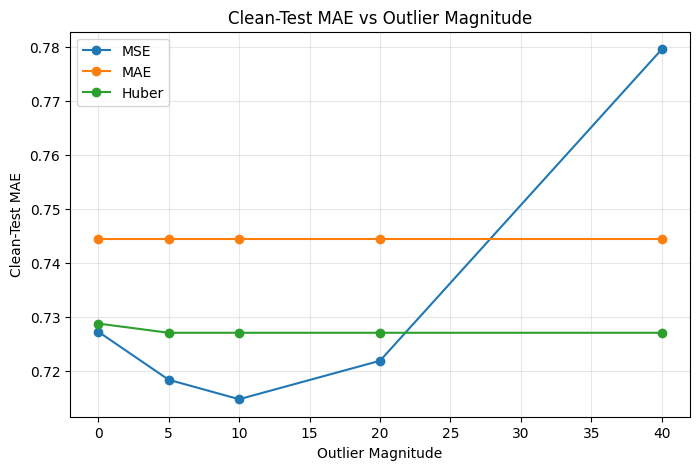

In [72]:
# Clean-Test MAE vs Outlier Magnitude

mse_test_mae = [
    row["MSE test MAE"]
    for row in experiment2_training_results
]

mae_test_mae = [
    row["MAE test MAE"]
    for row in experiment2_training_results
]

huber_test_mae = [
    row["Huber test MAE"]
    for row in experiment2_training_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    OUTLIER_MAGNITUDES,
    mse_test_mae,
    marker="o",
    label="MSE"
)

plt.plot(
    OUTLIER_MAGNITUDES,
    mae_test_mae,
    marker="o",
    label="MAE"
)

plt.plot(
    OUTLIER_MAGNITUDES,
    huber_test_mae,
    marker="o",
    label="Huber"
)

plt.xlabel("Outlier Magnitude")
plt.ylabel("Clean-Test MAE")
plt.title("Clean-Test MAE vs Outlier Magnitude")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Fitted Lines at Selected Magnitudes

Magnitudes 0, 20, and 40 provide clean, substantial, and extreme examples without overcrowding the fitted-line plots.

$$ M=0,\quad20,\quad40 $$


At magnitude zero, all fitted lines nearly overlap the truth. At 20, the MSE fit shifts upward mainly through the intercept even though its slope is close to the true value. At 40, the MSE shift is clearer, while MAE and Huber remain close to their earlier fits.

$$ w=3,\qquad b=2 $$

$$ y\approx28.5 $$

$$ \hat w_{MSE}=3.0080 $$

$$ \hat b_{MSE}=2.2013 $$

$$ |\hat w-w^*| $$

$$ \hat y=\hat wx+\hat b $$

$$ \hat w,\hat b $$

$$ y\approx48.5 $$

$$ \text{MSE}: (3.0621,2.4174) $$

$$ \text{Huber}: (2.9555,1.9707) $$

$$ \text{MAE}: (2.9296,1.9428) $$


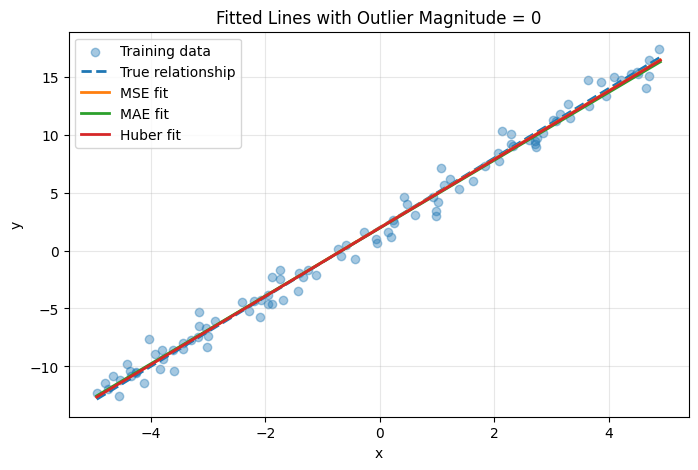

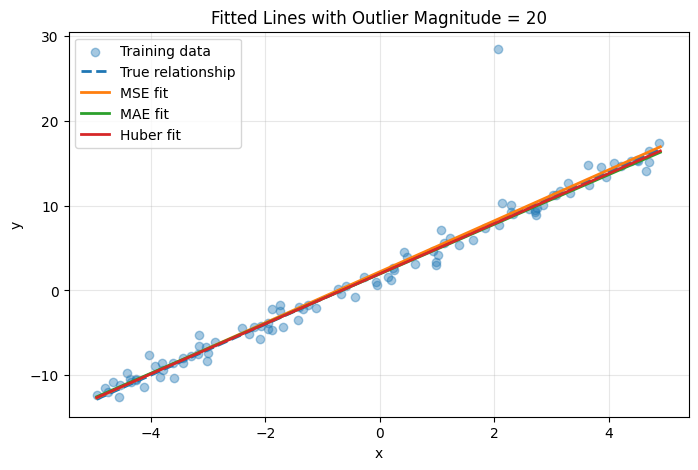

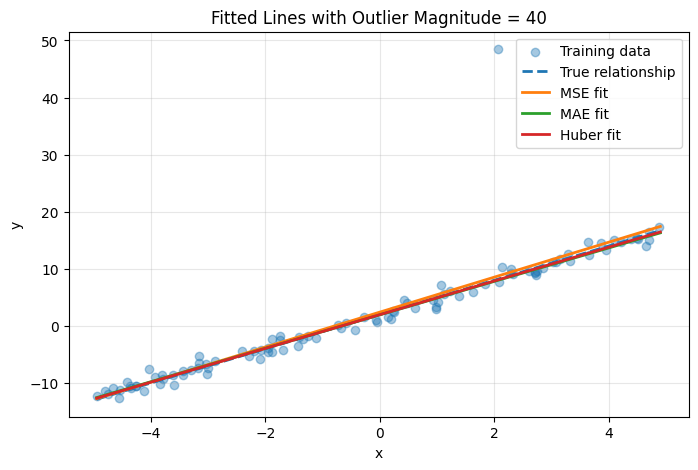

In [73]:
# Fitted Lines at Selected Outlier Magnitudes

SELECTED_MAGNITUDES = [0.0, 20.0, 40.0]

x_line_exp2_final = np.linspace(
    min(x_train.min(), x_test.min()),
    max(x_train.max(), x_test.max()),
    300
)

for magnitude in SELECTED_MAGNITUDES:

    # Retrieve the result for this magnitude
    row = next(
        result
        for result in experiment2_training_results
        if result["Magnitude"] == magnitude
    )

    # Recreate the corresponding contaminated data
    x_contaminated, y_contaminated = create_vertical_outlier(
        x_train,
        y_train,
        OUTLIER_INDEX,
        magnitude
    )

    # Predictions from the three fitted models
    y_line_mse = predict(
        x_line_exp2_final,
        row["MSE w"],
        row["MSE b"]
    )

    y_line_mae = predict(
        x_line_exp2_final,
        row["MAE w"],
        row["MAE b"]
    )

    y_line_huber = predict(
        x_line_exp2_final,
        row["Huber w"],
        row["Huber b"]
    )

    y_line_true = (
        W_TRUE * x_line_exp2_final
        + B_TRUE
    )

    plt.figure(figsize=(8, 5))

    # Training data for this magnitude
    plt.scatter(
        x_contaminated,
        y_contaminated,
        alpha=0.4,
        label="Training data"
    )

    # Data-generating relationship
    plt.plot(
        x_line_exp2_final,
        y_line_true,
        linestyle="--",
        linewidth=2,
        label="True relationship"
    )

    # Fitted models
    plt.plot(
        x_line_exp2_final,
        y_line_mse,
        linewidth=2,
        label="MSE fit"
    )

    plt.plot(
        x_line_exp2_final,
        y_line_mae,
        linewidth=2,
        label="MAE fit"
    )

    plt.plot(
        x_line_exp2_final,
        y_line_huber,
        linewidth=2,
        label="Huber fit"
    )

    plt.xlabel("x")
    plt.ylabel("y")

    plt.title(
        f"Fitted Lines with Outlier Magnitude = {magnitude:g}"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

The experiment traces outlier magnitude through residuals, loss gradients, parameter shifts, and clean-test behaviour. It explains the mechanisms rather than reducing the result to a single metric ranking.

$$ \boxed{\text{Outlier Magnitude}} $$

$$ \boxed{\text{Residual Magnitude}} $$

$$ r^2 \rightarrow |2r|\uparrow \rightarrow \text{larger gradient contribution} \rightarrow \text{larger parameter shift} \rightarrow \text{eventual clean-test degradation} $$

$$ |r| \rightarrow |\operatorname{sign}(r)|=1 \rightarrow \text{bounded gradient} \rightarrow \text{stable parameters} \rightarrow \text{stable clean-test performance} $$

$$ \text{quadratic for small }|r| $$

$$ |r|>\delta $$

$$ |\nabla L|=\delta $$

$$ \text{parameter influence plateaus} $$

$$ \text{clean-test performance plateaus} $$

$$ \text{Outlier} \rightarrow \text{Residual} \rightarrow \text{Loss} \rightarrow \text{Gradient} \rightarrow \text{Parameter Update} \rightarrow \text{Learned Model} $$


## **Implementation Log — 08/09/2026**

**Development stage:** Experiment 2 — Outlier Magnitude

The key design choice was to vary only the vertical shift of one non-extreme input. The clean arrays were copied, and magnitude zero reproduced the baseline. A fixed clean reference model separated sample-level residual and gradient effects from later parameter adaptation. Moderate contamination briefly offset existing sampling error for MSE, so displacement, both parameter errors, fitted lines, and clean-test metrics were interpreted together.

**Use of AI tools:** ChatGPT helped structure the controlled comparison and review the gradient interpretation. Suggestions were checked against the intervention, learned parameters, and clean-test outputs. An unnecessary `pandas` dependency was removed.

**Learning:** Outlier influence and parameter recovery are different: an influenced estimate can move closer to the truth by chance. MSE influence grows with residual magnitude, whereas MAE and large-residual Huber influence are bounded.


# **Experiment 3: Outlier Proportion**

## **Part 1: Controlled Contamination-Proportion Setup**

Experiment 3 fixes each outlier's vertical magnitude and increases the fraction of contaminated training observations. It tests how more frequent large residuals accumulate in the batch gradient.

$$
\boxed{\text{Contamination Proportion}}
$$

$$
\text{Fixed Outlier Magnitude}
\rightarrow
\text{Increasing Contamination Proportion}
$$

$$
\text{Outlier}
\rightarrow
\text{Residual}
\rightarrow
\text{Loss}
\rightarrow
\text{Gradient}
\rightarrow
\text{Parameter Update}
\rightarrow
\text{Learned Model}
$$


### Experiment 3 Configuration

The contamination levels are nested from 0% to 40%, with a fixed upward shift of 20. A fixed random order selects observations without targeting extreme inputs, so the changing variable is the number of contaminated samples.

**Notation and retained values:** $x$.

$$
0\%,\ 5\%,\ 10\%,\ 20\%,\ 40\%
$$

$$
0\%
$$

$$
\boxed{\text{Number of Contaminated Samples}}
$$

$$ \boxed{\text{what happens as more points have magnitude 20?}} $$


In [74]:
# Experiment 3: fix magnitude and vary contamination proportion

# Fixed vertical shift for each contaminated sample
OUTLIER_MAGNITUDE_EXP3 = 20.0

# Contamination proportions
CONTAMINATION_PROPORTIONS = np.array([
    0.00,
    0.05,
    0.10,
    0.20,
    0.40
])

# Use an independent fixed random generator
# Preserve the global random state used earlier
EXP3_SEED = 123
exp3_rng = np.random.default_rng(EXP3_SEED)

# Create a fixed random sample order
# Each level takes the first k indices from this order
# This produces nested contamination sets
EXP3_INDEX_ORDER = exp3_rng.permutation(N_TRAIN)

print("Experiment 3 Configuration")
print("--------------------------")
print("Fixed outlier magnitude:", OUTLIER_MAGNITUDE_EXP3)
print("Contamination proportions:", CONTAMINATION_PROPORTIONS)
print("Training samples:", N_TRAIN)
print("Experiment 3 seed:", EXP3_SEED)

Experiment 3 Configuration
--------------------------
Fixed outlier magnitude: 20.0
Contamination proportions: [0.   0.05 0.1  0.2  0.4 ]
Training samples: 100
Experiment 3 seed: 123


### Create Contaminated Training Sets

A dedicated helper copies the clean data, selects the first required indices from the fixed order, and shifts only their targets. This represents a different intervention from Experiment 2 while reusing the same model and training framework.

**Notation and retained values:** $x$; $y$; $p$; $n_{\text{outlier}}$.

$$
n_{\text{outlier}} = p \times n_{\text{train}}
$$

$$ \text{one fixed sample}+\text{changing magnitude} $$

$$ \text{fixed magnitude}+\text{changing number of samples} $$


In [75]:
def create_proportion_contamination(
    x,
    y,
    contamination_proportion,
    magnitude,
    index_order
):
    """
    Create a vertical-outlier dataset at the requested contamination proportion.
    """

    # Copy the arrays to preserve the clean training data
    x_modified = x.copy()
    y_modified = y.copy()

    # Calculate the number of contaminated samples
    n_contaminated = int(
        round(len(x) * contamination_proportion)
    )

    # Select the first n indices from the fixed order
    contaminated_indices = index_order[:n_contaminated]

    # Shift only the selected targets
    y_modified[contaminated_indices] += magnitude

    return (
        x_modified,
        y_modified,
        contaminated_indices
    )

### Sanity Check

Sanity checks confirm the requested count, unchanged inputs, exact target shifts, unchanged remaining targets, and nested contamination sets.

**Notation and retained values:** $x$; $y$.


In [76]:
print("Contamination Sanity Check")
print("--------------------------")

for proportion in CONTAMINATION_PROPORTIONS:

    x_contaminated, y_contaminated, indices = (
        create_proportion_contamination(
            x_train,
            y_train,
            proportion,
            OUTLIER_MAGNITUDE_EXP3,
            EXP3_INDEX_ORDER
        )
    )

    # Actual target shifts
    y_shift = y_contaminated - y_train

    print(
        f"Proportion = {proportion:.0%} | "
        f"Contaminated samples = {len(indices):2d} | "
        f"x unchanged = {np.allclose(x_contaminated, x_train)} | "
        f"Changed y samples = {np.sum(y_shift != 0):2d}"
    )

Contamination Sanity Check
--------------------------
Proportion = 0% | Contaminated samples =  0 | x unchanged = True | Changed y samples =  0
Proportion = 5% | Contaminated samples =  5 | x unchanged = True | Changed y samples =  5
Proportion = 10% | Contaminated samples = 10 | x unchanged = True | Changed y samples = 10
Proportion = 20% | Contaminated samples = 20 | x unchanged = True | Changed y samples = 20
Proportion = 40% | Contaminated samples = 40 | x unchanged = True | Changed y samples = 40


### Visualise Increasing Contamination Proportion

The plots verify a fixed shift with an increasing number of contaminated points across the input range. At high proportions, the distribution begins to form two bands, indicating a substantial change in the training distribution rather than a few isolated anomalies.

$$
\text{same magnitude}
+
\text{more contaminated samples}
$$

$$ \boxed{\text{with fixed magnitude, how does influence accumulate as outlier count increases?}} $$


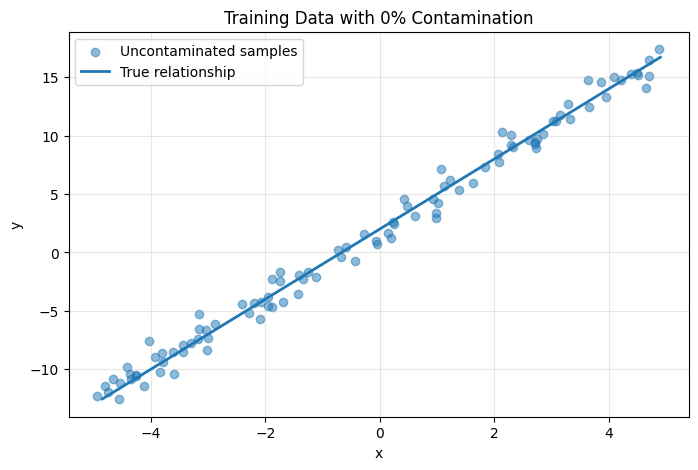

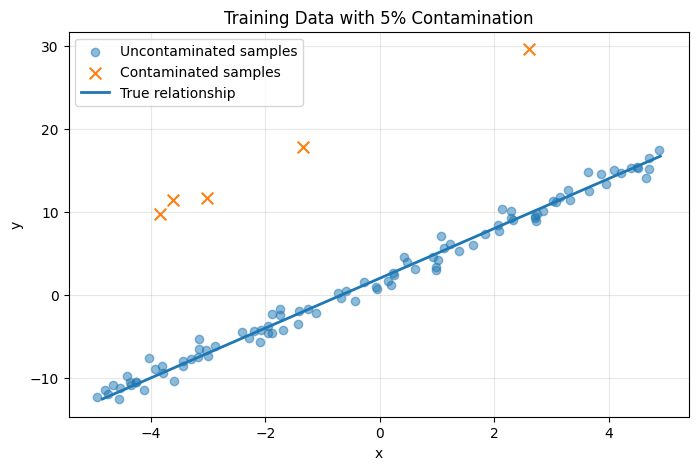

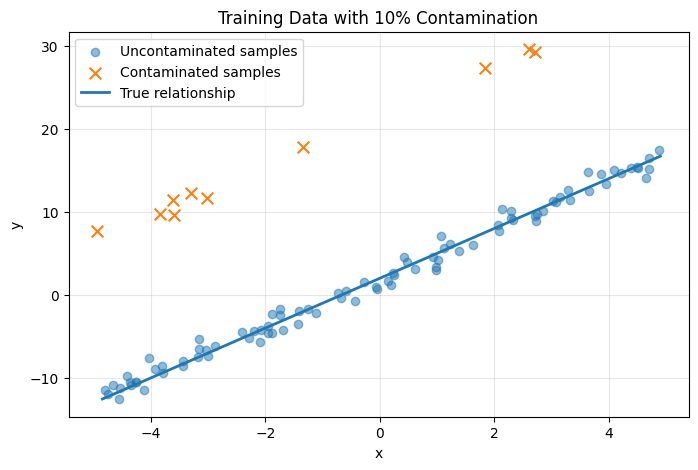

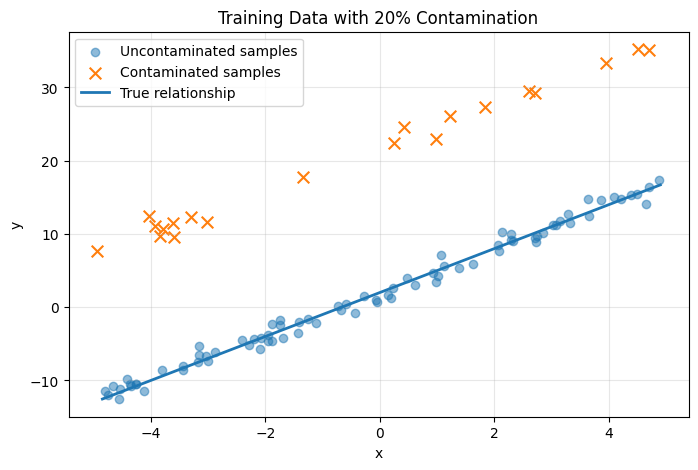

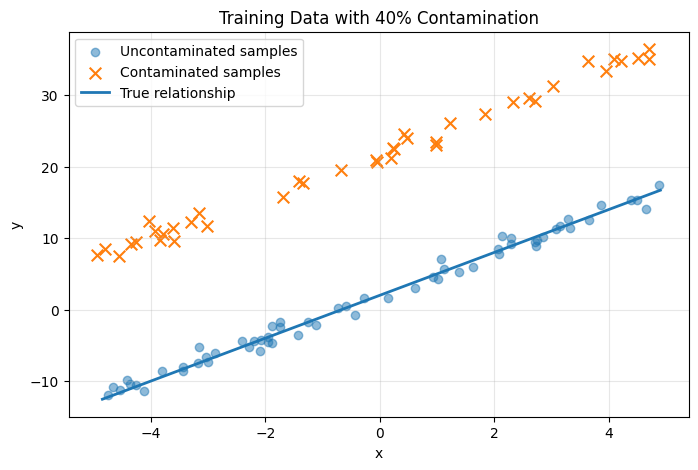

In [77]:
for proportion in CONTAMINATION_PROPORTIONS:

    x_contaminated, y_contaminated, indices = (
        create_proportion_contamination(
            x_train,
            y_train,
            proportion,
            OUTLIER_MAGNITUDE_EXP3,
            EXP3_INDEX_ORDER
        )
    )

    plt.figure(figsize=(8, 5))

    # Clean / unchanged training samples
    clean_mask = np.ones(
        len(x_train),
        dtype=bool
    )
    clean_mask[indices] = False

    plt.scatter(
        x_contaminated[clean_mask],
        y_contaminated[clean_mask],
        alpha=0.5,
        label="Uncontaminated samples"
    )

    # Contaminated samples
    if len(indices) > 0:
        plt.scatter(
            x_contaminated[indices],
            y_contaminated[indices],
            marker="x",
            s=70,
            label="Contaminated samples"
        )

    # Ground-truth relationship
    plt.plot(
        x_line,
        y_true_line,
        linewidth=2,
        label="True relationship"
    )

    plt.xlabel("x")
    plt.ylabel("y")

    plt.title(
        f"Training Data with "
        f"{proportion:.0%} Contamination"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

## **Part 2: Residual, Loss and Batch Gradient Influence**

Because each outlier's magnitude is fixed, the key change is the frequency of large residuals. Even bounded MAE and Huber contributions can accumulate when more observations point in the same direction.

$$
\boxed{\text{Large-residual samples become more frequent}}
$$

$$
\text{Contamination Proportion}
\rightarrow
\text{Residual Distribution}
\rightarrow
\text{Loss}
\rightarrow
\text{Batch Gradient}
$$


### Fixed Reference Model

The same fixed reference model is used at every contamination level. Losses and batch gradients therefore change because of the data intervention rather than parameter adaptation.

$$ \text{Outlier Proportion}\rightarrow\text{Optimization Signal} $$


In [78]:
# Experiment 3: fix the reference model
# Compare losses and batch gradients across contamination levels

experiment3_influence_results = []

for proportion in CONTAMINATION_PROPORTIONS:

    # Create data for this contamination level
    x_contaminated, y_contaminated, indices = (
        create_proportion_contamination(
            x_train,
            y_train,
            proportion,
            OUTLIER_MAGNITUDE_EXP3,
            EXP3_INDEX_ORDER
        )
    )

    # Reuse the fixed reference model from Experiment 2
    y_pred_reference = predict(
        x_contaminated,
        REFERENCE_W,
        REFERENCE_B
    )

    # Residuals for the full training set
    r = residuals(
        y_contaminated,
        y_pred_reference
    )

    # Three batch losses
    mse_loss_value = mse_loss(
        y_contaminated,
        y_pred_reference
    )

    mae_loss_value = mae_loss(
        y_contaminated,
        y_pred_reference
    )

    huber_loss_value = huber_loss(
        y_contaminated,
        y_pred_reference,
        delta=HUBER_DELTA
    )

    # Three batch gradients
    mse_dw, mse_db = mse_gradients(
        x_contaminated,
        y_contaminated,
        y_pred_reference
    )

    mae_dw, mae_db = mae_gradients(
        x_contaminated,
        y_contaminated,
        y_pred_reference
    )

    huber_dw, huber_db = huber_gradients(
        x_contaminated,
        y_contaminated,
        y_pred_reference,
        delta=HUBER_DELTA
    )

    experiment3_influence_results.append({
        "Proportion": proportion,
        "N Contaminated": len(indices),

        "Mean |Residual|": np.mean(np.abs(r)),
        "Max |Residual|": np.max(np.abs(r)),

        "MSE Loss": mse_loss_value,
        "MSE dw": mse_dw,
        "MSE db": mse_db,

        "MAE Loss": mae_loss_value,
        "MAE dw": mae_dw,
        "MAE db": mae_db,

        "Huber Loss": huber_loss_value,
        "Huber dw": huber_dw,
        "Huber db": huber_db
    })

print("Experiment 3 influence analysis completed.")

Experiment 3 influence analysis completed.


### Inspect Residual and Loss Changes

Maximum residual magnitude should remain on roughly the same scale, while the mean absolute residual and batch losses should rise as large residuals become more common.


In [79]:
print("Residual and Loss Summary")
print("-------------------------")

for result in experiment3_influence_results:

    print(
        f"Proportion = {result['Proportion']:.0%} | "
        f"N = {result['N Contaminated']:2d} | "
        f"Mean |r| = {result['Mean |Residual|']:.4f} | "
        f"Max |r| = {result['Max |Residual|']:.4f}"
    )

    print(
        f"    MSE Loss   = {result['MSE Loss']:.4f}"
    )

    print(
        f"    MAE Loss   = {result['MAE Loss']:.4f}"
    )

    print(
        f"    Huber Loss = {result['Huber Loss']:.4f}"
    )

    print()

Residual and Loss Summary
-------------------------
Proportion = 0% | N =  0 | Mean |r| = 0.7010 | Max |r| = 2.2930
    MSE Loss   = 0.8066
    MAE Loss   = 0.7010
    Huber Loss = 0.3549

Proportion = 5% | N =  5 | Mean |r| = 1.6468 | Max |r| = 20.1100
    MSE Loss   = 19.7656
    MAE Loss   = 1.6468
    Huber Loss = 1.2901

Proportion = 10% | N = 10 | Mean |r| = 2.5948 | Max |r| = 20.3093
    MSE Loss   = 38.8642
    MAE Loss   = 2.5948
    Huber Loss = 2.2266

Proportion = 20% | N = 20 | Mean |r| = 4.5234 | Max |r| = 22.2930
    MSE Loss   = 79.3743
    MAE Loss   = 4.5234
    Huber Loss = 4.1411

Proportion = 40% | N = 40 | Mean |r| = 8.3703 | Max |r| = 22.2930
    MSE Loss   = 159.0938
    MAE Loss   = 8.3703
    Huber Loss = 7.9599



The maximum residual remains around 20–22 after contamination begins, while the mean absolute residual rises steadily. MSE loss grows much faster than MAE and Huber because it applies a quadratic penalty, but raw loss values are not comparable across objectives.

$$ 0.7010 \rightarrow1.6468 \rightarrow2.5948 \rightarrow4.5234 \rightarrow8.3703 $$

$$ \boxed{ \text{Outlier magnitude roughly fixed} \quad+\quad \text{Large residuals become more frequent} } $$

$$ 0.8066\rightarrow19.7656\rightarrow38.8642 \rightarrow79.3743\rightarrow159.0938 $$

$$ 0.7010\rightarrow1.6468\rightarrow2.5948 \rightarrow4.5234\rightarrow8.3703 $$

$$ 0.3549\rightarrow1.2901\rightarrow2.2266 \rightarrow4.1141\rightarrow7.9599 $$

| Contamination | Mean \(|r|\) | Max \(|r|\) |

|---:|---:|---:|

| 0% | 0.7010 | 2.2930 |

| 5% | 1.6468 | 20.1100 |

| 10% | 2.5948 | 20.3093 |

| 20% | 4.5234 | 22.2930 |

| 40% | 8.3703 | 22.2930 |


### Inspect Batch Gradient Changes

The batch gradient shows how more similarly directed abnormal contributions change the next parameter update, even though each outlier has fixed magnitude.

$$
w_{t+1}
=
w_t-\eta\frac{\partial L}{\partial w}
$$

$$
b_{t+1}
=
b_t-\eta\frac{\partial L}{\partial b}
$$

$$
\text{More Outliers}
\rightarrow
\text{Accumulated Gradient Influence}
\rightarrow
\text{Parameter Update}
$$


In [80]:
print("Batch Gradient Summary")
print("----------------------")

for result in experiment3_influence_results:

    print(
        f"Proportion = {result['Proportion']:.0%}"
    )

    print(
        f"    MSE   : "
        f"dw = {result['MSE dw']:.4f}, "
        f"db = {result['MSE db']:.4f}"
    )

    print(
        f"    MAE   : "
        f"dw = {result['MAE dw']:.4f}, "
        f"db = {result['MAE db']:.4f}"
    )

    print(
        f"    Huber : "
        f"dw = {result['Huber dw']:.4f}, "
        f"db = {result['Huber db']:.4f}"
    )

    print()

Batch Gradient Summary
----------------------
Proportion = 0%
    MSE   : dw = -0.0004, db = -0.0000
    MAE   : dw = 0.3349, db = -0.0400
    Huber : dw = 0.0002, db = 0.0142

Proportion = 5%
    MSE   : dw = 3.6747, db = -2.0000
    MAE   : dw = 0.4466, db = -0.1200
    Huber : dw = 0.1527, db = -0.0574

Proportion = 10%
    MSE   : dw = 6.5860, db = -4.0000
    MAE   : dw = 0.4273, db = -0.1800
    Huber : dw = 0.2229, db = -0.1223

Proportion = 20%
    MSE   : dw = 4.8575, db = -8.0000
    MAE   : dw = 0.2152, db = -0.3000
    Huber : dw = 0.0699, db = -0.2166

Proportion = 40%
    MSE   : dw = 5.3178, db = -16.0000
    MAE   : dw = 0.3277, db = -0.4600
    Huber : dw = 0.1967, db = -0.4202



MSE intercept influence accumulates almost proportionally with contamination. MAE and Huber accumulate more slowly but are not immune to a growing number of outliers. Slope gradients are non-monotonic because contributions are multiplied by positive and negative input values and can cancel; intercept contributions are not.

$$ -2\rightarrow-4\rightarrow-8\rightarrow-16 $$

$$ 5\%\rightarrow10\%\rightarrow20\%\rightarrow40\% $$

$$ \frac{\partial L_i}{\partial \hat y_i}=2(\hat y_i-y_i) $$

$$ \boxed{ \text{More Outliers} \rightarrow \text{More Large Gradient Contributions} \rightarrow \text{Larger Batch Gradient} } $$

$$ db: -0.12\rightarrow-0.18\rightarrow-0.30\rightarrow-0.46 $$

$$ db: -0.0574\rightarrow-0.1223\rightarrow-0.2166\rightarrow-0.4202 $$

$$ \pm1 $$

$$ \pm\delta $$

$$ g_1+g_2+\cdots+g_k $$

$$ \boxed{ \text{Robustness to outlier magnitude} \neq \text{immunity to increasing contamination proportion} } $$

$$ 3.6747\rightarrow6.5860\rightarrow4.8575\rightarrow5.3178 $$

$$ 0.4466\rightarrow0.4273\rightarrow0.2152\rightarrow0.3277 $$

$$ 0.1527\rightarrow0.2229\rightarrow0.0699\rightarrow0.1967 $$

$$ \frac{\partial L}{\partial w} $$

$$ x_i $$

$$ \frac{\partial L_i}{\partial w} = \frac{\partial L_i}{\partial \hat y_i}x_i $$

$$ \frac{\partial L_i}{\partial b} = \frac{\partial L_i}{\partial \hat y_i} $$

$$ \boxed{ \text{Residual alone does not determine parameter influence} } $$

$$ \frac{\partial L}{\partial w} = \frac{\partial L}{\partial\hat y}x $$


## **Part 3: Model Training under Increasing Contamination**

The models are now trained at each contamination level using identical optimisation settings and the same clean test set. This connects batch-gradient changes to learned parameters, parameter recovery, and generalisation.

$$
\text{Increasing Contamination}
\rightarrow
\text{Gradient Changes}
\rightarrow
\text{Repeated Parameter Updates}
\rightarrow
\text{Learned } w,b
\rightarrow
\text{Clean-Test Performance}
$$

$$
w_{\text{true}}=3,\qquad b_{\text{true}}=2
$$


In [81]:
# Experiment 3: Train three loss models under different contamination proportions

experiment3_training_results = []

# Reuse the loss and gradient functions implemented and verified earlier
loss_configs = [
    ("MSE", mse_loss, mse_gradients, {}),
    ("MAE", mae_loss, mae_gradients, {}),
    ("Huber", huber_loss, huber_gradients, {"delta": HUBER_DELTA})
]

for proportion in CONTAMINATION_PROPORTIONS:

    # Create training data for the current contamination level
    x_contaminated, y_contaminated, indices = (
        create_proportion_contamination(
            x_train,
            y_train,
            proportion,
            OUTLIER_MAGNITUDE_EXP3,
            EXP3_INDEX_ORDER
        )
    )

    # Train all three loss functions using the same data
    # and the same optimization settings
    for loss_name, loss_function, gradient_function, loss_kwargs in loss_configs:

        w_learned, b_learned, history = train_model(
            x_contaminated,
            y_contaminated,
            loss_function=loss_function,
            gradient_function=gradient_function,
            w_init=INITIAL_W,
            b_init=INITIAL_B,
            learning_rate=LEARNING_RATE,
            epochs=EPOCHS,
            **loss_kwargs
        )

        # Evaluate on the same clean test set
        y_test_pred = predict(
            x_test,
            w_learned,
            b_learned
        )

        test_rmse = rmse_metric(
            y_test,
            y_test_pred
        )

        test_mae = mae_metric(
            y_test,
            y_test_pred
        )

        # Parameter recovery error
        w_error = abs(w_learned - W_TRUE)
        b_error = abs(b_learned - B_TRUE)

        experiment3_training_results.append({
            "Proportion": proportion,
            "N Contaminated": len(indices),
            "Loss": loss_name,

            "w": w_learned,
            "b": b_learned,

            "|w - w_true|": w_error,
            "|b - b_true|": b_error,

            "Clean Test RMSE": test_rmse,
            "Clean Test MAE": test_mae,

            "History": history
        })

print("Experiment 3 model training completed.")

Experiment 3 model training completed.


### Inspect Learned Parameters and Clean-Test Performance

The comparison uses learned parameters, their errors relative to the known ground truth, and common clean-test RMSE and MAE. Raw training-loss magnitudes are not used across objectives.

$$
w_{\text{true}}=3,\qquad b_{\text{true}}=2
$$

$$
\boxed{
\text{Increasing Contamination}
\rightarrow
\text{Parameter Recovery}
\rightarrow
\text{Clean-Test Generalisation}
}
$$


In [82]:
# Summarise Experiment 3 training results

print("Experiment 3 Training Summary")
print("-----------------------------")

for result in experiment3_training_results:

    print(
        f"Proportion = {result['Proportion']:.0%} | "
        f"Loss = {result['Loss']}"
    )

    print(
        f"    Learned parameters : "
        f"w = {result['w']:.4f}, "
        f"b = {result['b']:.4f}"
    )

    print(
        f"    Parameter errors   : "
        f"|w - w_true| = {result['|w - w_true|']:.4f}, "
        f"|b - b_true| = {result['|b - b_true|']:.4f}"
    )

    print(
        f"    Clean test metrics : "
        f"RMSE = {result['Clean Test RMSE']:.4f}, "
        f"MAE = {result['Clean Test MAE']:.4f}"
    )

    print()

Experiment 3 Training Summary
-----------------------------
Proportion = 0% | Loss = MSE
    Learned parameters : w = 2.9540, b = 1.9852
    Parameter errors   : |w - w_true| = 0.0460, |b - b_true| = 0.0148
    Clean test metrics : RMSE = 0.9171, MAE = 0.7273

Proportion = 0% | Loss = MAE
    Learned parameters : w = 2.9296, b = 1.9428
    Parameter errors   : |w - w_true| = 0.0704, |b - b_true| = 0.0572
    Clean test metrics : RMSE = 0.9390, MAE = 0.7444

Proportion = 0% | Loss = Huber
    Learned parameters : w = 2.9532, b = 1.9616
    Parameter errors   : |w - w_true| = 0.0468, |b - b_true| = 0.0384
    Clean test metrics : RMSE = 0.9189, MAE = 0.7288

Proportion = 5% | Loss = MSE
    Learned parameters : w = 2.7783, b = 2.9328
    Parameter errors   : |w - w_true| = 0.2217, |b - b_true| = 0.9328
    Clean test metrics : RMSE = 1.4287, MAE = 1.1339

Proportion = 5% | Loss = MAE
    Learned parameters : w = 2.9328, b = 2.0064
    Parameter errors   : |w - w_true| = 0.0672, |b - b_tr

MSE deteriorates sharply as positive vertical contamination pulls its intercept upward. MAE and Huber remain much more stable, although both worsen at 40%. MSE is slightly better on clean data, illustrating the efficiency–robustness trade-off rather than a universal winner.

$$ w=2.9540,\quad b=1.9852,\quad RMSE=0.9171 $$

$$ 1.9852\rightarrow2.9328\rightarrow3.8934\rightarrow5.9431\rightarrow9.9759 $$

$$ 0.9171\rightarrow1.4287\rightarrow2.2718\rightarrow4.0266\rightarrow7.9975 $$

$$ w=2.9633,\quad b=2.7022 $$

$$ RMSE=1.1362,\quad MAE=0.9040 $$

$$ w=2.9398,\quad b=2.9235 $$

$$ RMSE=1.2878,\quad MAE=1.0381 $$

$$ RMSE_{\text{MSE}}=0.9171 < RMSE_{\text{Huber}}=0.9189 < RMSE_{\text{MAE}}=0.9390 $$


### Clean-Test Performance under Increasing Contamination

Plotting clean-test RMSE and MAE against contamination makes the robustness trend directly comparable: gradual error growth indicates stability, whereas steep growth indicates sensitivity.


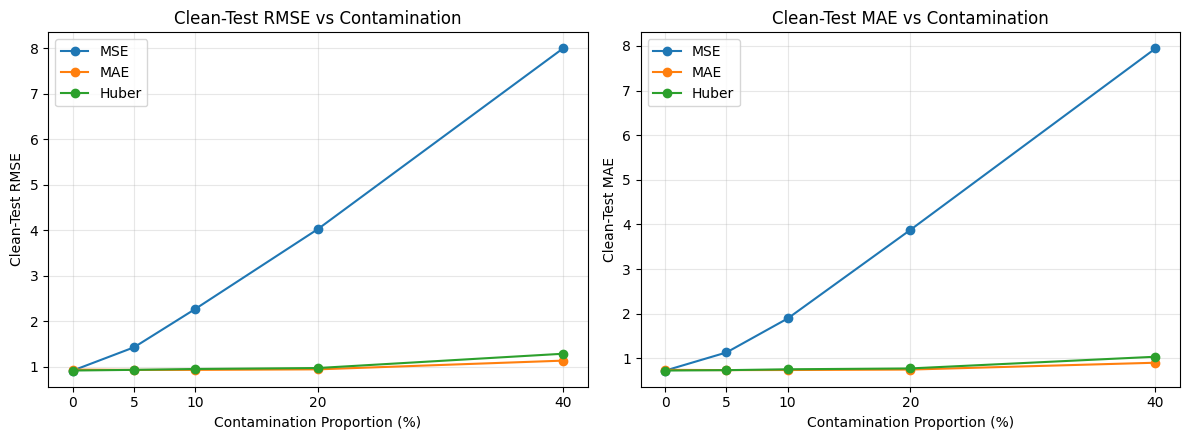

In [83]:
# Visualise clean-test performance under increasing contamination

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

loss_names = ["MSE", "MAE", "Huber"]

for loss_name in loss_names:

    loss_results = [
        result
        for result in experiment3_training_results
        if result["Loss"] == loss_name
    ]

    proportions = [
        result["Proportion"] * 100
        for result in loss_results
    ]

    rmse_values = [
        result["Clean Test RMSE"]
        for result in loss_results
    ]

    mae_values = [
        result["Clean Test MAE"]
        for result in loss_results
    ]

    axes[0].plot(
        proportions,
        rmse_values,
        marker="o",
        label=loss_name
    )

    axes[1].plot(
        proportions,
        mae_values,
        marker="o",
        label=loss_name
    )


# RMSE plot
axes[0].set_title("Clean-Test RMSE vs Contamination")
axes[0].set_xlabel("Contamination Proportion (%)")
axes[0].set_ylabel("Clean-Test RMSE")
axes[0].set_xticks([0, 5, 10, 20, 40])
axes[0].grid(alpha=0.3)
axes[0].legend()


# MAE plot
axes[1].set_title("Clean-Test MAE vs Contamination")
axes[1].set_xlabel("Contamination Proportion (%)")
axes[1].set_ylabel("Clean-Test MAE")
axes[1].set_xticks([0, 5, 10, 20, 40])
axes[1].grid(alpha=0.3)
axes[1].legend()


plt.tight_layout()
plt.show()

MSE clean-test error rises steeply, while MAE and Huber are nearly flat through moderate contamination and increase more clearly only at 40%. MAE is slightly lower than Huber at the highest level in this run.


### Parameter Recovery under Increasing Contamination

Parameter-recovery plots show whether prediction deterioration corresponds to systematic displacement from the known generating slope and intercept.

$$
w_{\text{true}}=3,\qquad b_{\text{true}}=2
$$

$$
|w-w_{\text{true}}|
$$

$$
|b-b_{\text{true}}|
$$


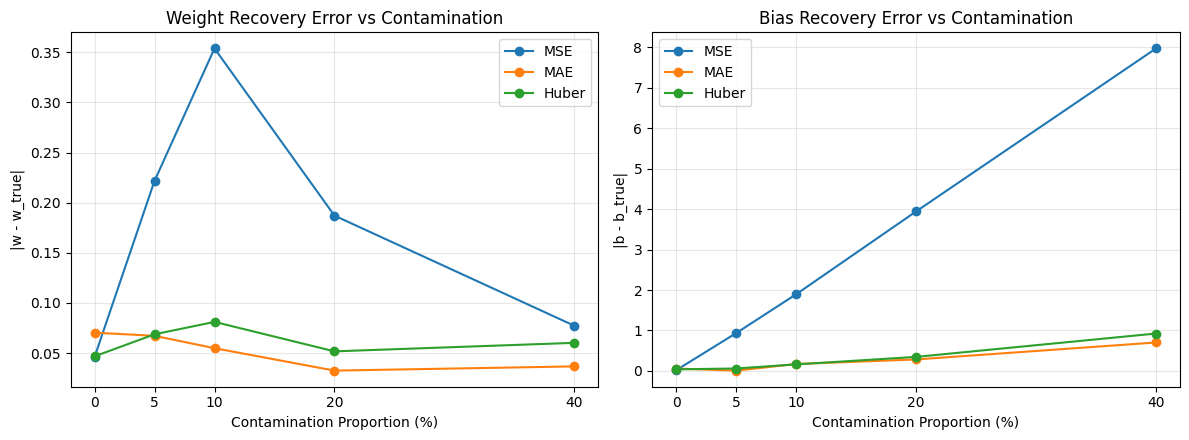

In [84]:
# Visualise parameter recovery under increasing contamination

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

loss_names = ["MSE", "MAE", "Huber"]

for loss_name in loss_names:

    loss_results = [
        result
        for result in experiment3_training_results
        if result["Loss"] == loss_name
    ]

    proportions = [
        result["Proportion"] * 100
        for result in loss_results
    ]

    w_errors = [
        result["|w - w_true|"]
        for result in loss_results
    ]

    b_errors = [
        result["|b - b_true|"]
        for result in loss_results
    ]

    axes[0].plot(
        proportions,
        w_errors,
        marker="o",
        label=loss_name
    )

    axes[1].plot(
        proportions,
        b_errors,
        marker="o",
        label=loss_name
    )


# Weight error
axes[0].set_title("Weight Recovery Error vs Contamination")
axes[0].set_xlabel("Contamination Proportion (%)")
axes[0].set_ylabel("|w - w_true|")
axes[0].set_xticks([0, 5, 10, 20, 40])
axes[0].grid(alpha=0.3)
axes[0].legend()


# Bias error
axes[1].set_title("Bias Recovery Error vs Contamination")
axes[1].set_xlabel("Contamination Proportion (%)")
axes[1].set_ylabel("|b - b_true|")
axes[1].set_xticks([0, 5, 10, 20, 40])
axes[1].grid(alpha=0.3)
axes[1].legend()


plt.tight_layout()
plt.show()

MSE intercept error rises strongly and nearly monotonically because all contaminated targets move upward. Its slope error is non-monotonic because the selected inputs change with proportion. A near-correct slope at 40% is therefore misleading when the intercept and clean-test error are severely distorted.

$$ |b-b_{\text{true}}| $$

$$ 0.0460 \rightarrow0.2217 \rightarrow0.3538 \rightarrow0.1871 \rightarrow0.0772 $$

$$ w=2.9228 $$

$$ w_{\text{true}}=3 $$

$$ b=9.9759 $$

$$ b_{\text{true}}=2 $$

$$ 7.9975 $$


## **Implementation Log — 15/09/2026**

**Development stage:** Experiment 3 — Outlier Proportion

The vertical shift was fixed at 20, and nested contamination sets were generated from a fixed random index order. The fixed reference model showed how more abnormal observations accumulated in the batch gradient before retraining. A `train_model()` argument-name error was corrected by using the existing `w_init` and `b_init` interface and passing the threshold only to Huber.

**Use of AI tools:** ChatGPT helped review the design, debug the interface error, and interpret the non-monotonic MSE slope error. All suggestions were checked against sample counts, residuals, gradients, parameters, and clean-test curves.

**Learning:** Bounded per-sample gradients do not make a model immune to increasing contamination frequency. Robustness must also be assessed jointly through slope, intercept, and predictive performance.


# **Experiment 4: Outlier Type**

## **Part 1: Controlled Vertical vs High-Leverage Setup**

Experiment 4 compares one vertical outlier with one relationship-consistent high-leverage point. Vertical influence acts mainly through the residual, while high leverage also multiplies the slope gradient through the input value.

$$
\frac{\partial L_i}{\partial w}
=
\frac{\partial L_i}{\partial \hat y_i}x_i
$$


### Experiment 4 Configuration

The vertical condition shifts one target upward by 20 at its original input. The high-leverage condition moves the same sample to input 10 and regenerates its target from the ground-truth line while retaining its original noise, isolating leverage from a large vertical inconsistency.

$$
x_i' = x_i,
\qquad
y_i' = y_i + 20
$$

$$
y_i' = w_{\text{true}}x_i' + b_{\text{true}} + \epsilon_i
$$


In [85]:
# Experiment 4: fix the count and vary outlier type

# Reuse the sample selected in Experiment 2
OUTLIER_INDEX_EXP4 = OUTLIER_INDEX

# Reuse the vertical magnitude from Experiment 2
VERTICAL_MAGNITUDE_EXP4 = 20.0

# Clean inputs lie in [-5, 5]
# Move the leverage point outside the training range
HIGH_LEVERAGE_X_EXP4 = 10.0

print("Experiment 4 Configuration")
print("--------------------------")
print("Outlier index:", OUTLIER_INDEX_EXP4)
print("Original x:", x_train[OUTLIER_INDEX_EXP4])
print("Original y:", y_train[OUTLIER_INDEX_EXP4])
print("Vertical-outlier magnitude:", VERTICAL_MAGNITUDE_EXP4)
print("High-leverage x:", HIGH_LEVERAGE_X_EXP4)
print(
    "Normal training x range:",
    f"[{np.min(x_train):.4f}, {np.max(x_train):.4f}]"
)

Experiment 4 Configuration
--------------------------
Outlier index: 74
Original x: 2.0685734384761716
Original y: 8.456213165774392
Vertical-outlier magnitude: 20.0
High-leverage x: 10.0
Normal training x range: [-4.9448, 4.8689]


Both conditions use the same sample index. The vertical shift and leverage input are fixed, so the main difference is outlier type.


### Create High-Leverage Point

The high-leverage helper preserves the selected observation's original noise, changes its input, and recomputes its target from the known relationship. The vertical helper from Experiment 2 is reused unchanged.

$$
\epsilon_i
=
y_i-(w_{\text{true}}x_i+b_{\text{true}})
$$


In [86]:
def create_high_leverage_point(
    x,
    y,
    outlier_index,
    new_x,
    w_true=W_TRUE,
    b_true=B_TRUE
):
    """
    Create a controlled high-leverage point
    while preserving the sample's original noise.
    """

    # Copy the arrays to preserve the clean training data
    x_modified = x.copy()
    y_modified = y.copy()

    # Recover the sample's original noise term
    original_noise = (
        y[outlier_index]
        - (w_true * x[outlier_index] + b_true)
    )

    # Move the input outside the training range
    x_modified[outlier_index] = new_x

    # Recompute the target from the true relationship
    # Preserve the original noise term
    y_modified[outlier_index] = (
        w_true * new_x
        + b_true
        + original_noise
    )

    return x_modified, y_modified

### Generate and Verify the Two Outlier Conditions

Sanity checks verify the shared index, the exact vertical target shift, the out-of-range leverage input with preserved noise, and unchanged remaining observations.


In [87]:
# Create the vertical-outlier condition
# Reuse the verified Experiment 2 helper
x_vertical_exp4, y_vertical_exp4 = create_vertical_outlier(
    x_train,
    y_train,
    OUTLIER_INDEX_EXP4,
    VERTICAL_MAGNITUDE_EXP4
)

# Create the high-leverage condition
x_leverage_exp4, y_leverage_exp4 = create_high_leverage_point(
    x_train,
    y_train,
    OUTLIER_INDEX_EXP4,
    HIGH_LEVERAGE_X_EXP4
)

print("Experiment 4 Sanity Check")
print("-------------------------")

print("\nClean sample")
print("x =", x_train[OUTLIER_INDEX_EXP4])
print("y =", y_train[OUTLIER_INDEX_EXP4])

print("\nVertical outlier")
print("x =", x_vertical_exp4[OUTLIER_INDEX_EXP4])
print("y =", y_vertical_exp4[OUTLIER_INDEX_EXP4])
print(
    "y shift =",
    y_vertical_exp4[OUTLIER_INDEX_EXP4]
    - y_train[OUTLIER_INDEX_EXP4]
)

print("\nHigh-leverage point")
print("x =", x_leverage_exp4[OUTLIER_INDEX_EXP4])
print("y =", y_leverage_exp4[OUTLIER_INDEX_EXP4])

# Verify that only the selected sample changed
print(
    "\nOther x samples unchanged:",
    np.allclose(
        np.delete(x_leverage_exp4, OUTLIER_INDEX_EXP4),
        np.delete(x_train, OUTLIER_INDEX_EXP4)
    )
)

print(
    "Other y samples unchanged:",
    np.allclose(
        np.delete(y_leverage_exp4, OUTLIER_INDEX_EXP4),
        np.delete(y_train, OUTLIER_INDEX_EXP4)
    )
)

Experiment 4 Sanity Check
-------------------------

Clean sample
x = 2.0685734384761716
y = 8.456213165774392

Vertical outlier
x = 2.0685734384761716
y = 28.456213165774393
y shift = 20.0

High-leverage point
x = 10.0
y = 32.25049285034588

Other x samples unchanged: True
Other y samples unchanged: True


The vertical point keeps its input and moves upward by exactly 20. The high-leverage point moves to input 10 but remains near the known line; all other observations remain unchanged.

$$ (2.0686,\ 8.4562) $$

$$ (2.0686,\ 28.4562) $$

$$ y_{\text{shift}}=20 $$

$$ (10,\ 32.2505) $$


## **Part 2: Sample-Level Gradient Influence**

A fixed-model sample analysis separates residual-driven prediction gradients from leverage-driven multiplication in the slope gradient.

$$ \frac{\partial L_i}{\partial w} = \frac{\partial L_i}{\partial\hat y_i}x_i $$

$$ \text{Residual} \rightarrow \frac{\partial L_i}{\partial\hat y_i} \rightarrow \frac{\partial L_i}{\partial w} $$

$$
r_i = \hat y_i-y_i
$$

$$
g_i
=
\frac{\partial L_i}{\partial \hat y_i}
$$

$$
\hat y_i=wx_i+b
$$

$$
\frac{\partial L_i}{\partial w}=g_i x_i
$$

$$
\frac{\partial L_i}{\partial b}=g_i
$$


### Reference Model for Gradient Comparison

The same clean reference parameters are used for the clean, vertical, and high-leverage versions of the sample, preventing learned-parameter differences from confounding the mechanism comparison.

$$
w_{\text{ref}}=2.9540,\qquad b_{\text{ref}}=1.9852
$$


In [88]:
# Reuse the fixed reference model from earlier experiments

print("Reference Model for Experiment 4")
print("--------------------------------")
print(f"w_ref = {REFERENCE_W:.4f}")
print(f"b_ref = {REFERENCE_B:.4f}")

Reference Model for Experiment 4
--------------------------------
w_ref = 2.9540
b_ref = 1.9852


### Compare Sample-Level Gradient Contributions

For each condition, the fixed prediction gives a residual and a loss-specific prediction gradient. The chain rule then gives the raw slope and intercept contributions.

$$
\hat y_i=w_{\text{ref}}x_i+b_{\text{ref}}
$$

$$
r_i=\hat y_i-y_i
$$

$$
g_i=\frac{\partial L_i}{\partial\hat y_i}
$$

$$
\frac{\partial L_i}{\partial w}=g_ix_i,
\qquad
\frac{\partial L_i}{\partial b}=g_i
$$


In [89]:
# Compare sample influence across the three conditions
# Reuse the verified sample losses and prediction gradients

sample_conditions_exp4 = {
    "Clean": (
        x_train[OUTLIER_INDEX_EXP4],
        y_train[OUTLIER_INDEX_EXP4]
    ),
    "Vertical": (
        x_vertical_exp4[OUTLIER_INDEX_EXP4],
        y_vertical_exp4[OUTLIER_INDEX_EXP4]
    ),
    "High-Leverage": (
        x_leverage_exp4[OUTLIER_INDEX_EXP4],
        y_leverage_exp4[OUTLIER_INDEX_EXP4]
    )
}

experiment4_influence_results = []

for condition_name, (x_i, y_i) in sample_conditions_exp4.items():

    # Predict with the fixed reference model
    y_hat_i = predict(
        np.array([x_i]),
        REFERENCE_W,
        REFERENCE_B
    )[0]

    # Keep the residual convention: prediction minus target
    residual = y_hat_i - y_i

    # MSE
    mse_loss_i = mse_sample_loss(residual)
    mse_dyhat = mse_prediction_gradient(residual)

    # MAE
    mae_loss_i = mae_sample_loss(residual)
    mae_dyhat = mae_prediction_gradient(residual)

    # Huber
    huber_loss_i = huber_sample_loss(
        residual,
        HUBER_DELTA
    )
    huber_dyhat = huber_prediction_gradient(
        residual,
        HUBER_DELTA
    )

    # Apply the chain rule for raw parameter contributions
    experiment4_influence_results.append({
        "Condition": condition_name,
        "x": x_i,
        "y": y_i,
        "Prediction": y_hat_i,
        "Residual": residual,

        "MSE dL/dy_hat": mse_dyhat,
        "MSE dL/dw": mse_dyhat * x_i,
        "MSE dL/db": mse_dyhat,

        "MAE dL/dy_hat": mae_dyhat,
        "MAE dL/dw": mae_dyhat * x_i,
        "MAE dL/db": mae_dyhat,

        "Huber dL/dy_hat": huber_dyhat,
        "Huber dL/dw": huber_dyhat * x_i,
        "Huber dL/db": huber_dyhat
    })

print("Experiment 4 sample-level influence analysis completed.")

Experiment 4 sample-level influence analysis completed.


In [90]:
print("Experiment 4: Sample-Level Gradient Comparison")
print("----------------------------------------------")

print(
    f"{'Condition':>14} "
    f"{'x':>9} "
    f"{'Residual':>10} "
    f"{'MSE dL/dy':>12} "
    f"{'MSE dL/dw':>12} "
    f"{'MAE dL/dy':>12} "
    f"{'MAE dL/dw':>12} "
    f"{'Huber dL/dy':>14} "
    f"{'Huber dL/dw':>14}"
)

print("-" * 119)

for row in experiment4_influence_results:
    print(
        f"{row['Condition']:>14} "
        f"{row['x']:9.4f} "
        f"{row['Residual']:10.4f} "
        f"{row['MSE dL/dy_hat']:12.4f} "
        f"{row['MSE dL/dw']:12.4f} "
        f"{row['MAE dL/dy_hat']:12.4f} "
        f"{row['MAE dL/dw']:12.4f} "
        f"{row['Huber dL/dy_hat']:14.4f} "
        f"{row['Huber dL/dw']:14.4f}"
    )

Experiment 4: Sample-Level Gradient Comparison
----------------------------------------------
     Condition         x   Residual    MSE dL/dy    MSE dL/dw    MAE dL/dy    MAE dL/dw    Huber dL/dy    Huber dL/dw
-----------------------------------------------------------------------------------------------------------------------
         Clean    2.0686    -0.3604      -0.7209      -1.4912      -1.0000      -2.0686        -0.3604        -0.7456
      Vertical    2.0686   -20.3604     -40.7209     -84.2342      -1.0000      -2.0686        -1.0000        -2.0686
 High-Leverage   10.0000    -0.7253      -1.4506     -14.5059      -1.0000     -10.0000        -0.7253        -7.2529


The vertical outlier creates a very large residual, producing a large MSE gradient while MAE and Huber remain bounded. The high-leverage point has a modest residual but a large input, so all slope contributions are amplified. Bounded prediction gradients therefore do not guarantee bounded slope influence.

$$ r=-0.3604 $$

$$ x=2.0686\quad\text{unchanged} $$

$$ r=-20.3604 $$

$$ -0.7209\rightarrow -40.7209 $$

$$ \boxed{-84.2342} $$

$$ \text{large vertical residual} \rightarrow \text{large MSE prediction gradient} \rightarrow \text{very large slope influence} $$

$$ \text{MAE }dL/d\hat y=-1 $$

$$ \text{Huber }dL/d\hat y=-1 $$

$$ -1\times2.0686=-2.0686 $$

$$ r=-0.7253 $$

$$ x=10 $$

$$ dL/d\hat y=-1 $$

$$ \frac{\partial L}{\partial w} =(-1)(10) = \boxed{-10} $$

$$ -2.0686 $$

$$ -0.7253\times10 = \boxed{-7.2529} $$

$$ -1.4506\times10 = \boxed{-14.5059} $$

$$ \boxed{ \text{bounded prediction gradient} \neq \text{bounded slope influence} } $$

$$ \frac{\partial L_i}{\partial w} = \underbrace{\frac{\partial L_i}{\partial\hat y_i}}_{\text{loss controls this}} \underbrace{x_i}_{\text{leverage can amplify this}} $$


## **Part 3: Model Training under Different Outlier Types**

MSE, MAE, and Huber are trained under clean, vertical, and high-leverage conditions using the same optimisation settings. Final parameters and recovery errors show whether the local gradient differences accumulate into model changes.

$$
|\hat w-w_{\text{true}}|
$$

$$
|\hat b-b_{\text{true}}|
$$


In [91]:
# Experiment 4 training conditions
training_conditions_exp4 = {
    "Clean": (x_train, y_train),
    "Vertical": (x_vertical_exp4, y_vertical_exp4),
    "High-Leverage": (x_leverage_exp4, y_leverage_exp4)
}

experiment4_training_results = {}

for condition_name, (x_condition, y_condition) in training_conditions_exp4.items():

    experiment4_training_results[condition_name] = {}

    # Train with MSE
    w_mse_exp4, b_mse_exp4, history_mse_exp4 = train_model(
        x_condition,
        y_condition,
        loss_function=mse_loss,
        gradient_function=mse_gradients,
        w_init=INITIAL_W,
        b_init=INITIAL_B,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS
    )

    # Train with MAE
    w_mae_exp4, b_mae_exp4, history_mae_exp4 = train_model(
        x_condition,
        y_condition,
        loss_function=mae_loss,
        gradient_function=mae_gradients,
        w_init=INITIAL_W,
        b_init=INITIAL_B,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS
    )

    # Train with Huber
    w_huber_exp4, b_huber_exp4, history_huber_exp4 = train_model(
        x_condition,
        y_condition,
        loss_function=huber_loss,
        gradient_function=huber_gradients,
        w_init=INITIAL_W,
        b_init=INITIAL_B,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS,
        delta=HUBER_DELTA
    )

    # Store all results for this condition
    experiment4_training_results[condition_name]["MSE"] = {
        "w": w_mse_exp4,
        "b": b_mse_exp4,
        "history": history_mse_exp4
    }

    experiment4_training_results[condition_name]["MAE"] = {
        "w": w_mae_exp4,
        "b": b_mae_exp4,
        "history": history_mae_exp4
    }

    experiment4_training_results[condition_name]["Huber"] = {
        "w": w_huber_exp4,
        "b": b_huber_exp4,
        "history": history_huber_exp4
    }

print("Experiment 4 model training completed.")

Experiment 4 model training completed.


### Parameter Recovery Comparison

The known generating parameters allow direct comparison of slope and intercept recovery. The aim is to connect each outlier mechanism to the final estimates rather than simply declare one loss best.

$$
w_{\text{true}}=3,\qquad b_{\text{true}}=2
$$

$$
|\hat w-w_{\text{true}}|
$$

$$
|\hat b-b_{\text{true}}|
$$


In [92]:
print("Experiment 4: Learned Parameters and Parameter Recovery")
print("-------------------------------------------------------")

print(
    f"{'Condition':>14} "
    f"{'Loss':>8} "
    f"{'w':>10} "
    f"{'b':>10} "
    f"{'|w-w_true|':>14} "
    f"{'|b-b_true|':>14}"
)

print("-" * 74)

for condition_name in ["Clean", "Vertical", "High-Leverage"]:

    for loss_name in ["MSE", "MAE", "Huber"]:

        result = experiment4_training_results[condition_name][loss_name]

        w_hat = result["w"]
        b_hat = result["b"]

        w_error = abs(w_hat - W_TRUE)
        b_error = abs(b_hat - B_TRUE)

        print(
            f"{condition_name:>14} "
            f"{loss_name:>8} "
            f"{w_hat:10.4f} "
            f"{b_hat:10.4f} "
            f"{w_error:14.4f} "
            f"{b_error:14.4f}"
        )

Experiment 4: Learned Parameters and Parameter Recovery
-------------------------------------------------------
     Condition     Loss          w          b     |w-w_true|     |b-b_true|
--------------------------------------------------------------------------
         Clean      MSE     2.9540     1.9852         0.0460         0.0148
         Clean      MAE     2.9296     1.9428         0.0704         0.0572
         Clean    Huber     2.9532     1.9616         0.0468         0.0384
      Vertical      MSE     3.0080     2.2013         0.0080         0.2013
      Vertical      MAE     2.9296     1.9428         0.0704         0.0572
      Vertical    Huber     2.9555     1.9707         0.0445         0.0293
 High-Leverage      MSE     2.9608     1.9903         0.0392         0.0097
 High-Leverage      MAE     2.9368     1.9814         0.0632         0.0186
 High-Leverage    Huber     2.9622     1.9685         0.0378         0.0315


All losses recover the clean relationship. The vertical point mainly shifts the MSE intercept, while MAE is unchanged and Huber moves only slightly. The relationship-consistent high-leverage point changes slopes modestly but does not seriously harm recovery; strong influence need not be harmful when the observation follows the underlying trend.

$$ w_{\text{true}}=3,\qquad b_{\text{true}}=2 $$

$$ (2.9540,\ 1.9852) $$

$$ (3.0080,\ 2.2013) $$

$$ |w-3|=0.0080 $$

$$ |b-2|:0.0148\rightarrow0.2013 $$

$$ (2.9296,1.9428)\rightarrow(2.9296,1.9428) $$

$$ (2.9532,1.9616)\rightarrow(2.9555,1.9707) $$

$$ \text{MSE}: 2.9540\rightarrow2.9608 $$

$$ \text{MAE}:2.9296\rightarrow2.9368 $$

$$ \text{Huber}:2.9532\rightarrow2.9622 $$

$$ (10,\ 32.2505) $$

$$ \text{MSE }|w-3|:0.0460\rightarrow0.0392 $$

$$ \text{Huber }|w-3|:0.0468\rightarrow0.0378 $$

$$ \boxed{ \text{Vertical outlier} \rightarrow \text{large residual} \rightarrow \text{loss-dependent gradient response} } $$

$$ \boxed{ \text{High leverage} \rightarrow \text{large }|x| \rightarrow \text{slope-gradient amplification} } $$

$$ \boxed{ \text{large gradient influence} \neq \text{necessarily harmful influence} } $$

| Loss | \(w\) | \(b\) | \(|w-3|\) | \(|b-2|\) |

|---|---:|---:|---:|---:|

| MSE | 2.9540 | 1.9852 | 0.0460 | 0.0148 |

| MAE | 2.9296 | 1.9428 | 0.0704 | 0.0572 |

| Huber | 2.9532 | 1.9616 | 0.0468 | 0.0384 |


## **Part 4: Clean-Test Performance and Fitted-Line Analysis**

All trained models are evaluated on the same clean test set with RMSE and MAE, then compared through fitted lines against the ground truth.

$$
RMSE
$$

$$
MAE
$$


In [93]:
# Evaluate all models on the same clean test set

experiment4_test_results = {}

for condition_name in ["Clean", "Vertical", "High-Leverage"]:

    experiment4_test_results[condition_name] = {}

    for loss_name in ["MSE", "MAE", "Huber"]:

        result = experiment4_training_results[condition_name][loss_name]

        w_hat = result["w"]
        b_hat = result["b"]

        # Predict on the clean test set
        y_test_pred = predict(x_test, w_hat, b_hat)

        # Reuse the common evaluation metrics
        test_rmse = rmse_metric(y_test, y_test_pred)
        test_mae = mae_metric(y_test, y_test_pred)

        experiment4_test_results[condition_name][loss_name] = {
            "RMSE": test_rmse,
            "MAE": test_mae
        }

print("Experiment 4 clean-test evaluation completed.")

Experiment 4 clean-test evaluation completed.


In [94]:
print("Experiment 4: Clean-Test Performance")
print("------------------------------------")

print(
    f"{'Condition':>14} "
    f"{'Loss':>8} "
    f"{'RMSE':>10} "
    f"{'MAE':>10}"
)

print("-" * 46)

for condition_name in ["Clean", "Vertical", "High-Leverage"]:

    for loss_name in ["MSE", "MAE", "Huber"]:

        result = experiment4_test_results[condition_name][loss_name]

        print(
            f"{condition_name:>14} "
            f"{loss_name:>8} "
            f"{result['RMSE']:10.4f} "
            f"{result['MAE']:10.4f}"
        )

Experiment 4: Clean-Test Performance
------------------------------------
     Condition     Loss       RMSE        MAE
----------------------------------------------
         Clean      MSE     0.9171     0.7273
         Clean      MAE     0.9390     0.7444
         Clean    Huber     0.9189     0.7288
      Vertical      MSE     0.9136     0.7219
      Vertical      MAE     0.9390     0.7444
      Vertical    Huber     0.9169     0.7271
 High-Leverage      MSE     0.9125     0.7234
 High-Leverage      MAE     0.9301     0.7377
 High-Leverage    Huber     0.9127     0.7239


All test errors remain in a narrow range. The different outlier types clearly change gradient mechanisms, but one controlled abnormal point does not necessarily cause large generalisation loss.

$$ RMSE:0.9171\rightarrow0.9136 $$

$$ \text{MSE RMSE}=0.9125,\quad \text{MAE RMSE}=0.9301,\quad \text{Huber RMSE}=0.9127 $$

$$ \boxed{\text{Outlier type clearly changes gradient mechanism}} $$

$$ \boxed{\text{different gradient influence does not necessarily cause large test degradation}} $$


### Fitted Regression Lines

For each loss, the plot compares the ground truth with fitted lines from clean, vertical, and high-leverage training conditions.


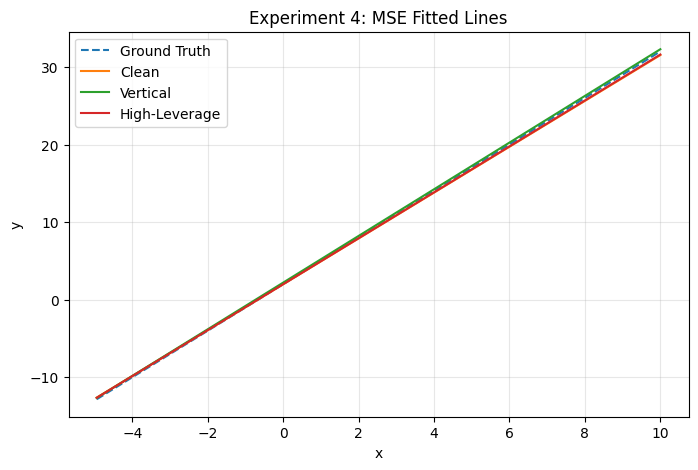

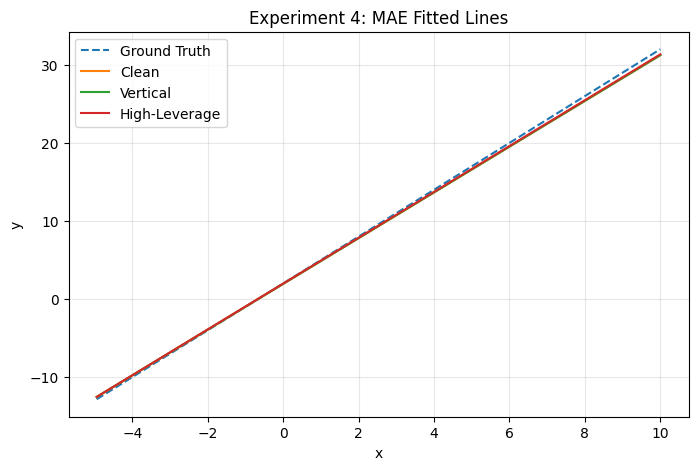

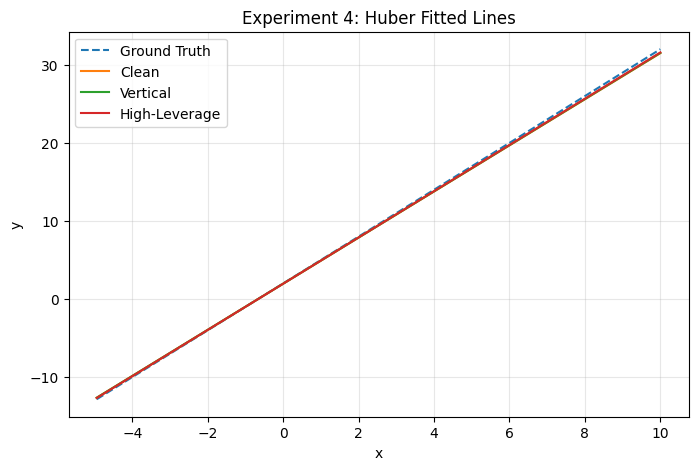

In [95]:
# Use one input range for all fitted lines
x_line_exp4 = np.linspace(
    min(np.min(x_train), np.min(x_leverage_exp4)),
    max(np.max(x_train), np.max(x_leverage_exp4)),
    200
)

for loss_name in ["MSE", "MAE", "Huber"]:

    plt.figure(figsize=(8, 5))

    # Ground-truth relationship
    y_true_line = W_TRUE * x_line_exp4 + B_TRUE
    plt.plot(
        x_line_exp4,
        y_true_line,
        linestyle="--",
        label="Ground Truth"
    )

    # Fitted lines for the three training conditions
    for condition_name in ["Clean", "Vertical", "High-Leverage"]:

        result = experiment4_training_results[condition_name][loss_name]

        y_fitted_line = predict(
            x_line_exp4,
            result["w"],
            result["b"]
        )

        plt.plot(
            x_line_exp4,
            y_fitted_line,
            label=condition_name
        )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Experiment 4: {loss_name} Fitted Lines")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### Fitted-Line Results

The fitted lines remain close overall. MSE shows the clearest upward shift under vertical contamination; MAE's clean and vertical lines overlap; Huber changes only slightly. High leverage causes small slope adjustments without destabilising the fit.


### Deviation from Ground Truth

Because the fitted lines overlap on the full scale, deviation plots show each prediction minus the ground-truth prediction without changing the experiment.

$$
\text{Deviation}(x)
=
\hat y(x)-y_{\text{true}}(x)
$$

$$
y_{\text{true}}(x)=w_{\text{true}}x+b_{\text{true}}
$$


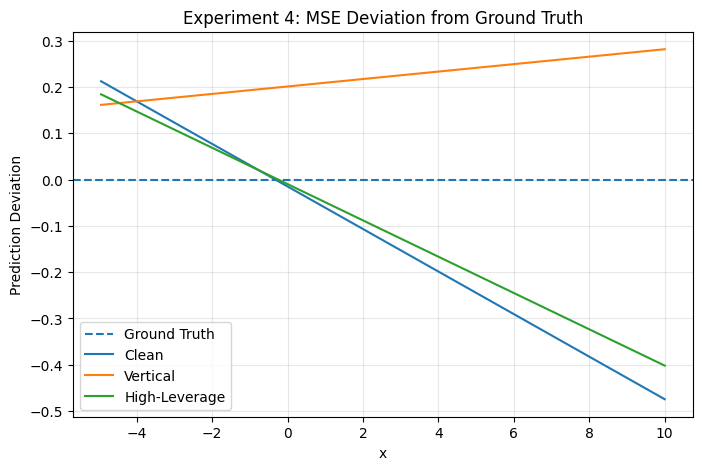

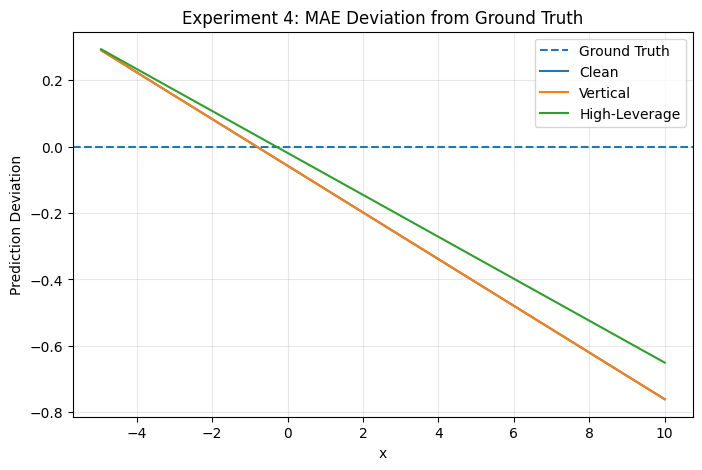

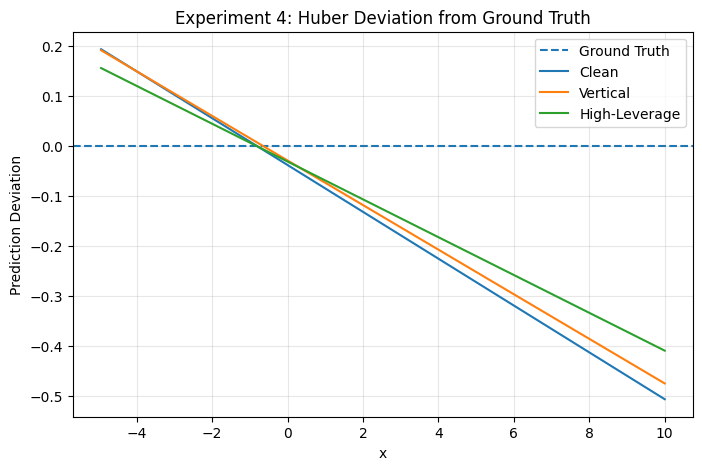

In [96]:
# Plot fitted-line deviation from the ground truth

for loss_name in ["MSE", "MAE", "Huber"]:

    plt.figure(figsize=(8, 5))

    # Ground truth corresponds to zero deviation
    plt.axhline(
        y=0,
        linestyle="--",
        label="Ground Truth"
    )

    for condition_name in ["Clean", "Vertical", "High-Leverage"]:

        result = experiment4_training_results[condition_name][loss_name]

        y_fitted = predict(
            x_line_exp4,
            result["w"],
            result["b"]
        )

        y_true = W_TRUE * x_line_exp4 + B_TRUE

        # Prediction minus ground truth
        deviation = y_fitted - y_true

        plt.plot(
            x_line_exp4,
            deviation,
            label=condition_name
        )

    plt.xlabel("x")
    plt.ylabel("Prediction Deviation")
    plt.title(
        f"Experiment 4: {loss_name} Deviation from Ground Truth"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### Deviation Results

Deviation plots expose the small structural differences. Vertical contamination mostly raises the MSE line, while MAE and Huber remain stable. High leverage produces slope-related changes, but the relationship-consistent point does not degrade clean-test performance and can slightly improve slope recovery.

$$
\frac{\partial L_i}{\partial w}
=
\frac{\partial L_i}{\partial \hat y_i}x_i
$$


## **Implementation Log — 15/09/2026**

**Development stage:** Experiment 4 — Outlier Type

The same observation was used for both conditions. The vertical condition shifted its target by 20; the leverage condition moved its input to 10 while preserving its original noise and consistency with the generating line. Existing reference-model, gradient, trainer, and evaluation functions were reused. Incorrect references to a missing result object and mismatched trainer arguments were corrected without changing the framework.

**Use of AI tools:** ChatGPT helped review the controlled leverage construction, debug interface issues, and interpret the gradient results. The intervention and all conclusions were checked against numerical outputs, parameters, test metrics, fitted lines, and deviation plots.

**Learning:** Robust losses bound residual-driven prediction gradients, but an extreme input can still amplify the slope gradient. Strong influence is not necessarily harmful when the point is consistent with the underlying relationship.

$$
\frac{\partial L_i}{\partial w}
=
\frac{\partial L_i}{\partial \hat y_i}x_i,
$$


# **Experiment 5: Huber Threshold**

Experiment 5 fixes the contaminated dataset and varies only the Huber threshold. Small thresholds make more residuals linear and MAE-like; large thresholds retain more quadratic, MSE-like behaviour.

**Notation and retained values:** $\delta$.

$$
\delta = 1.0
$$

$$
L_\delta(r)=
\begin{cases}
\frac{1}{2}r^2, & |r|\leq\delta \\
\delta\left(|r|-\frac{1}{2}\delta\right), & |r|>\delta
\end{cases}
$$

$$
\delta
\rightarrow
\text{Huber gradient}
\rightarrow
\text{parameter update}
\rightarrow
\text{learned model}
$$


## **Part 1: Controlled Huber-Threshold Setup**

The same magnitude-20 vertical outlier, sample index, training data, initialisation, learning rate, and epoch budget are used for every threshold. Only the threshold changes.

$$
\delta
$$


In [97]:
# Experiment 5: fix the outlier and vary Huber delta

# Reuse the verified Experiment 2 sample
OUTLIER_INDEX_EXP5 = OUTLIER_INDEX

# Reuse the tested vertical magnitude
OUTLIER_MAGNITUDE_EXP5 = 20.0

# Create one fixed contaminated dataset
# Use the same data for every delta
x_exp5, y_exp5 = create_vertical_outlier(
    x_train,
    y_train,
    OUTLIER_INDEX_EXP5,
    OUTLIER_MAGNITUDE_EXP5
)

print("Experiment 5 Fixed Data Condition")
print("---------------------------------")
print("Outlier index:", OUTLIER_INDEX_EXP5)
print("Outlier x:", x_exp5[OUTLIER_INDEX_EXP5])
print("Original y:", y_train[OUTLIER_INDEX_EXP5])
print("Contaminated y:", y_exp5[OUTLIER_INDEX_EXP5])
print("Vertical-outlier magnitude:", OUTLIER_MAGNITUDE_EXP5)

Experiment 5 Fixed Data Condition
---------------------------------
Outlier index: 74
Outlier x: 2.0685734384761716
Original y: 8.456213165774392
Contaminated y: 28.456213165774393
Vertical-outlier magnitude: 20.0


### **Huber Threshold Conditions**

The tested thresholds span small, intermediate, and large values and include the default value used in earlier experiments.

**Notation and retained values:** $\delta$.

$$
\delta = 1.0
$$


In [98]:
# Huber threshold conditions

HUBER_DELTAS_EXP5 = np.array([
    0.25,
    0.5,
    1.0,
    2.0,
    5.0,
    10.0,
    20.0,
    25.0
])

print("Experiment 5 Configuration")
print("--------------------------")
print("Huber deltas:", HUBER_DELTAS_EXP5)
print("Default delta from previous experiments:", HUBER_DELTA)
print("Initial w:", INITIAL_W)
print("Initial b:", INITIAL_B)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)

Experiment 5 Configuration
--------------------------
Huber deltas: [ 0.25  0.5   1.    2.    5.   10.   20.   25.  ]
Default delta from previous experiments: 1.0
Initial w: 0.0
Initial b: 0.0
Learning rate: 0.01
Epochs: 1000


## **Part 2: Gradient Transition across Delta**

Before training, the same outlier and reference prediction are used to isolate how the threshold changes the Huber prediction gradient and its parameter contributions.

**Notation and retained values:** $\delta$.

$$
\delta
\rightarrow
\frac{\partial L}{\partial \hat{y}}
\rightarrow
\frac{\partial L}{\partial w}
\rightarrow
\frac{\partial L}{\partial b}
$$


In [99]:
# Experiment 5 Part 2:
# Fix the reference model and vary only delta

# Reuse the fixed reference model
w_ref_exp5 = REFERENCE_W
b_ref_exp5 = REFERENCE_B

# Select the fixed outlier sample
x_out_exp5 = x_exp5[OUTLIER_INDEX_EXP5]
y_out_exp5 = y_exp5[OUTLIER_INDEX_EXP5]

# Fix the prediction and residual
y_hat_out_exp5 = predict(
    np.array([x_out_exp5]),
    w_ref_exp5,
    b_ref_exp5
)[0]

residual_out_exp5 = y_hat_out_exp5 - y_out_exp5

print("Fixed Outlier at Reference Model")
print("--------------------------------")
print("Reference w:", w_ref_exp5)
print("Reference b:", b_ref_exp5)
print("Outlier x:", x_out_exp5)
print("Outlier y:", y_out_exp5)
print("Prediction:", y_hat_out_exp5)
print("Residual:", residual_out_exp5)
print("|Residual|:", abs(residual_out_exp5))

Fixed Outlier at Reference Model
--------------------------------
Reference w: 2.954
Reference b: 1.9852
Outlier x: 2.0685734384761716
Outlier y: 28.456213165774393
Prediction: 8.095765937258612
Residual: -20.36044722851578
|Residual|: 20.36044722851578


The fixed reference model produces a residual of about -20.36 for the contaminated point. Every threshold therefore faces exactly the same residual.

$$ w=2.954,\qquad b=1.9852 $$

$$ \hat y=8.0958 $$

$$ y=28.4562 $$

$$ r=\hat y-y=-20.3604 $$

$$ |r|=20.3604 $$


### **Sample-Level Gradient Influence**

For each threshold, the sample loss and prediction gradient are converted to slope and intercept contributions using the linear-model chain rule.

**Notation and retained values:** $\delta$.

$$
\frac{\partial L}{\partial \hat{y}}
$$

$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial \hat{y}}x
$$

$$
\frac{\partial L}{\partial b}
=
\frac{\partial L}{\partial \hat{y}}
$$


In [100]:
# Evaluate the same outlier at each delta

gradient_results_exp5 = []

for delta in HUBER_DELTAS_EXP5:
    # Reuse the verified Huber sample functions
    sample_loss = huber_sample_loss(
        residual_out_exp5,
        delta
    )

    dL_dyhat = huber_prediction_gradient(
        residual_out_exp5,
        delta
    )

    # Apply the linear-model chain rule
    dL_dw = dL_dyhat * x_out_exp5
    dL_db = dL_dyhat

    # Identify the active Huber region
    if abs(residual_out_exp5) <= delta:
        region = "Quadratic"
    else:
        region = "Linear"

    gradient_results_exp5.append([
        delta,
        region,
        sample_loss,
        dL_dyhat,
        dL_dw,
        dL_db
    ])

# Use the existing formatted-text table style
print(
    f"{'delta':>8} "
    f"{'region':>12} "
    f"{'sample loss':>15} "
    f"{'dL/dy_hat':>15} "
    f"{'dL/dw':>15} "
    f"{'dL/db':>15}"
)

print("-" * 86)

for row in gradient_results_exp5:
    delta, region, sample_loss, dL_dyhat, dL_dw, dL_db = row

    print(
        f"{delta:8.2f} "
        f"{region:>12} "
        f"{sample_loss:15.6f} "
        f"{dL_dyhat:15.6f} "
        f"{dL_dw:15.6f} "
        f"{dL_db:15.6f}"
    )

   delta       region     sample loss       dL/dy_hat           dL/dw           dL/db
--------------------------------------------------------------------------------------
    0.25       Linear        5.058862       -0.250000       -0.517143       -0.250000
    0.50       Linear       10.055224       -0.500000       -1.034287       -0.500000
    1.00       Linear       19.860447       -1.000000       -2.068573       -1.000000
    2.00       Linear       38.720894       -2.000000       -4.137147       -2.000000
    5.00       Linear       89.302236       -5.000000      -10.342867       -5.000000
   10.00       Linear      153.604472      -10.000000      -20.685734      -10.000000
   20.00       Linear      207.208945      -20.000000      -41.371469      -20.000000
   25.00    Quadratic      207.273906      -20.360447      -42.117080      -20.360447


While the threshold is below the fixed residual magnitude, the sample remains in the linear region and its gradient magnitude equals the threshold. At threshold 25 it enters the quadratic region, where the gradient equals the residual and no longer grows with the threshold.

$$ \delta=0.25 \Rightarrow \frac{\partial L}{\partial\hat y}=-0.25 $$

$$ \delta=1 \Rightarrow \frac{\partial L}{\partial\hat y}=-1 $$

$$ \delta=5 \Rightarrow \frac{\partial L}{\partial\hat y}=-5 $$

$$ \delta=20 \Rightarrow \frac{\partial L}{\partial\hat y}=-20 $$

$$ |r|=20.3604 $$

$$ \delta < |r| $$

$$ \frac{\partial L}{\partial\hat y}=-\delta $$

$$ \boxed{ \delta\uparrow \Rightarrow |\partial L/\partial\hat y|\uparrow } $$

$$ \boxed{ \delta\uparrow \Rightarrow |\partial L/\partial w|\uparrow } $$

$$ -0.5171 $$

$$ -41.3715 $$

$$ \frac{\partial L}{\partial w} = \frac{\partial L}{\partial\hat y}x $$

$$ \delta \rightarrow \text{gradient influence} \rightarrow \text{parameter update} $$

$$ \delta=20 < |r|=20.360447 $$

$$ \frac{\partial L}{\partial\hat y}=-20 $$

$$ \delta=25 > |r|=20.360447 $$

$$ \frac{\partial L}{\partial\hat y}=r=-20.360447 $$

$$ 20\rightarrow20.360447 $$

$$ |r|>\delta \Rightarrow \left|\frac{\partial L}{\partial\hat y}\right|=\delta $$

$$ |r|\leq\delta \Rightarrow \left|\frac{\partial L}{\partial\hat y}\right|=|r| $$

$$ L=\frac12r^2 $$


### **Visualising the Gradient Transition**

The plot shows the linear growth in gradient magnitude below the residual boundary and the saturation at the residual magnitude after the sample enters the quadratic region.

**Notation and retained values:** $\delta$; $\delta < |r|$; $\delta \geq |r|$; $|r|$.


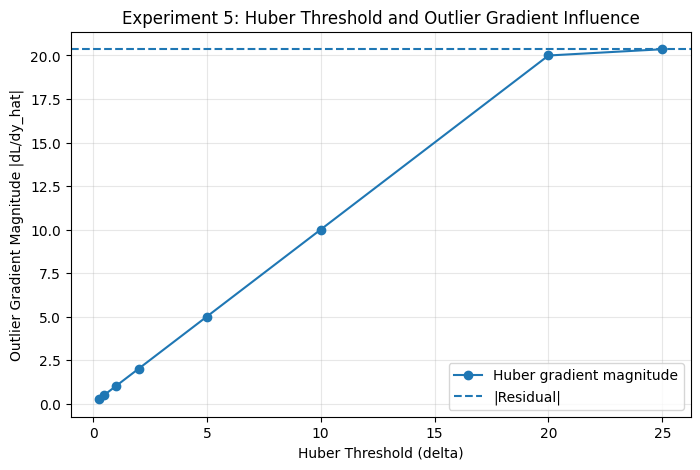

In [101]:
# Plot gradient influence across delta

gradient_magnitudes_exp5 = []

for delta in HUBER_DELTAS_EXP5:
    grad = huber_prediction_gradient(
        residual_out_exp5,
        delta
    )
    gradient_magnitudes_exp5.append(abs(grad))

plt.figure(figsize=(8, 5))

plt.plot(
    HUBER_DELTAS_EXP5,
    gradient_magnitudes_exp5,
    marker="o",
    label="Huber gradient magnitude"
)

# Mark the fixed residual transition boundary
plt.axhline(
    y=abs(residual_out_exp5),
    linestyle="--",
    label="|Residual|"
)

plt.xlabel("Huber Threshold (delta)")
plt.ylabel("Outlier Gradient Magnitude |dL/dy_hat|")
plt.title("Experiment 5: Huber Threshold and Outlier Gradient Influence")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

For this fixed residual, the threshold is the gradient cap until it exceeds the residual magnitude. The resulting curve directly shows the transition from strong clipping to quadratic, MSE-like behaviour.

$$ \left|\frac{\partial L}{\partial \hat y}\right|=\delta $$

$$ |r|=20.3604 $$

$$ \delta<20.3604 $$

$$ \delta=1\Rightarrow |\partial L/\partial\hat y|=1 $$

$$ \delta=10\Rightarrow |\partial L/\partial\hat y|=10 $$

$$ \delta=25>|r| $$

$$ \left|\frac{\partial L}{\partial\hat y}\right| = |r| \approx20.36 $$

$$ \boxed{ \left|\frac{\partial L}{\partial\hat y}\right| = \min(|r|,\delta) } $$


## **Part 3: Training and Parameter Recovery**

Huber models are trained on the same contaminated data with identical optimisation settings. Their parameter errors show how the threshold-level gradient differences affect final recovery.

**Notation and retained values:** $\delta$.

$$
w_{\text{true}}=3,\qquad b_{\text{true}}=2
$$

$$
|\hat w-w_{\text{true}}|
$$

$$
|\hat b-b_{\text{true}}|
$$


In [102]:
# Experiment 5 Part 3:
# Change only delta on the fixed contaminated data

trained_models_exp5 = []

for delta in HUBER_DELTAS_EXP5:

    # Reuse the verified Huber loss, gradients, and trainer
    w_final, b_final, history = train_model(
        x_exp5,
        y_exp5,
        huber_loss,
        huber_gradients,
        w_init=INITIAL_W,
        b_init=INITIAL_B,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS,
        delta=delta
    )

    # Store final parameters and training history
    trained_models_exp5.append([
        delta,
        w_final,
        b_final,
        history
    ])

print("Finished training", len(trained_models_exp5), "Huber models.")

Finished training 8 Huber models.


### **Parameter Recovery Results**

Final slopes and intercepts are compared with the known generating parameters using absolute recovery errors.

**Notation and retained values:** $\hat{w}$; $\hat{b}$.

$$
w_{\text{true}}=3,\qquad b_{\text{true}}=2
$$

$$
|\hat{w}-w_{\text{true}}|
$$

$$
|\hat{b}-b_{\text{true}}|
$$


In [103]:
# Experiment 5 Part 3:
# Compare parameter recovery across deltas

parameter_results_exp5 = []

for delta, w_final, b_final, history in trained_models_exp5:

    # Absolute errors from the ground truth
    w_error = abs(w_final - W_TRUE)
    b_error = abs(b_final - B_TRUE)

    parameter_results_exp5.append([
        delta,
        w_final,
        b_final,
        w_error,
        b_error
    ])

# Use the existing formatted-text table style
print(
    f"{'delta':>8} "
    f"{'w_final':>12} "
    f"{'b_final':>12} "
    f"{'|w-true|':>12} "
    f"{'|b-true|':>12}"
)

print("-" * 62)

for row in parameter_results_exp5:
    delta, w_final, b_final, w_error, b_error = row

    print(
        f"{delta:8.2f} "
        f"{w_final:12.6f} "
        f"{b_final:12.6f} "
        f"{w_error:12.6f} "
        f"{b_error:12.6f}"
    )

   delta      w_final      b_final     |w-true|     |b-true|
--------------------------------------------------------------
    0.25     2.873502     1.211266     0.126498     0.788734
    0.50     2.939141     1.896254     0.060859     0.103746
    1.00     2.955482     1.970668     0.044518     0.029332
    2.00     2.959959     1.999610     0.040041     0.000390
    5.00     2.966759     2.036050     0.033241     0.036050
   10.00     2.980491     2.090985     0.019509     0.090985
   20.00     3.007955     2.200836     0.007955     0.200836
   25.00     3.008045     2.201208     0.008045     0.201208


Very small threshold 0.25 clips normal as well as outlier residuals and has not fully converged under the fixed budget. Intermediate thresholds balance useful learning signals and outlier control. Thresholds 20 and 25 give nearly identical, more MSE-like solutions with a visibly shifted intercept.

$$ \hat w=2.8735,\qquad \hat b=1.2113 $$

$$ |\hat b-2|=0.7887 $$

$$ \eta=0.01,\qquad \text{epochs}=1000 $$

$$ \hat w=2.9600,\qquad \hat b=1.9996 $$

$$ |\hat b-2|=0.00039 $$

$$ |\hat w-3|=0.0332,\qquad |\hat b-2|=0.0361 $$

$$ \text{too small} \leftarrow \boxed{\text{balanced }\delta} \rightarrow \text{too large} $$

$$ \delta=20: \quad (w,b)=(3.007955,2.200836) $$

$$ \delta=25: \quad (w,b)=(3.008045,2.201208) $$

$$ |b-2|: 0.0361\ (\delta=5) \rightarrow 0.0910\ (\delta=10) \rightarrow 0.2008\ (\delta=20) $$

$$ \delta\uparrow \rightarrow \text{weaker gradient clipping} \rightarrow \text{stronger outlier influence} \rightarrow \text{parameter shift} $$

| \(\delta\) | \(w\) error | \(b\) error | Main observation                       |
| ---------: | ----------: | ----------: | -------------------------- |
|       0.25 |      0.1265 |      0.7887 | Large error                       |
|       0.50 |      0.0609 |      0.1037 | Substantial improvement                       |
|       1.00 |      0.0445 |      0.0293 | Close to ground truth                     |
|       2.00 |      0.0400 | **0.00039** | Strong recovery                         |
|       5.00 |  **0.0332** |      0.0361 | Strong overall recovery                       |
|      10.00 |      0.0195 |      0.0910 | \(w\) is closer, but \(b\) starts to shift      |
|      20.00 |      0.0080 |      0.2008 | Slope is close, but intercept is clearly affected |
|      25.00 |      0.0080 |      0.2012 | Nearly identical to 20                  |


### **Parameter Trajectories and Convergence**

Stored histories for representative thresholds distinguish incomplete optimisation at a very small threshold from convergence to an outlier-shifted solution at a large threshold. No additional training is performed.

**Notation and retained values:** $\delta$; $\delta=0.25$; $w$; $b$.

$$
\delta = 0.25,\ 1,\ 5,\ 25
$$


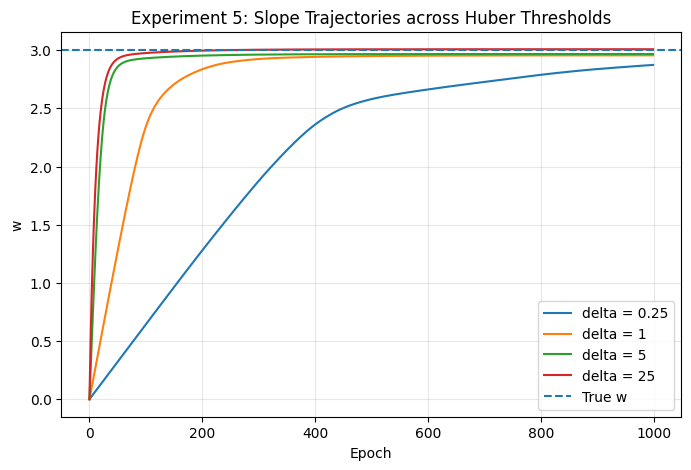

In [104]:
# Experiment 5 Part 3:
# Compare representative stored parameter trajectories

selected_deltas_exp5 = [0.25, 1.0, 5.0, 25.0]

plt.figure(figsize=(8, 5))

for delta, w_final, b_final, history in trained_models_exp5:
    if delta in selected_deltas_exp5:
        plt.plot(
            history["w"],
            label=f"delta = {delta:g}"
        )

# Mark the true slope
plt.axhline(
    y=W_TRUE,
    linestyle="--",
    label="True w"
)

plt.xlabel("Epoch")
plt.ylabel("w")
plt.title("Experiment 5: Slope Trajectories across Huber Thresholds")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Larger representative thresholds approach the true slope quickly; threshold 1 is slower; threshold 0.25 is still moving upward at epoch 1000. Strong clipping therefore slows updates without implying weak robustness.

$$ w_{\text{true}}=3 $$

$$ \delta=0.25 $$

$$ w=2.8735 $$

$$ \text{very small }\delta \rightarrow \text{strong gradient clipping} \rightarrow \text{smaller parameter updates} \rightarrow \text{slower convergence} $$


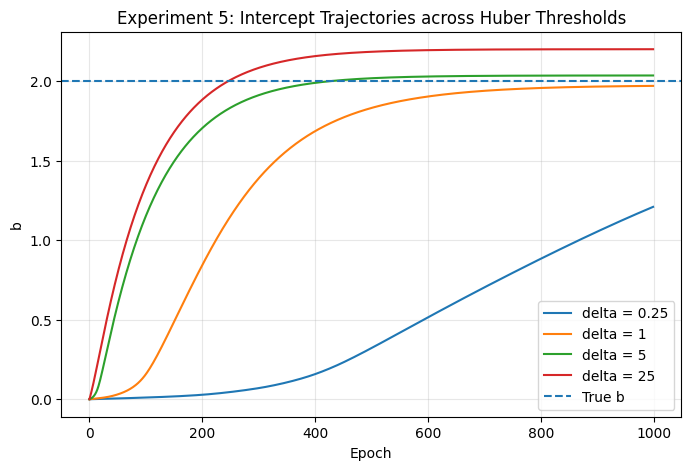

In [105]:
# Compare intercept trajectories for the same deltas

plt.figure(figsize=(8, 5))

for delta, w_final, b_final, history in trained_models_exp5:
    if delta in selected_deltas_exp5:
        plt.plot(
            history["b"],
            label=f"delta = {delta:g}"
        )

# Mark the true intercept
plt.axhline(
    y=B_TRUE,
    linestyle="--",
    label="True b"
)

plt.xlabel("Epoch")
plt.ylabel("b")
plt.title("Experiment 5: Intercept Trajectories across Huber Thresholds")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The intercept histories separate the two error mechanisms. Threshold 0.25 remains below the target because convergence is slow, whereas threshold 25 quickly passes the target and plateaus near an outlier-shifted value.

$$ b\approx1.21 $$

$$ |b-2|=0.7887 $$

$$ b_{\text{true}}=2 $$

$$ b=2 $$

$$ b\approx2.20 $$

$$ \delta=0.25: \quad \boxed{\text{slow convergence under fixed training budget}} $$

$$ \delta=25: \quad \boxed{\text{converged, but to an outlier-shifted solution}} $$


## **Part 4: Clean-Test Performance**

All trained models are evaluated on the same clean test set. Results are interpreted with the gradient and trajectory evidence because very small thresholds may be under-converged and large thresholds may admit more outlier influence.

**Notation and retained values:** $\delta$.


In [106]:
# Experiment 5 Part 4:
# Evaluate all Huber models on the same clean test set

test_results_exp5 = []

for delta, w_final, b_final, history in trained_models_exp5:

    # Predict with the final learned parameters
    y_test_pred = predict(
        x_test,
        w_final,
        b_final
    )

    # Reuse the verified evaluation metrics
    test_rmse = rmse_metric(
        y_test,
        y_test_pred
    )

    test_mae = mae_metric(
        y_test,
        y_test_pred
    )

    test_results_exp5.append([
        delta,
        test_rmse,
        test_mae
    ])

print(
    f"{'delta':>8} "
    f"{'clean RMSE':>15} "
    f"{'clean MAE':>15}"
)

print("-" * 42)

for delta, test_rmse, test_mae in test_results_exp5:
    print(
        f"{delta:8.2f} "
        f"{test_rmse:15.6f} "
        f"{test_mae:15.6f}"
    )

   delta      clean RMSE       clean MAE
------------------------------------------
    0.25        1.299936        1.043378
    0.50        0.936465        0.743077
    1.00        0.916855        0.727067
    2.00        0.912760        0.723494
    5.00        0.908622        0.718801
   10.00        0.904750        0.714823
   20.00        0.913538        0.721831
   25.00        0.913605        0.721866


Threshold 0.25 has the highest test error because strong clipping slows convergence under the fixed budget. Performance improves through intermediate thresholds, then worsens slightly at 20 and 25 as weaker clipping shifts the intercept. The lowest observed error is not treated as a universal optimum.

$$ \delta=0.25 $$

$$ RMSE=1.2999,\qquad MAE=1.0434 $$

$$ \text{strong clipping} \rightarrow \text{small updates} \rightarrow \text{slow convergence} $$

$$ \delta=0.5\rightarrow10 $$

$$ RMSE: 0.9365\rightarrow0.9048 $$

$$ MAE: 0.7431\rightarrow0.7148 $$

$$ \boxed{RMSE=0.904750} $$

$$ \boxed{MAE=0.714823} $$

$$ \delta=10: RMSE=0.904750 $$

$$ \delta=20: RMSE=0.913538 $$

$$ \delta=25: RMSE=0.913605 $$

$$ b\approx2.20 $$

$$ b=2 $$

$$ \boxed{ \delta\uparrow \rightarrow \text{weaker clipping} \rightarrow \text{stronger outlier gradient} \rightarrow \text{parameter shift} \rightarrow \text{slightly worse clean-test performance} } $$

$$ RMSE,\ MAE $$


#### **Experiment 5: Results and Interpretation**

The threshold controls the cap on large-residual gradients and therefore affects optimisation speed, parameter recovery, and clean-test performance. Very small values can slow learning by clipping useful gradients; very large values converge quickly but become more MSE-like and admit more outlier influence. Intermediate values balance these effects in this fixed setting.

**Notation and retained values:** $\delta$; $\delta < |r|$; $|r|$; $\delta=0.25$; $2.20$; $b_{\text{true}}=2$.

$$
\delta
\rightarrow
\text{gradient clipping}
\rightarrow
\text{parameter update}
\rightarrow
\text{parameter recovery}
\rightarrow
\text{clean-test performance}
$$


## **Implementation Log — 15/09/2026**

**Development stage:** Experiment 5 — Huber Threshold

The contaminated dataset and optimiser were fixed while only the Huber threshold changed. Adding threshold 25 ensured that the tested range crossed the observed residual boundary. An unnecessary `pandas` table and an incorrect trainer call were replaced with the notebook's existing list output and verified function interface.

**Use of AI tools:** ChatGPT helped structure the threshold comparison and interpret the small-threshold result. Suggestions were verified against the fixed residual, Huber regions, gradients, parameter histories, and clean-test metrics.

**Learning:** The threshold caps the gradient of a large residual, but very strong clipping can also slow useful updates. Small and large thresholds therefore fail for different reasons under the fixed budget: incomplete convergence versus convergence to an outlier-shifted solution.

**Notation and retained values:** $\delta$; $\delta=20$; $\delta=25$; $\delta=0.25$; $w$; $b$.

$$
\left|\frac{\partial L}{\partial \hat y}\right|
=
\min(|r|,\delta).
$$

$$
\delta
\rightarrow
\text{gradient clipping}
\rightarrow
\text{parameter update}
\rightarrow
\text{parameter recovery}
\rightarrow
\text{clean-test performance}.
$$
